Initial imports

In [4]:
import pickle
import sys


import sys
from pathlib import Path

project_root = Path(".").resolve()

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))


import isop_co2Inhi_als.MultiVar as MultiVar
import isop_co2Inhi_als.MultiModel as MultiModel

from isop_co2Inhi_als.MultiVar import EMIISOP
from  isop_co2Inhi_als.plt import *

from isop_co2Inhi_als.visit_preprocess import VisitEMIISOP
import isop_co2Inhi_als.visit_preprocess as vp

import hcho_als.utils as utils
from hcho_als.utils import *
from hcho_als.plt import *


from isop_factor_als.visit_sensitivity_als import VisitSenAls
import isop_factor_als.visit_sensitivity_als as vsa
from isop_factor_als.plt import *

sys.modules["MultiModel"] = MultiModel

sys.modules["MultiVar"] = MultiVar
MultiVar.EMIISOP = EMIISOP

sys.modules["utils"] = utils
utils.HCHO = HCHO

sys.modules["visit_sensitivity_als"] = vsa
vsa.VisitSenAls = VisitSenAls

sys.modules["visit_preprocess"] = vp
vp.VisitEMIISOP = VisitEMIISOP


In [5]:

emiisop_co2Inhi_2k = pickle.load(open("./plt_data/emiisop_co2Inhi_from2000s.pkl", "rb"))
emiisop_co2Inhi_1k9 = pickle.load(open("./plt_data/emiisop_co2Inhi_from1900s.pkl", "rb"))
emiisop_megan_compare = pickle.load(open("./plt_data/emiisop_megan_compare.pkl", "rb"))
interp_omi_v2 = pickle.load(open("./plt_data/interp_omi_v2.pkl", "rb"))
interp_tropo_v2 = pickle.load(open("./plt_data/interp_tropo_v2.pkl", "rb"))
visits = pickle.load(open("./plt_data/visits.pkl", "rb"))

Figure 1. Model simulations of isoprene emissions in response to atmospheric CO2 concentration (Cₐ) using two CO2 inhibition functions (dashed lines) compared with observations (solid lines) for five isoprene-emitting tree species. Data from Niinemets et al. (2021) and Possell and Hewitt (2011). Ismax, C*, and h are empirically determined coefficients. Also, Ca denotes the ambient CO2 concentration and Cast stands for the standard ambient CO2 concentration.

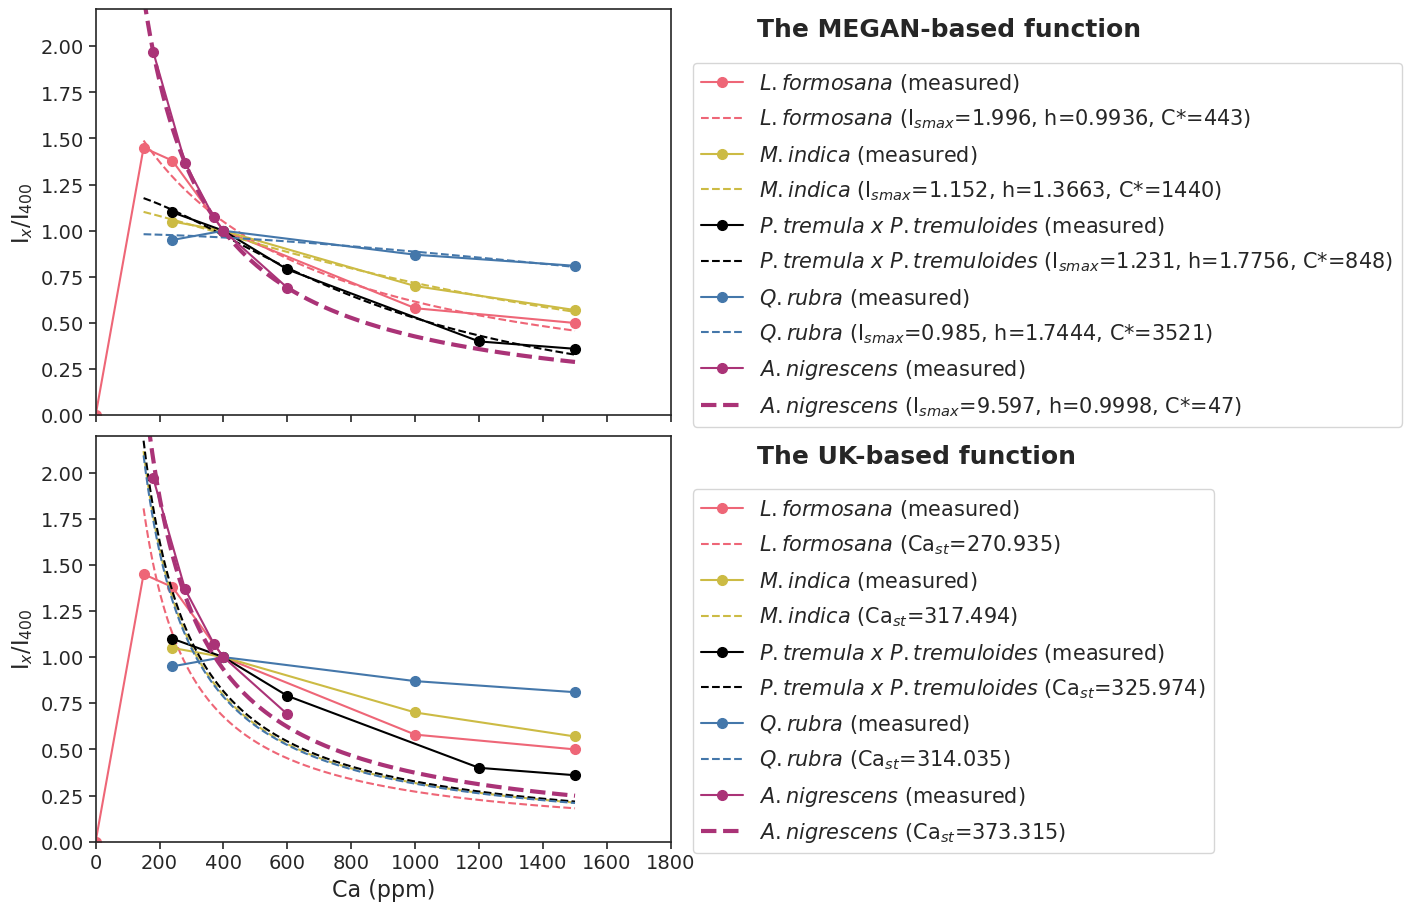

In [6]:
# %%
# Combined 2 subplots (share x) + right-side panel titles + italic species names in legend
#
# REVISION NOTES
#   Reviewer 1, comment 1: "Fonts are generally too small"  -> tagged [R1.1]
#   Every line changed or added for this comment is marked with "# CHANGED [R1.1]"
#   or "# ADDED [R1.1]". Unmarked lines are identical to the original script.

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ADDED [R1.1]: central font-size settings so every text element is enlarged consistently
FS_LABEL = 16    # axis labels
FS_TICK = 14     # tick labels
FS_LEGEND = 15   # legend entries
FS_TITLE = 18    # panel titles
plt.rcParams.update({
    "font.size": FS_TICK,            # ADDED [R1.1]: default for any text not set explicitly
    "axes.labelsize": FS_LABEL,      # ADDED [R1.1]
    "xtick.labelsize": FS_TICK,      # ADDED [R1.1]
    "ytick.labelsize": FS_TICK,      # ADDED [R1.1]
    "legend.fontsize": FS_LEGEND,    # ADDED [R1.1]
    "axes.linewidth": 1.2,           # ADDED [R1.1]: slightly heavier frame to match larger text
    "xtick.major.width": 1.2,        # ADDED [R1.1]
    "ytick.major.width": 1.2,        # ADDED [R1.1]
    "xtick.major.size": 5,           # ADDED [R1.1]
    "ytick.major.size": 5,           # ADDED [R1.1]
})


# -----------------------
# Models
# -----------------------
def wilkinson2009(Ca, Ismax, h, cstar):
    Ca = np.asarray(Ca, dtype=float)
    return Ismax * (1.0 - 1.0 / ((cstar / Ca) ** h + 1.0))


def ukesm(Ca, cast):
    Ca = np.asarray(Ca, dtype=float)
    return cast / Ca


# -----------------------
# Data
# -----------------------
species = [
    dict(
        key="L.formosana",
        color="#EE6677",
        marker="o",
        x_plot=[0, 150, 240, 400, 1000, 1500],
        y_plot=[0, 1.45, 1.38, 1.0, 0.58, 0.5],
        x_fit=[150, 240, 400, 1000, 1500],
        y_fit=[1.45, 1.38, 1.0, 0.58, 0.5],
    ),
    dict(
        key="M.indica",
        color="#CCBB44",
        marker="o",
        x_plot=[0, 240, 400, 1000, 1500],
        y_plot=[np.nan, 1.05, 1.0, 0.7, 0.57],
        x_fit=[240, 400, 1000, 1500],
        y_fit=[1.05, 1.0, 0.7, 0.57],
    ),
    dict(
        key="P.tremula x P.tremuloides",
        color="k",
        marker="o",
        x_plot=[0, 240, 400, 600, 1200, 1500],
        y_plot=[np.nan, 1.1, 1.0, 0.79, 0.4, 0.36],
        x_fit=[240, 400, 600, 1200, 1500],
        y_fit=[1.1, 1.0, 0.79, 0.4, 0.36],
    ),
    dict(
        key="Q.rubra",
        color="#4477AA",
        marker="o",
        x_plot=[0, 240, 400, 1000, 1500],
        y_plot=[np.nan, 0.95, 1.0, 0.87, 0.81],
        x_fit=[240, 400, 1000, 1500],
        y_fit=[0.95, 1.0, 0.87, 0.81],
    ),
    dict(
        key="A.nigrescens",
        color="#AA3377",
        marker="o",
        x_plot=[0, 180, 280, 370, 400, 600],
        y_plot=[np.nan, 1.970854, 1.367418, 1.071849, 1.0, 0.690692],
        x_fit=[180, 280, 370, 400, 600],
        y_fit=[1.970854, 1.367418, 1.071849, 1.0, 0.690692],
        lw_fit=3,
    ),
]


# -----------------------
# Helpers
# -----------------------
def _finite_xy(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    return x[m], y[m]


def italic_name(name: str) -> str:
    # Mathtext italics; keep spaces visible in mathtext
    return r"$\it{" + name.replace(" ", r"\ ") + "}$"


def plot_panel(ax, model_name, model_func, p0, bounds, legend_fmt):
    # Smooth curve range (avoid Ca=0)
    x_grid = np.linspace(150, 1500, 400)

    for sp in species:
        # measured
        x_m, y_m = _finite_xy(sp["x_plot"], sp["y_plot"])
        ax.plot(
            x_m,
            y_m,
            color=sp["color"],
            marker=sp.get("marker", "o"),
            markersize=7,          # ADDED [R1.1]: larger markers to balance the larger text
            linestyle="-",
            label=f"{italic_name(sp['key'])} (measured)",
        )

        # fit
        x_f, y_f = _finite_xy(sp["x_fit"], sp["y_fit"])
        popt, _ = curve_fit(
            model_func,
            x_f,
            y_f,
            p0=p0,
            bounds=bounds,
            maxfev=20000,
        )

        # fitted curve (smooth)
        y_grid = model_func(x_grid, *popt)

        ax.plot(
            x_grid,
            y_grid,
            color=sp["color"],
            linestyle="--",
            linewidth=sp.get("lw_fit", 1.5),
            label=legend_fmt(sp["key"], popt),
        )

    ax.set_ylim(0, 2.2)
    ax.set_xlim(0, 1800)
    ax.set_ylabel("I$_x$/I$_{400}$", fontsize=FS_LABEL)   # CHANGED [R1.1]: explicit font size

    # title on the right of the panel
    ax.text(
        1.15,
        0.98,                       # CHANGED [R1.1]: 0.92 -> 0.98 so the larger title clears the legend
        model_name,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=FS_TITLE,          # CHANGED [R1.1]: 14 -> 16
        fontweight="bold",
    )

    # legend on the right
    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.42),   # CHANGED [R1.1]: 0.45 -> 0.42, leaves room for the panel title
        fontsize=FS_LEGEND,            # ADDED [R1.1]
        labelspacing=0.6,              # ADDED [R1.1]: more line spacing for the larger legend text
    )


# -----------------------
# Build combined figure (2 panels share x)
# -----------------------
fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 9),           # CHANGED [R1.1]: (9, 7) -> (14, 9) so larger text fits without crowding
    sharex=True,
    constrained_layout=True,
)

# Top panel: MEGAN-based (Wilkinson 2009)
plot_panel(
    axes[0],
    model_name="The MEGAN-based function",
    model_func=wilkinson2009,
    p0=(1.0, 1.0, 400.0),
    bounds=([0.0, 0.0, 1.0], [np.inf, np.inf, np.inf]),
    legend_fmt=lambda n, p: (
        f"{italic_name(n)} " f"(I$_{{smax}}$={p[0]:.3f}, h={p[1]:.4f}, C*={p[2]:.0f})"
    ),
)

# Bottom panel: UK-based
plot_panel(
    axes[1],
    model_name="The UK-based function",
    model_func=ukesm,
    p0=(400.0,),
    bounds=([1.0], [np.inf]),
    legend_fmt=lambda n, p: f"{italic_name(n)} (Ca$_{{st}}$={p[0]:.3f})",
)

# shared x label only on bottom
axes[1].set_xlabel("Ca (ppm)", fontsize=FS_LABEL)   # CHANGED [R1.1]: explicit font size
axes[0].set_xlabel("")

# ADDED [R1.1]: save at publication resolution; bbox_inches="tight" keeps the right-hand legends in the file
fig.savefig("./plots/Figure1.png", dpi=300, bbox_inches="tight")

plt.show()
# %%

Figure 2. Spatial distribution of mean annual isoprene emissions (in gC m–2 yr–1) in the present day (2000–2023) from the VISIT simulation without CO2 inhibition (VISIT-woCO2inhi) and emission differences among sensitivity cases (e.g., VISIT-wCO2inhi-MEGANpft) and VISIT-woCO2inhi.

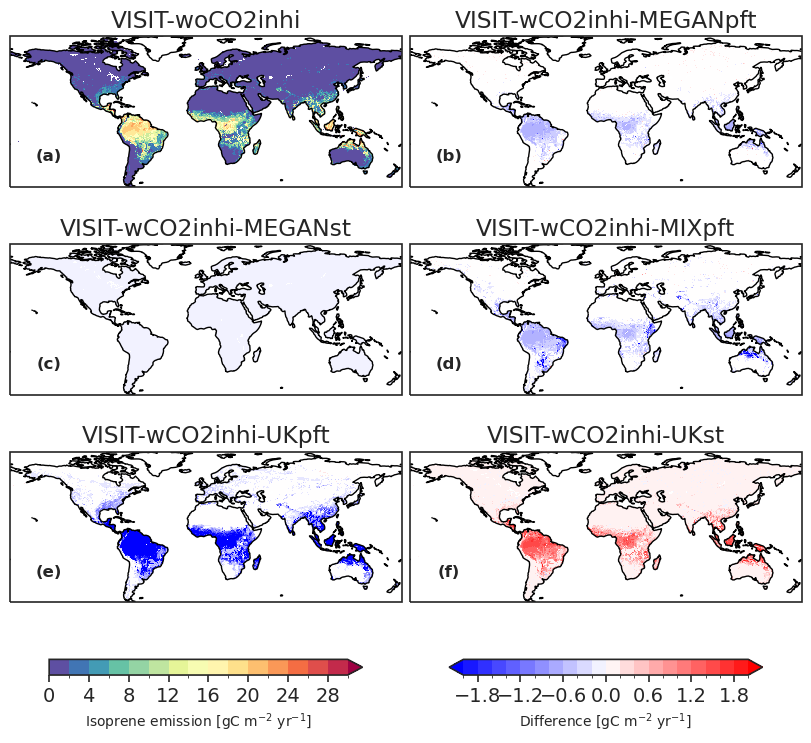

In [7]:
# Plot Fig. 2 - Plot base map (VISIT-woCO2inhi) and Difference map between each sen exp and VISIT-woCO2inhi (2000-2023)
def plt_glob_present_diff_map(emiisop, cmap="bwr", unit="absolute"):
    list_models = list(emiisop.multi_models.keys())
    # Make sure VISIT-woCO2inhi comes first
    list_models = ["VISIT-woCO2inhi"] + [
        m for m in list_models if m != "VISIT-woCO2inhi"
    ]

    # Difference colorbar settings
    vmin_diff, vmax_diff = -2, 2
    if unit == "relative":
        vmin_diff, vmax_diff = -30, 30
    levels_diff = 21
    bounds_diff = np.linspace(vmin_diff, vmax_diff, levels_diff)
    cmap_diff = mpl.colormaps.get_cmap(cmap)
    norm_diff = mpl.colors.BoundaryNorm(bounds_diff, mpl.cm.plasma.N, extend="both")

    # Base map colorbar settings
    vmin_base, vmax_base = 0, 30
    levels_base = 15
    bounds_base = np.linspace(vmin_base, vmax_base, levels_base + 1)
    norm_base = mpl.colors.BoundaryNorm(bounds_base, mpl.cm.plasma.N, extend="max")
    cmap_base = mpl.colormaps.get_cmap("Spectral_r")

    unit_sz = 10

    # Grid layout
    n_models = len(list_models)
    rows, cols = 3, 2
    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(4 * cols, 2.5 * rows),
        layout="constrained",
        subplot_kw=dict(projection=ccrs.PlateCarree()),
    )

    # Flatten axes for easier indexing
    axes = axes.flatten()

    for i, m in enumerate(list_models):
        ax = axes[i]

        if m == "VISIT-woCO2inhi":
            # Plot base map
            data = (
                emiisop.multi_models[m]
                .annual_per_area_unit.sel(year=slice(2000, 2023))
                .mean("year")
                * emiisop.multi_models[m].ds_mask["mask"]
            ).sel(lat=slice(82.75, -55.25))

            im_base = data.plot.pcolormesh(
                ax=ax,
                cmap=cmap_base,
                levels=levels_base,
                vmin=vmin_base,
                vmax=vmax_base,
                add_colorbar=False,
            )
            ax.set_title("VISIT-woCO2inhi")

        else:
            # Plot difference with base
            data1 = (
                emiisop.multi_models[m]
                .annual_per_area_unit.sel(year=slice(2000, 2023))
                .mean("year")
            )
            data0 = (
                emiisop.multi_models["VISIT-woCO2inhi"]
                .annual_per_area_unit.sel(year=slice(2000, 2023))
                .mean("year")
            )
            # diff = ((data1 - data0) * 100 / data0) * emiisop.multi_models[m].ds_mask[
            #     "mask"
            # ]
            diff = (data1 - data0) * emiisop.multi_models[m].ds_mask["mask"]
            if unit == "relative":
                diff = (data1 - data0) * 100 / data0 * emiisop.multi_models[m].ds_mask[
                    "mask"
                ]
            diff = diff.sel(lat=slice(82.75, -55.25))

            diff.plot.pcolormesh(
                ax=ax,
                cmap=cmap_diff,
                levels=levels_diff,
                add_colorbar=False,
                vmin=vmin_diff,
                vmax=vmax_diff,
                
            )
            ax.set_title(f"{m}")

        ax.coastlines()
        ax.text(
            0.10, 0.20, f"({chr(ord('a') + i)})",
            transform=ax.transAxes, ha="center", va="center",
            fontsize=12, fontweight="bold",
        )

    # Turn off any unused axes
    for j in range(n_models, len(axes)):
        axes[j].set_axis_off()

    # Add colorbar for base map (first subplot)
    sm_base = mpl.cm.ScalarMappable(cmap=cmap_base, norm=norm_base)
    sm_base.set_array([])
    cbar_base = fig.colorbar(
        sm_base, ax=axes[::2], orientation="horizontal", shrink=0.8, pad=0.08
    )
    cbar_base.set_label("Isoprene emission [gC m$^{-2}$ yr$^{-1}$]", size=unit_sz)

    # Add shared colorbar for difference maps (excluding the first one)
    sm_diff = mpl.cm.ScalarMappable(cmap=cmap_diff, norm=norm_diff)
    sm_diff.set_array([])
    cbar_diff = fig.colorbar(
        sm_diff, ax=axes[1::2], orientation="horizontal", shrink=0.8, pad=0.08
    )
    cbar_diff.set_label("Difference [gC m$^{-2}$ yr$^{-1}$]", size=unit_sz)
    if unit == "relative":
        cbar_diff.set_label("Difference [%]", size=unit_sz)
    fig.savefig("./plots/Figure21.png", dpi=300, bbox_inches="tight")
plt_glob_present_diff_map(emiisop_co2Inhi_2k)

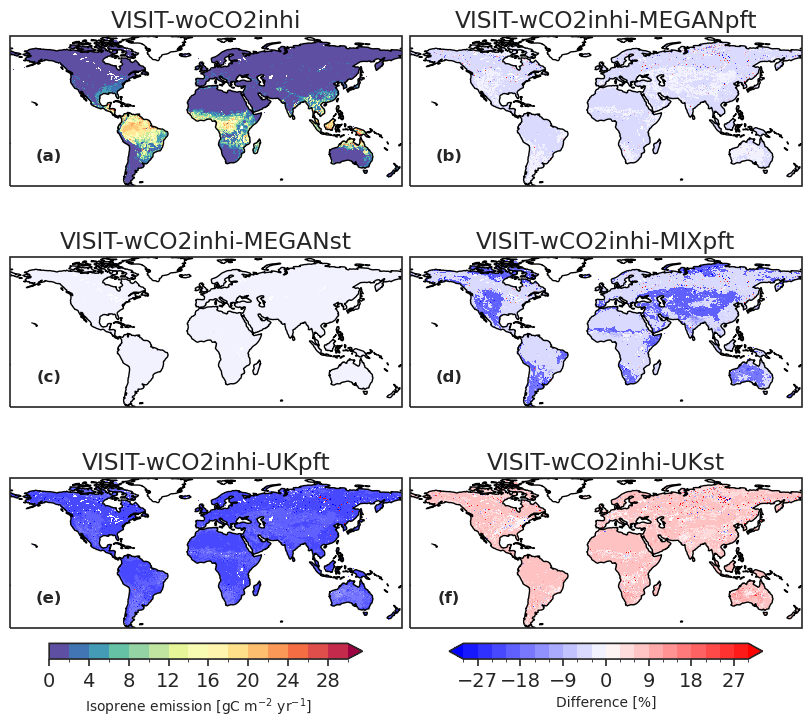

In [8]:
def plt_glob_present_diff_map(emiisop, cmap="bwr", unit="absolute"):
    list_models = list(emiisop.multi_models.keys())
    # Make sure VISIT-woCO2inhi comes first
    list_models = ["VISIT-woCO2inhi"] + [
        m for m in list_models if m != "VISIT-woCO2inhi"
    ]

    # Difference colorbar settings
    vmin_diff, vmax_diff = -2, 2
    if unit == "relative":
        vmin_diff, vmax_diff = -30, 30
    levels_diff = 21
    bounds_diff = np.linspace(vmin_diff, vmax_diff, levels_diff)
    cmap_diff = mpl.colormaps.get_cmap(cmap)
    norm_diff = mpl.colors.BoundaryNorm(bounds_diff, mpl.cm.plasma.N, extend="both")

    # Base map colorbar settings
    vmin_base, vmax_base = 0, 30
    levels_base = 15
    bounds_base = np.linspace(vmin_base, vmax_base, levels_base + 1)
    norm_base = mpl.colors.BoundaryNorm(bounds_base, mpl.cm.plasma.N, extend="max")
    cmap_base = mpl.colormaps.get_cmap("Spectral_r")

    unit_sz = 10

    # Grid layout
    n_models = len(list_models)
    rows, cols = 3, 2
    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(4 * cols, 2.5 * rows),
        layout="constrained",
        subplot_kw=dict(projection=ccrs.PlateCarree()),
    )

    # Flatten axes for easier indexing
    axes = axes.flatten()

    for i, m in enumerate(list_models):
        ax = axes[i]

        if m == "VISIT-woCO2inhi":
            # Plot base map
            data = (
                emiisop.multi_models[m]
                .annual_per_area_unit.sel(year=slice(2000, 2023))
                .mean("year")
                * emiisop.multi_models[m].ds_mask["mask"]
            ).sel(lat=slice(82.75, -55.25))

            im_base = data.plot.pcolormesh(
                ax=ax,
                cmap=cmap_base,
                levels=levels_base,
                vmin=vmin_base,
                vmax=vmax_base,
                add_colorbar=False,
            )
            ax.set_title("VISIT-woCO2inhi")

        else:
            # Plot difference with base
            data1 = (
                emiisop.multi_models[m]
                .annual_per_area_unit.sel(year=slice(2000, 2023))
                .mean("year")
            )
            data0 = (
                emiisop.multi_models["VISIT-woCO2inhi"]
                .annual_per_area_unit.sel(year=slice(2000, 2023))
                .mean("year")
            )
            # diff = ((data1 - data0) * 100 / data0) * emiisop.multi_models[m].ds_mask[
            #     "mask"
            # ]
            diff = (data1 - data0) * emiisop.multi_models[m].ds_mask["mask"]
            if unit == "relative":
                diff = (data1 - data0) * 100 / data0 * emiisop.multi_models[m].ds_mask[
                    "mask"
                ]
            diff = diff.sel(lat=slice(82.75, -55.25))

            diff.plot.pcolormesh(
                ax=ax,
                cmap=cmap_diff,
                levels=levels_diff,
                add_colorbar=False,
                vmin=vmin_diff,
                vmax=vmax_diff,
                
            )
            ax.set_title(f"{m}")

        ax.coastlines()
        ax.text(
            0.10, 0.20, f"({chr(ord('a') + i)})",
            transform=ax.transAxes, ha="center", va="center",
            fontsize=12, fontweight="bold",
        )

    # Turn off any unused axes
    for j in range(n_models, len(axes)):
        axes[j].set_axis_off()

    # Add colorbar for base map (first subplot)
    sm_base = mpl.cm.ScalarMappable(cmap=cmap_base, norm=norm_base)
    sm_base.set_array([])
    cbar_base = fig.colorbar(
        sm_base, ax=axes[::2], orientation="horizontal", shrink=0.8, pad=0.02
    )
    cbar_base.set_label("Isoprene emission [gC m$^{-2}$ yr$^{-1}$]", size=unit_sz)

    # Add shared colorbar for difference maps (excluding the first one)
    sm_diff = mpl.cm.ScalarMappable(cmap=cmap_diff, norm=norm_diff)
    sm_diff.set_array([])
    cbar_diff = fig.colorbar(
        sm_diff, ax=axes[1::2], orientation="horizontal", shrink=0.8, pad=0.02
    )
    cbar_diff.set_label("Difference [gC m$^{-2}$ yr$^{-1}$]", size=unit_sz)
    if unit == "relative":
        cbar_diff.set_label("Difference [%]", size=unit_sz)
    fig.savefig("./plots/Figure2relative.png", dpi=300, bbox_inches="tight")


plt_glob_present_diff_map(emiisop_co2Inhi_2k, unit="relative")

Figure 3. Interannual variation of isoprene emissions globally (a) and in selected regions (b) as defined in (c) for 2000–2023 from VISIT sensitivity simulations: AMZ, Amazonia; ENA, Eastern North America; N_Africa, Northern Africa; C_Africa, Central Africa; S_Africa, Southern Africa; NAU, Northern Australia.

VISIT-wCO2inhi-MEGANpft Mann_Kendall_Test(trend='increasing', h=True, p=2.8287791442593857e-07, z=5.13451142244029, Tau=0.7536231884057971, s=208.0, var_s=1625.3333333333333, slope=1.3222972327519351, intercept=488.08717535589363)
VISIT-wCO2inhi-MEGANst Mann_Kendall_Test(trend='increasing', h=True, p=2.2197854009586848e-05, z=4.241552914189805, Tau=0.6231884057971014, s=172.0, var_s=1625.3333333333333, slope=1.1513669499521564, intercept=506.829378523677)
VISIT-wCO2inhi-MIXpft Mann_Kendall_Test(trend='increasing', h=True, p=7.970997484285647e-07, z=4.936076198384627, Tau=0.7246376811594203, s=200.0, var_s=1625.3333333333333, slope=1.0727834237623055, intercept=480.0049436285869)
VISIT-wCO2inhi-UKpft Mann_Kendall_Test(trend='decreasing', h=True, p=1.7958432074749453e-08, z=-5.6305994825794485, Tau=-0.8260869565217391, s=-228.0, var_s=1625.3333333333333, slope=-1.4070717402539583, intercept=429.42197143099287)
VISIT-wCO2inhi-UKst Mann_Kendall_Test(trend='decreasing', h=True, p=1.79584320

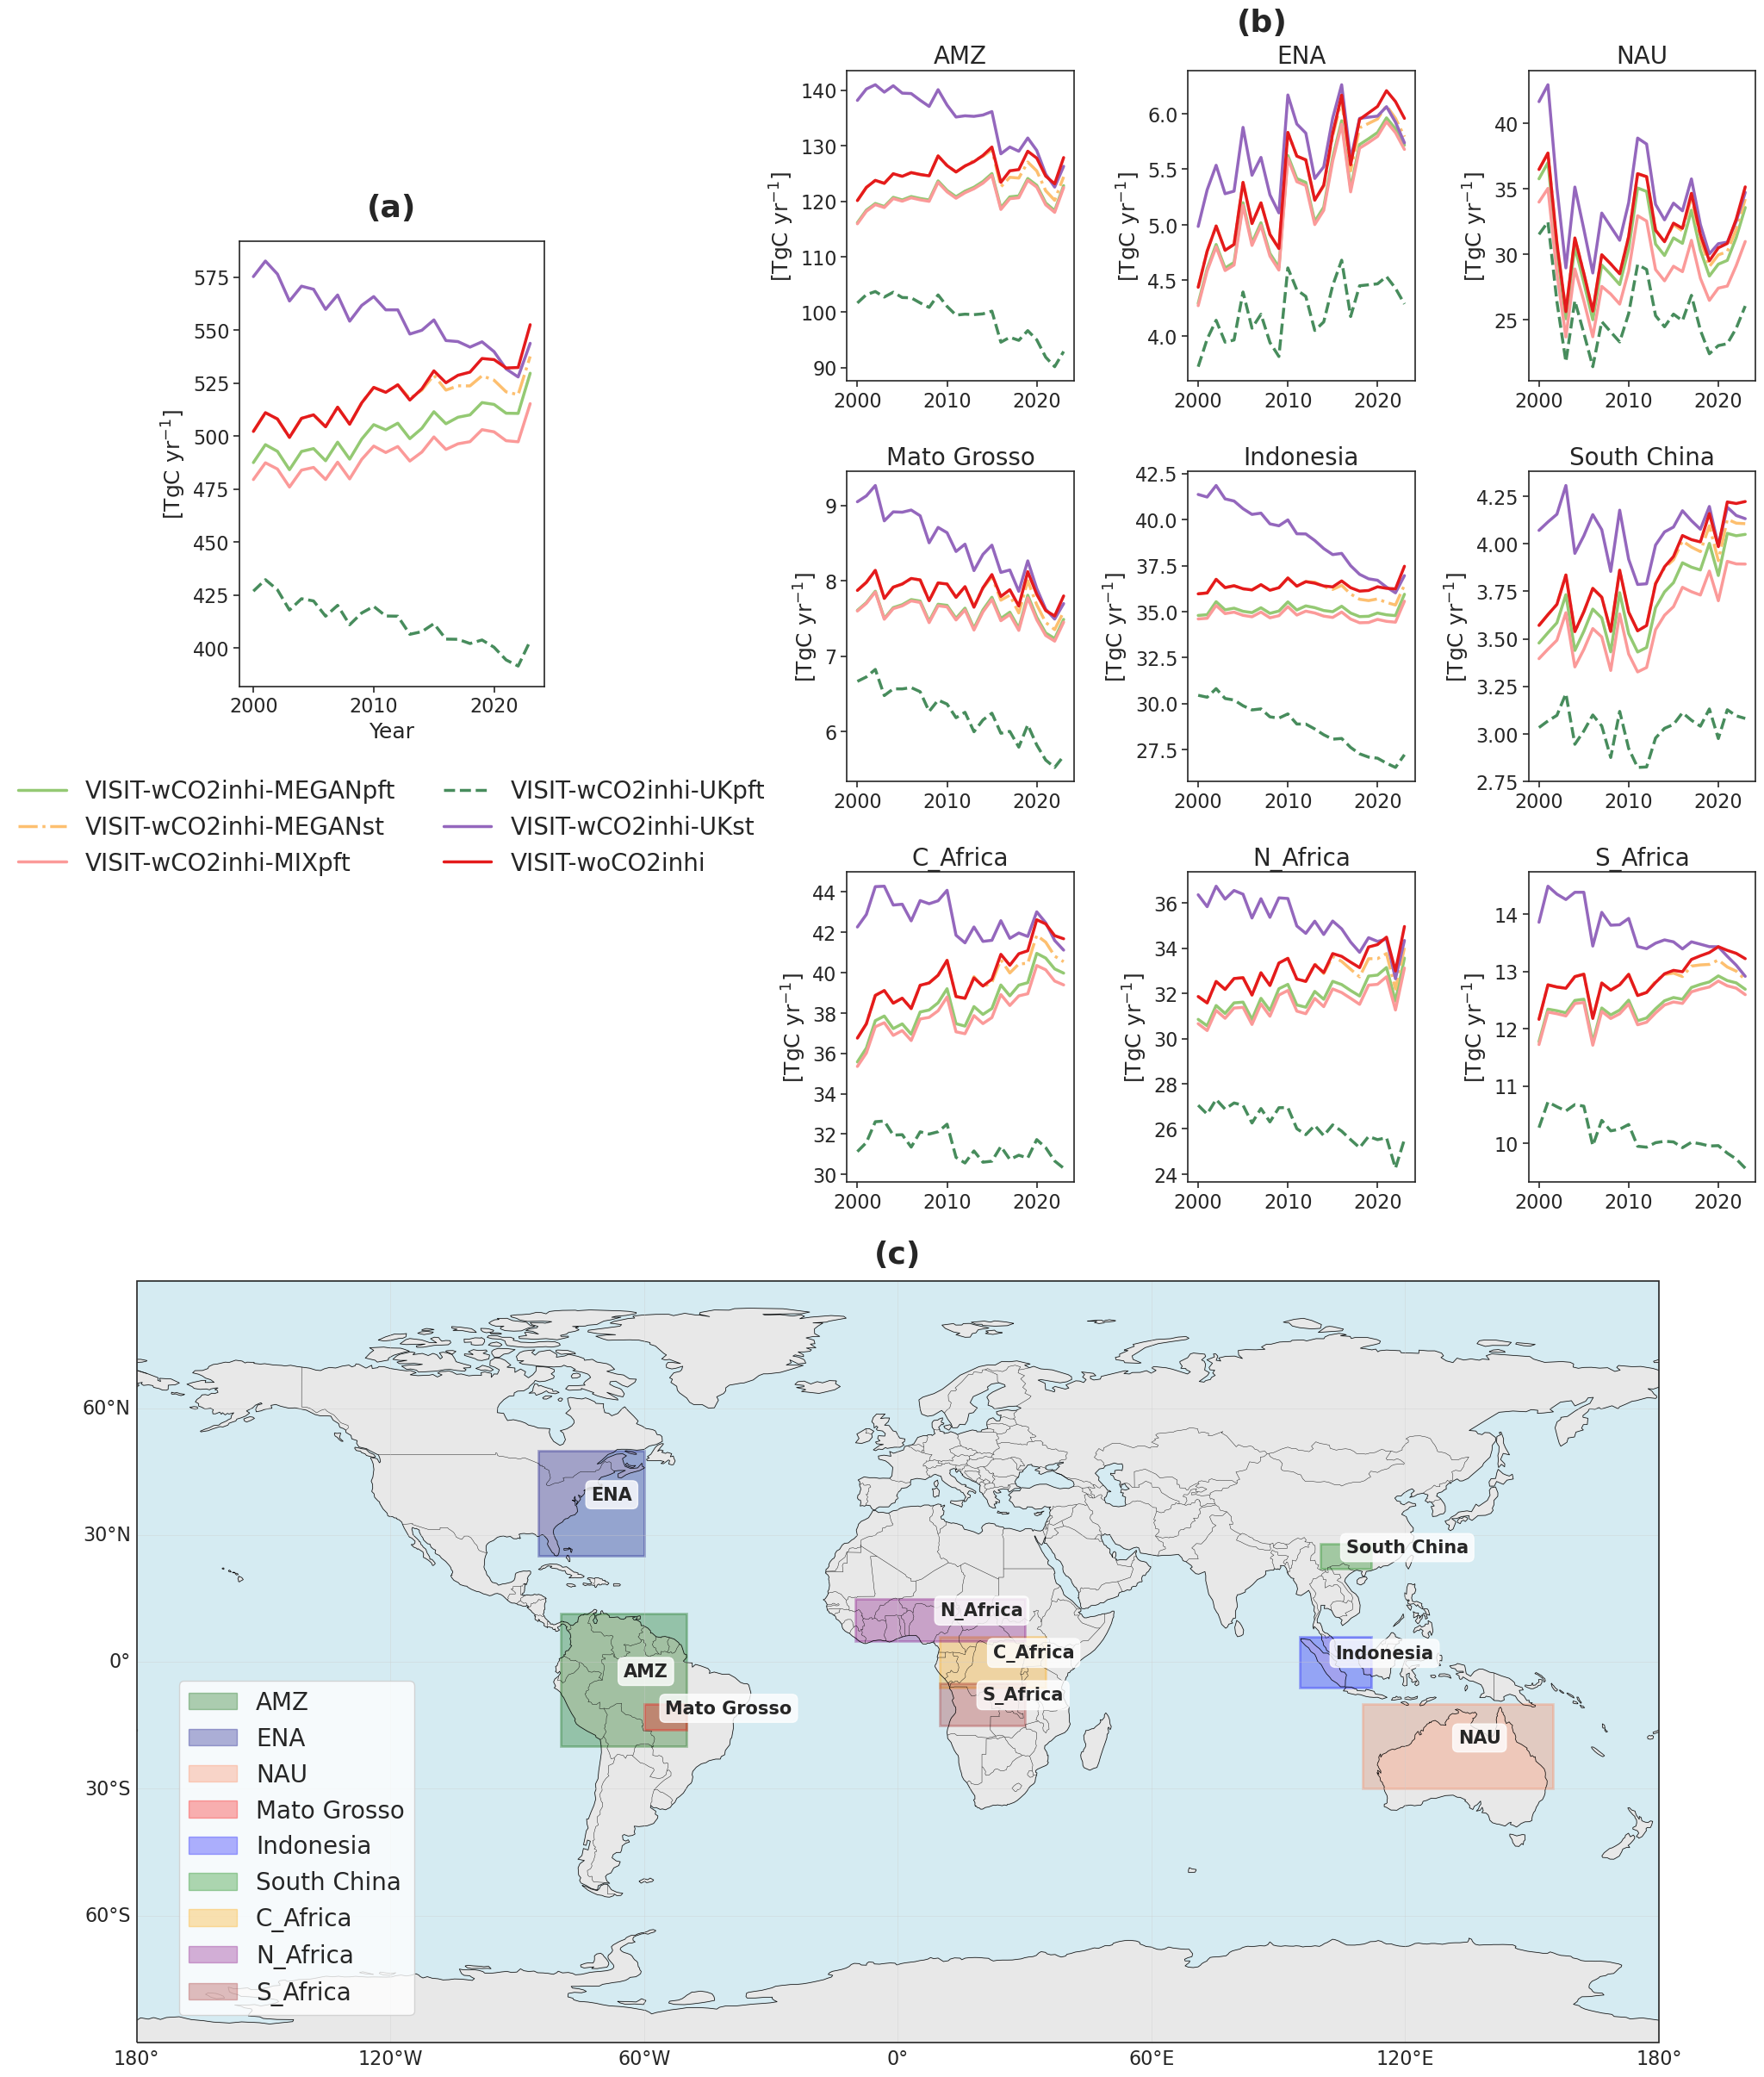

In [9]:
# plt_glob_annual_variation(emiisop_co2Inhi_2k) # Figure 3a
# plt_reg_annual_variation(emiisop_co2Inhi_2k) # Figure 3b
# plt_regional_bbox() # Figure 3c
FS_INDEX = 26    # panel indices (a) (b) (c)
FS_TITLE = 20    # regional panel titles
FS_LABEL = 18    # axis labels
FS_TICK = 16     # tick labels
FS_LEGEND = 20   # legend text
FS_REGION = 15   # region names written on the map (c)
 
 
# Plot Fig. 3a - Interannual variations in global isoprene emission over 2000–2023
def plt_glob_annual_variation(emiisop, ax=None, save_path=None):  # CHANGED [Fig3]: optional ax to draw into
    model_names = list(emiisop.multi_models.keys())
    colors = [
        "#94C973",
        "#fdbf6f",
        "#fb9a99",
        "#478C5C",
        "#9467BD",
        "#e41a1c",
    ]
    colors_dict = {
        m_name: c for m_name, c in zip(model_names, colors[: len(model_names)])
    }
    lss = ["-", "-.", "-", "--", "-", "-"]
    ls_dict = {m_name: c for m_name, c in zip(model_names, lss[: len(model_names)])}
    if ax is None:  # ADDED [Fig3]: standalone use keeps the original figure
        fig, ax = plt.subplots(figsize=(9.5, 6.5), layout="constrained")
    # REMOVED [Fig3]: fig, ax = plt.subplots(figsize=(9.5, 6.5), layout="constrained")
    # REMOVED [Fig3]: axbox = ax.get_position()   (legend is now anchored to the axes, see below)
    for m_name in model_names:
        cmip6_obj = emiisop.multi_models[m_name]
        x, y = cmip6_obj.global_rate["year"], cmip6_obj.global_rate
        ax.plot(
            x,
            y,
            label=m_name,
            linewidth=2.5,
            color=colors_dict[m_name],
            ls=ls_dict[m_name],
        )
        res = pymk.original_test(y, alpha=0.05)
        print(m_name, res)
 
    ax.set_xlabel("Year", fontsize=FS_LABEL)  # CHANGED [Fig3]: explicit font size
    ax.set_ylabel(VIZ_OPT[emiisop.var_name]["line_bar_unit"], fontsize=FS_LABEL)  # CHANGED [Fig3]: 14 -> FS_LABEL
    ax.tick_params(labelsize=FS_TICK)  # ADDED [Fig3]
    ax.legend(
        loc="upper center",  # CHANGED [Fig3]: was loc="center" in figure coordinates
        ncol=2,  # CHANGED [Fig3]: 3 -> 2 columns, the larger legend text needs the room
        bbox_to_anchor=(0.5, -0.16),  # CHANGED [Fig3]: anchored below THIS axes, so it works inside a multi-panel figure
        fontsize=FS_LEGEND,  # ADDED [Fig3]
        frameon=False,  # ADDED [Fig3]
    )
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
 
 
# Plot Fig. 3b- Interannual variations in regional isoprene emission over 2000-2023
def plt_reg_annual_variation(emiisop, fig=None):  # CHANGED [Fig3]: optional Figure/SubFigure to draw into
    model_names = emiisop.multi_models.keys()
    colors = [
        "#94C973",
        "#fdbf6f",
        "#fb9a99",
        "#478C5C",
        "#9467BD",
        "#e41a1c",
    ]
    colors_dict = {
        m_name: c for m_name, c in zip(model_names, colors[: len(model_names)])
    }
    lss = ["-", "-.", "-", "--", "-", "-"]
    ls_dict = {m_name: c for m_name, c in zip(model_names, lss[: len(model_names)])}
    roi_ds = {}
 
    if fig is None:  # ADDED [Fig3]: standalone use keeps the original figure
        fig = plt.figure(figsize=(3.5 * 3, 3.6 * 3), layout="constrained")
    axis = fig.subplots(3, 3, gridspec_kw={"wspace": 0.05, "hspace": 0.05})  # CHANGED [Fig3]: was fig, axis = plt.subplots(3, 3, figsize=(3.5 * 3, 3.6 * 3), layout="constrained")
 
    for i, roi in enumerate(LIST_REGION_CO2INHI):
        ri, ci = i // 3, i % 3
        ax = axis[ri, ci]
 
        axbox = ax.get_position()
        roi_ds[roi] = []
        years = []
        for name in model_names:
            years.append(emiisop.multi_models[name].regional_rate[roi]["year"])
            roi_ds[roi].append(emiisop.multi_models[name].regional_rate[roi])
        for x, y, n in zip(years, roi_ds[roi], model_names):
            ax.plot(
                x,
                y,
                label=n,
                linewidth=2.5,
                color=colors_dict[n],
                ls=ls_dict[n],
            )
        ax.set_title(f"{roi}", fontsize=FS_TITLE)  # CHANGED [Fig3]: title_sz -> FS_TITLE
        # ax.set_xlabel("Year")
        ax.set_ylabel(VIZ_OPT["emiisop"]["line_bar_unit"], fontsize=FS_LABEL)  # CHANGED [Fig3]: explicit font size
        ax.tick_params(labelsize=FS_TICK)  # ADDED [Fig3]
        # if ri == 2 and ci ==1:
        #     ax.legend(
        #         loc="center",
        #         ncol=3,
        #         bbox_to_anchor=[axbox.x0 + 0.5 * axbox.width, axbox.y0 - 0.25],
        #         fontsize=legend_sz,
        #     )
 
    # handles, labels = ax.get_legend_handles_labels()
    # fig.legend(
    #     handles,
    #     labels,
    #     ncol=3,
    #     loc="outside lower center",  # CHANGED [Fig3]: was loc="center", bbox_to_anchor=(0.5, -0.05); now reserved inside the layout
    #     fontsize=FS_LEGEND,  # ADDED [Fig3]
    #     frameon=False,  # ADDED [Fig3]
    # )
    # REMOVED [Fig3]: plt.rcParams.update({"font.size": legend_sz})   (ran after plotting, so it had no effect)
 
 
# Plot Fig. 3c - Bounding boxes of the regions of interest
def plt_regional_bbox(ax=None):  # CHANGED [Fig3]: optional ax (must be a PlateCarree GeoAxes) to draw into
 
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    from matplotlib.patches import Rectangle
 
    # Define the regions
    regions = {
        "AMZ": {
            "lat": [11.439, -20.0],  # 11.439° to -20.0°
            "lon": [-79.729, -50.0],  # -79.729° to -50.0°
            "color": "darkgreen",
        },
        # AMZ: Amazon
        "ENA": {
            "lat": [50.0, 25.0],  # 50.0° to 25.0°
            "lon": [-85.0, -60.0],  # -85.0° to -60.0°
            "color": "navy",
        },
        # ENA: E. North America
        "NAU": {
            "lat": [-10.0, -30.0],  # -10.0° to -30.0°
            "lon": [110.0, 155.0],  # 110.0° to 155.0°
            "color": "coral",
        },
        "Mato Grosso": {
            "lat": [-10, -16],  # 10°S to 16°S
            "lon": [-60, -50],  # 60°W to 50°W
            "color": "red",
        },
        "Indonesia": {
            "lat": [6, -6],  # 6°N to 6°S (descending)
            "lon": [95, 112],  # 95°E to 112°E
            "color": "blue",
        },
        "South China": {
            "lat": [28, 22],  # 28°N to 22°N
            "lon": [100, 112],  # 100°E to 112°E
            "color": "green",
        },
        "C_Africa": {
            "lat": [6, -6],  # 6°N to 6°S
            "lon": [10, 35],  # 10°E to 35°E
            "color": "orange",
        },
        "N_Africa": {
            "lat": [15, 5],  # 15°N to 5°N
            "lon": [-10, 30],  # 10°W to 30°E → -10 to 30
            "color": "purple",
        },
        "S_Africa": {
            "lat": [-5, -15],  # 5°S to 15°S
            "lon": [10, 30],  # 10°E to 30°E
            "color": "brown",
        },
    }
 
    # Create the map
    standalone = ax is None  # ADDED [Fig3]
    if standalone:  # ADDED [Fig3]: only create a new figure when no axes is supplied
        fig = plt.figure(figsize=(15, 10))
        ax = plt.axes(projection=ccrs.PlateCarree())
 
    # Add map features
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.add_feature(cfeature.OCEAN, color="lightblue", alpha=0.5)
    ax.add_feature(cfeature.LAND, color="lightgray", alpha=0.5)
 
    # Add gridlines
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": FS_TICK}  # ADDED [Fig3]
    gl.ylabel_style = {"size": FS_TICK}  # ADDED [Fig3]
 
    # Plot each region as a rectangle
    for region_name, coords in regions.items():
        # Calculate rectangle parameters
        lat_min = min(coords["lat"])
        lat_max = max(coords["lat"])
        lon_min = min(coords["lon"])
        lon_max = max(coords["lon"])
 
        width = lon_max - lon_min
        height = lat_max - lat_min
 
        # Create rectangle
        rect = Rectangle(
            (lon_min, lat_min),
            width,
            height,
            linewidth=2,
            edgecolor=coords["color"],
            facecolor=coords["color"],
            alpha=0.3,
            transform=ccrs.PlateCarree(),
        )
 
        # Add rectangle to map
        ax.add_patch(rect)
 
        # Add label at center of rectangle
        center_lat = (lat_min + lat_max) / 2
        center_lon = (lon_min + lon_max) / 2
 
        ax.text(
            center_lon,
            center_lat,
            region_name,
            transform=ccrs.PlateCarree(),
            ha="left",
            va="bottom",
            fontsize=FS_REGION,  # CHANGED [Fig3]: 10 -> FS_REGION
            fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
        )
 
    # Set global extent
    ax.set_global()
 
    # Add title
    if standalone:  # CHANGED [Fig3]: title only for standalone use; in the combined figure the index "(c)" replaces it
        plt.title(
            "Bounding box of regions of interest", fontsize=16, fontweight="bold", pad=20
        )
 
    # Add legend
    legend_elements = [
        patches.Patch(color=coords["color"], alpha=0.3, label=region_name)
        for region_name, coords in regions.items()
    ]
    ax.legend(  # CHANGED [Fig3]: plt.legend -> ax.legend (plt.legend acts on the "current" axes, not necessarily this one)
        handles=legend_elements,
        loc="lower left",
        bbox_to_anchor=(0.02, 0.02),
        fontsize=FS_LEGEND,  # ADDED [Fig3]
    )
 
    if standalone:  # CHANGED [Fig3]: only for standalone use; the combined figure handles layout and show
        plt.tight_layout()
        plt.show()
 
 
# ADDED [Fig3]: builds the combined figure  (a) top-left | (b) top-right | (c) bottom, full width
def plt_fig3_combined(emiisop, save_path="./plots/Figure3.png"):
    import cartopy.crs as ccrs
 
    # Temporarily raise the default font sizes for anything not set explicitly (e.g. axis offset text)
    with plt.rc_context({"font.size": FS_TICK}):
        fig = plt.figure(figsize=(20, 24), layout="constrained")
        sf_top, sf_c = fig.subfigures(2, 1, height_ratios=[1.45, 1])
        sf_a, sf_b = sf_top.subfigures(1, 2, width_ratios=[1, 1.4])
 
        # (a) global time series, vertically centred next to the 3x3 grid; legend sits below the axes
        gs_a = sf_a.add_gridspec(3, 1, height_ratios=[0.9, 2.2, 1.6])
        ax_a = sf_a.add_subplot(gs_a[1])
        plt_glob_annual_variation(emiisop, ax=ax_a)
        ax_a.set_title("(a)", fontsize=FS_INDEX, fontweight="bold", pad=20)
 
        # (b) 3x3 regional time series with one shared legend below
        plt_reg_annual_variation(emiisop, fig=sf_b)
        sf_b.suptitle("(b)", fontsize=FS_INDEX, fontweight="bold")
 
        # (c) map of the region boxes, full width
        ax_c = sf_c.add_subplot(projection=ccrs.PlateCarree())
        plt_regional_bbox(ax=ax_c)
        ax_c.set_title("(c)", fontsize=FS_INDEX, fontweight="bold", pad=15)
 
        if save_path:
            fig.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.show()

plt_fig3_combined(emiisop_co2Inhi_2k)
 

Figure 4. Global distribution of annual isoprene emission trends for 2000–2023. The first panel shows the relative trend (% yr-¹) from the VISIT simulation without CO2 inhibition (VISIT-woCO2inhi), including only significant values (with p < 0.05). Subsequent panels present relative trend differences (% yr-¹) for each CO2 inhibition sensitivity case (e.g. VISIT-wCO2inhi-MEGANpft minus VISIT-woCO2inhi).

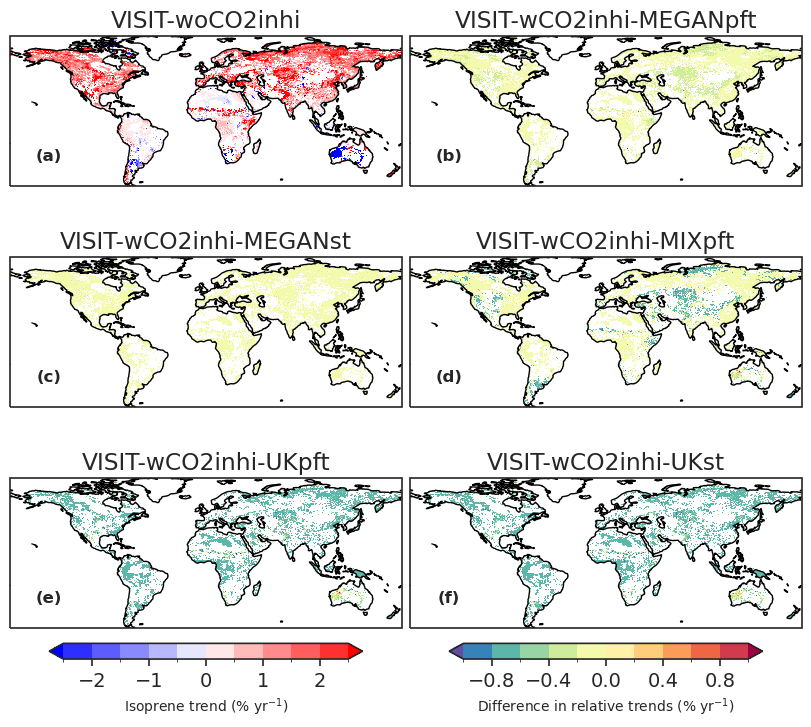

In [10]:
def plt_emiisop_trends_diff_map(emiisop):
    list_models = list(emiisop.multi_models.keys())
    list_models = ["VISIT-woCO2inhi"] + [
        m for m in list_models if m != "VISIT-woCO2inhi"
    ]

    # Base map color scale settings
    vmin_base, vmax_base = -2.5, 2.5
    levels_base = 11
    bounds_base = np.linspace(vmin_base, vmax_base, levels_base)
    norm_base = mpl.colors.BoundaryNorm(bounds_base, mpl.cm.plasma.N, extend="both")
    cmap_base = mpl.colormaps.get_cmap("bwr")

    # Difference map color scale settings
    vmin_diff, vmax_diff = -1, 1
    levels_diff = 11
    bounds_diff = np.linspace(vmin_diff, vmax_diff, levels_diff)
    norm_diff = mpl.colors.BoundaryNorm(bounds_diff, mpl.cm.plasma.N, extend="both")
    cmap_diff = mpl.colormaps.get_cmap("Spectral_r")

    rows, cols = 3, 2
    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(4 * cols, 2.5 * rows),
        layout="constrained",
        subplot_kw=dict(projection=ccrs.PlateCarree()),
    )
    axes = axes.flatten()

    # Compute VISIT-woCO2inhi trend (% per year)
    visit_slope_ds = cal_org_trends_map(emiisop, "emiisop", "VISIT-woCO2inhi")
    visit_slope = list(visit_slope_ds.values())[0]
    visit_mean = emiisop.multi_models["VISIT-woCO2inhi"].annual_per_area_unit.mean(
        "year"
    )
    visit_mask = emiisop.multi_models["VISIT-woCO2inhi"].ds_mask["mask"]
    visit_percent = (visit_slope / (visit_mean * visit_mask)) * 100
    visit_percent = visit_percent.where(np.isfinite(visit_percent)).sel(
        lat=slice(82.75, -55.25)
    )

    # Plot base map
    ax = axes[0]
    visit_percent.plot.pcolormesh(
        ax=ax,
        cmap=cmap_base,
        vmin=vmin_base,
        vmax=vmax_base,
        levels=levels_base,
        extend="both",
        add_colorbar=False,
    )
    ax.coastlines()
    ax.text(
            0.10, 0.20, f"({chr(ord('a') + 0)})",
            transform=ax.transAxes, ha="center", va="center",
            fontsize=12, fontweight="bold",
        )
    ax.set_title("VISIT-woCO2inhi")

    # Plot difference maps (% per year)
    for i, m in enumerate(list_models[1:], start=1):
        ax = axes[i]

        slope_ds = cal_org_trends_map(emiisop, "emiisop", m)
        slope = list(slope_ds.values())[0]
        model_mean = emiisop.multi_models[m].annual_per_area_unit.mean("year")
        model_mask = emiisop.multi_models[m].ds_mask["mask"]
        model_percent = (slope / (model_mean * model_mask)) * 100

        diff_percent = (model_percent - visit_percent).where(np.isfinite(visit_percent))
        diff_percent = diff_percent.sel(lat=slice(82.75, -55.25))

        diff_percent.plot.pcolormesh(
            ax=ax,
            vmin=vmin_diff,
            vmax=vmax_diff,
            cmap=cmap_diff,
            levels=levels_diff,
            extend="both",
            add_colorbar=False,
        )
        ax.coastlines()
        ax.text(
                    0.10, 0.20, f"({chr(ord('a') + i)})",
                    transform=ax.transAxes, ha="center", va="center",
                    fontsize=12, fontweight="bold",
                )
        ax.set_title(f"{m}")

    # Turn off unused axes
    for j in range(len(list_models), len(axes)):
        axes[j].set_axis_off()

    # Colorbar for base map (left column)
    sm_base = mpl.cm.ScalarMappable(cmap=cmap_base, norm=norm_base)
    sm_base.set_array([])
    cbar_base = fig.colorbar(
        sm_base,
        ax=axes[::2],  # left column
        orientation="horizontal",
        shrink=0.8,
        pad=0.02,
        extend="both",
    )
    cbar_base.set_label("Isoprene trend (% yr$^{-1}$)", size=10)

    # # Colorbar for difference maps (right column)
    sm_diff = mpl.cm.ScalarMappable(cmap=cmap_diff, norm=norm_diff)
    sm_diff.set_array([])
    cbar_diff = fig.colorbar(
        sm_diff,
        ax=axes[1::2],  # right column
        orientation="horizontal",
        shrink=0.8,
        pad=0.02,
        extend="both",
    )
    cbar_diff.set_label("Difference in relative trends (% yr$^{-1}$)", size=10)
    fig.savefig("./plots/Figure4.png", dpi=300, bbox_inches="tight")
plt_emiisop_trends_diff_map(emiisop_co2Inhi_2k)

Figure 5. (a) Time series of isoprene emission changes (TgC yr⁻¹) relative to the year 2000 for MEGANpft, UKpft, and woCO2inhi simulations, attributed to CO2 fertilization (co2f), CO2 inhibition (co2fi), land-use and land-cover change (lulcc), climate (clim), and all combined factors (all). (b) Attributed linear trends in global isoprene emissions for each driver; asterisks (*) denote p < 0.05.

1.575723800249008
-0.6990400560672407
0.6833271384144362
-1.5656152388517934
-0.594650917598422
-2.2412771224420682
1.96598170418891
-0.7190057291633527
1.0074955601123419


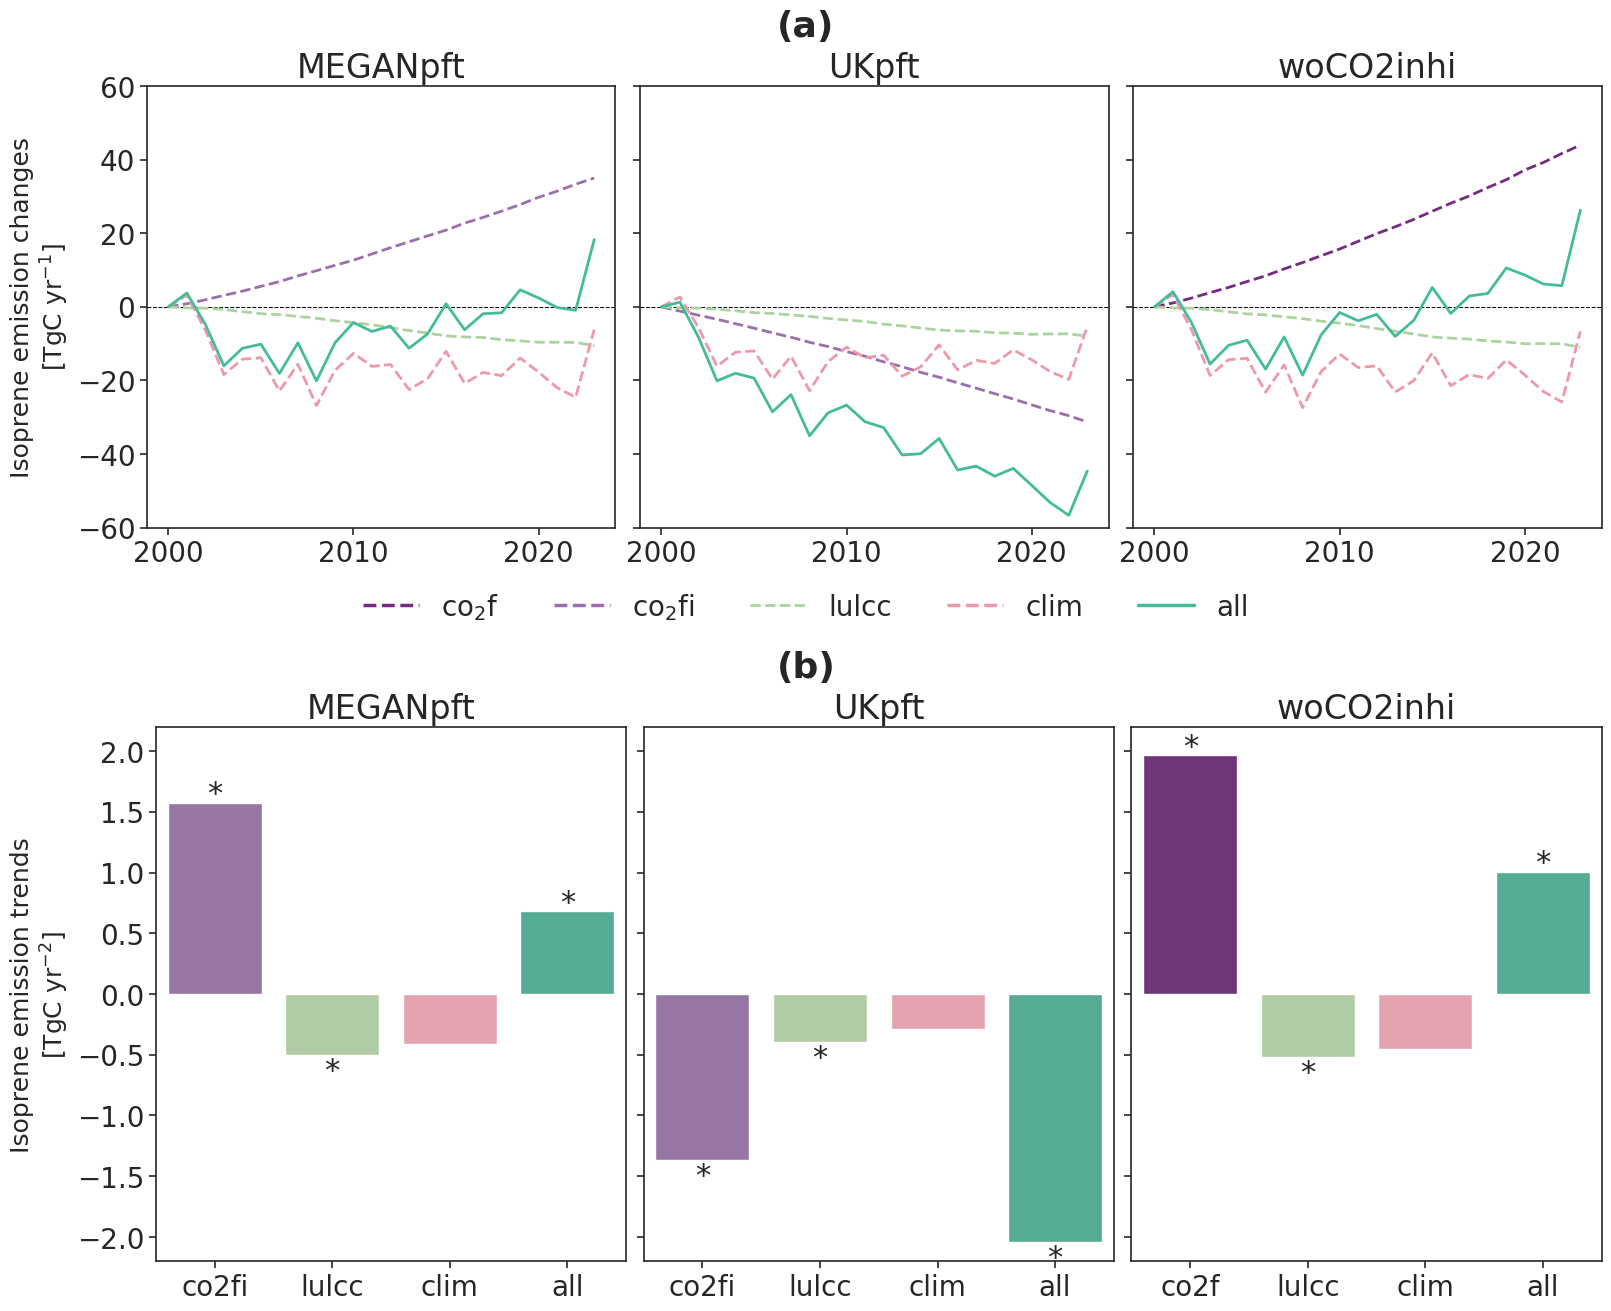

In [11]:
# plt_glob_changes_by_driver(visits, "main") # Figure 5a
# plt_glob_trends_by_driver(visits, "main") # Figure 5b
FS_INDEX = 26    # panel indices (a) (b)
FS_TITLE = 24    # model names above each panel
FS_LABEL = 18    # y-axis labels
FS_TICK = 20     # tick labels (incl. driver names under the bars)
FS_LEGEND = 20   # legend text
FS_STAR = 22     # significance asterisks on the bars

def plt_glob_trends_by_driver(models, mode="main", fig=None):  # CHANGED [Fig6+7]: optional Figure/SubFigure to draw into
    rows = 1
    cols = 3
    if fig is None:  # ADDED [Fig6+7]: standalone use keeps the original figure
        fig = plt.figure(figsize=(3 * cols, 4.5 * rows), layout="constrained")
    axes = fig.subplots(rows, cols, sharey=True)  # CHANGED [Fig6+7]: was fig, axes = plt.subplots(rows, cols, sharey=True, figsize=(3 * cols, 4.5 * rows), layout="constrained")
    for i, m in enumerate(models.keys()):
        # r = i // cols
        c = i % cols
        ax = axes[c]
 
        if mode == "main":
            df = models[m].main_df_rate
        else:
            df = models[m].clim_df_rate
        list_drivers = df["driver"].values
        color_list = [colors_dict[d] for d in list_drivers]
        barplot = sns.barplot(
            df,
            x="driver",
            y="slope",
            ax=ax,
            palette=sns.color_palette(color_list),
        )
        for p, sig in zip(barplot.patches, df["sig"]):
            if sig == True:
                h = p.get_height()
                add_h = 0.2
                if mode == "clim":
                    add_h = 0.1
                h = h if h > 0 else h - add_h
                barplot.text(p.get_x() + p.get_width() / 2.0, h, "*", ha="center", fontsize=FS_STAR)  # CHANGED [Fig6+7]: added fontsize
                print(h)
        ax.set_title(m, fontsize=FS_TITLE)  # CHANGED [Fig6+7]: title_sz -> FS_TITLE
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.tick_params(labelsize=FS_TICK)  # ADDED [Fig6+7]
        # if r in [0, 1]:
        axes[0].set_ylabel("Isoprene emission trends\n[TgC yr$^{-2}$]", fontsize=FS_LABEL)  # CHANGED [Fig6+7]: unit_sz -> FS_LABEL; label split over 2 lines so it fits the panel height
 
        ax.set_ylim(-2.2, 2.2)
        if mode == "clim":
            ax.set_ylim(-0.75, 0.75)
        # fig_name = "Fig7"
        # if mode == "clim":
        #     ax.set_ylim(-0.25, 0.25)
        #     fig_name = "Fig9"
        # if fig_name:
        #     path_ = f"../figures/{fig_name}.tiff"
        #     fig.savefig(
        #         path_,
        #         format="tiff",
        #         dpi=300,
        #         bbox_inches="tight",
        #     )
 
 
# (this is the old Fig. 6 / Fig. 8 function; it is panel (a))
def plt_glob_changes_by_driver(models, mode="main", fig=None):  # CHANGED [Fig6+7]: optional Figure/SubFigure to draw into
 
    rows = 1
    cols = 3
    if fig is None:  # ADDED [Fig6+7]: standalone use keeps the original figure
        fig = plt.figure(figsize=(4 * cols, 4 * rows), layout="constrained")
    axes = fig.subplots(rows, cols, sharex=True, sharey=True)  # CHANGED [Fig6+7]: was fig, axes = plt.subplots(rows, cols, sharex=True, sharey=True, figsize=(4 * cols, 4 * rows), layout="constrained")
 
    for i, m in enumerate(models.keys()):
        # r = i // cols
        c = i % cols
        ax = axes[c]
        axbox = ax.get_position()
 
        ax.axhline(0, color="black", linewidth=0.75, ls="--")
 
        if mode == "main":
            df = models[m].main_rates_ts
            legend_elements = [
                Line2D([0], [0], color="#762a83", lw=2.5, label="co$_2$f", ls="--"),
                Line2D([0], [0], color="#9970ab", lw=2.5, label="co$_2$fi", ls="--"),
                Line2D([0], [0], color="#acd39e", lw=2, label="lulcc", ls="--"),
                Line2D([0], [0], color="#ee99aa", ls="--", lw=2.5, label="clim"),
                Line2D([0], [0], color="#44bb99", ls="-", lw=2.5, label="all"),
            ]
        else:
            df = models[m].clim_rates_ts
        pred_fields = df.columns
        for f in pred_fields:
            obj = df[f]
            x, y = obj.index, obj.values
            ax.plot(
                x,
                y,
                label=f,
                linewidth=2,
                color=colors_dict[f],
                ls=linestyles_dict[f],
            )
        ax.set_ylim(-60, 60)
        # if mode == "clim":
        #     ax.set_ylim(-40, 40)
        # ax.set_ylim([-160, 110])
        ax.set_title(m, fontsize=FS_TITLE)  # CHANGED [Fig6+7]: title_sz -> FS_TITLE
        ax.tick_params(labelsize=FS_TICK)  # ADDED [Fig6+7]
        # if r in [0, 1]:
        axes[0].set_ylabel(
            "Isoprene emission changes\n[TgC yr$^{-1}$]", fontsize=FS_LABEL  # CHANGED [Fig6+7]: unit_sz -> FS_LABEL; label split over 2 lines so it fits the panel height
        )
 
    if mode == "main":
        fig.legend(
            handles=legend_elements,
            ncol=5,
            loc="outside lower center",  # CHANGED [Fig6+7]: was loc="upper center", bbox_to_anchor=(0.5, -0.01); now reserved inside the layout
            borderaxespad=0,  # ADDED [Fig6+7]: spacing between the legend and the axes
            fontsize=FS_LEGEND,  # CHANGED [Fig6+7]: legend_sz -> FS_LEGEND
            frameon=False,  # ADDED [Fig6+7]
        )
        fig_name = "Fig6"
 
    else:
        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(
            handles,
            labels,
            ncol=4,
            loc="outside lower center",  # CHANGED [Fig6+7]: as above
            borderaxespad=0,  # ADDED [Fig6+7]: to give the legend some space from the axes
            fontsize=FS_LEGEND,  # CHANGED [Fig6+7]: legend_sz -> FS_LEGEND
            frameon=False,  # ADDED [Fig6+7]
        )
        fig_name = "Fig8"
 
 
# ADDED [Fig6+7]: builds the combined figure  (a) changes over time | (b) trends per driver, stacked
def plt_fig6_7_combined(models, mode="main", save_path=None):
    # Temporarily raise the default font size for anything not set explicitly
    with plt.rc_context({"font.size": FS_TICK}):
        fig = plt.figure(figsize=(16, 13), layout="constrained")
        sf_a, sf_b = fig.subfigures(2, 1, height_ratios=[1, 1.05])
 
        # (a) time series of changes, legend below the panels
        plt_glob_changes_by_driver(models, mode=mode, fig=sf_a)
        sf_a.suptitle("(a)", fontsize=FS_INDEX, fontweight="bold")
 
        # (b) bar chart of trends per driver
        plt_glob_trends_by_driver(models, mode=mode, fig=sf_b)
        sf_b.suptitle("(b)", fontsize=FS_INDEX, fontweight="bold")
 
        if save_path:
            fig.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.show()
plt_fig6_7_combined(visits, mode="main", save_path="./plots/Figure5.png")

Figure 6. (a) Time series of isoprene emission changes (TgC yr⁻¹) relative to the year 2000 for MEGANpft, UKpft, and woCO2inhi simulations, attributed to temperature (tas), shortwave radiation (rsds), precipitation (pr), and total climate factors (clim). (b) Attributed linear trends in global isoprene emissions for each climate driver; asterisks (*) denote p < 0.05.

0.543026114131549
-0.3538099870507183
-0.61340655539864
0.40843049450036306
-0.31043827929481177
-0.40360356508718664
0.5673172679364349
-0.36381122766054674
-0.6658723061925892


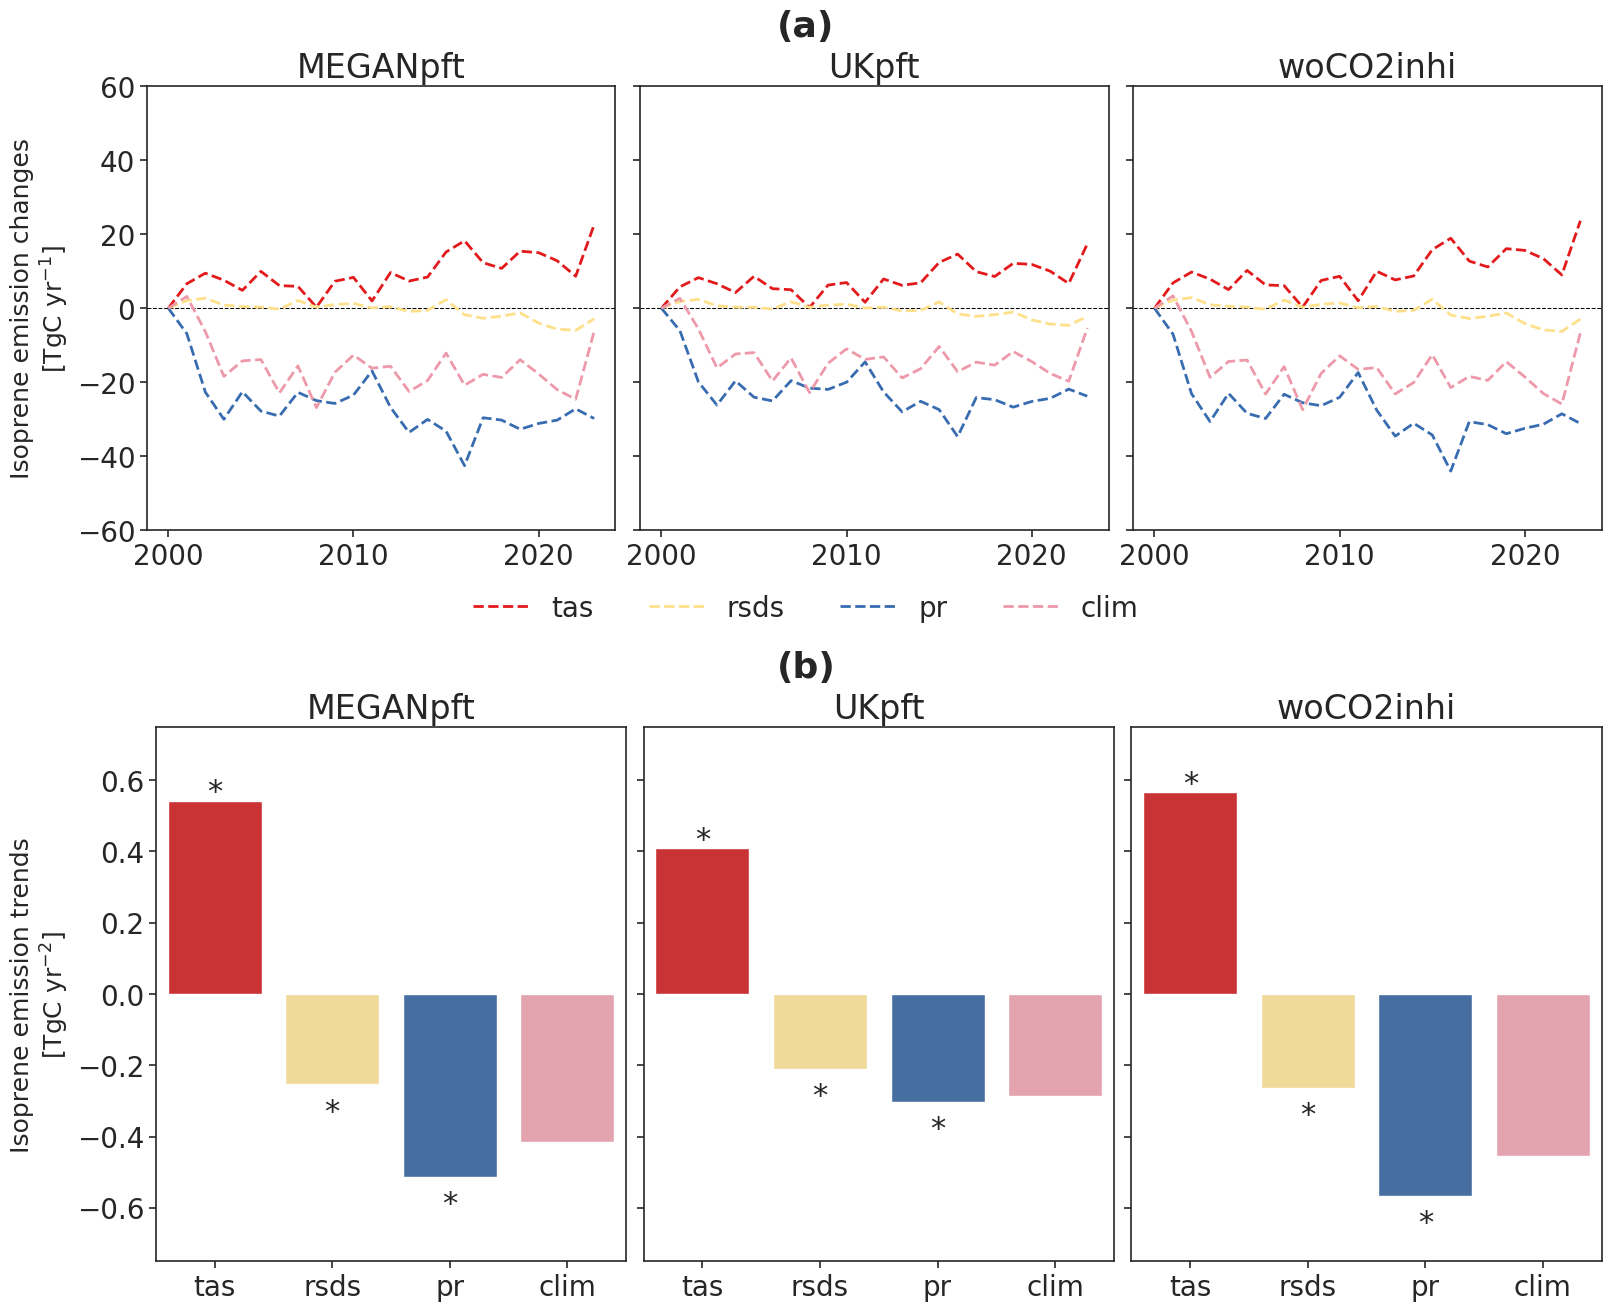

In [12]:
# plt_glob_changes_by_driver(visits, "clim") # Figure 6a
# plt_glob_trends_by_driver(visits, "clim") # Figure 6b
plt_fig6_7_combined(visits, "clim", save_path="./plots/Figure6.png")

Figure 7. Global (a) and regional (b) annual isoprene emission totals from selected VISIT sensitivity simulations and other available datasets. Numbers in panel (a) show global emission trends during the study period. Time periods differ among datasets.

ALBERI-v2021 Mann_Kendall_Test(trend='no trend', h=False, p=0.0814429797390801, z=1.7423742438807115, Tau=0.30718954248366015, s=47.0, var_s=697.0, slope=1.0671059154981404, intercept=297.13217258169556)
CAMS-GLOB-BIO Mann_Kendall_Test(trend='increasing', h=True, p=0.005899983624599869, z=2.7532887337723295, Tau=0.4057971014492754, s=112.0, var_s=1625.3333333333333, slope=1.2838659434705906, intercept=372.1605523566973)
OMIv2-TOPDOWN Mann_Kendall_Test(trend='no trend', h=False, p=0.854777098065548, z=0.1830266628259689, Tau=0.05128205128205128, s=4.0, var_s=268.6666666666667, slope=0.4517940231432078, intercept=389.0773756647963)
VISIT-wCO2inhi-MEGANpft Mann_Kendall_Test(trend='increasing', h=True, p=2.8287791442593857e-07, z=5.13451142244029, Tau=0.7536231884057971, s=208.0, var_s=1625.3333333333333, slope=1.3222972327519351, intercept=488.08717535589363)
VISIT-wCO2inhi-UKpft Mann_Kendall_Test(trend='decreasing', h=True, p=1.7958432074749453e-08, z=-5.6305994825794485, Tau=-0.82608695

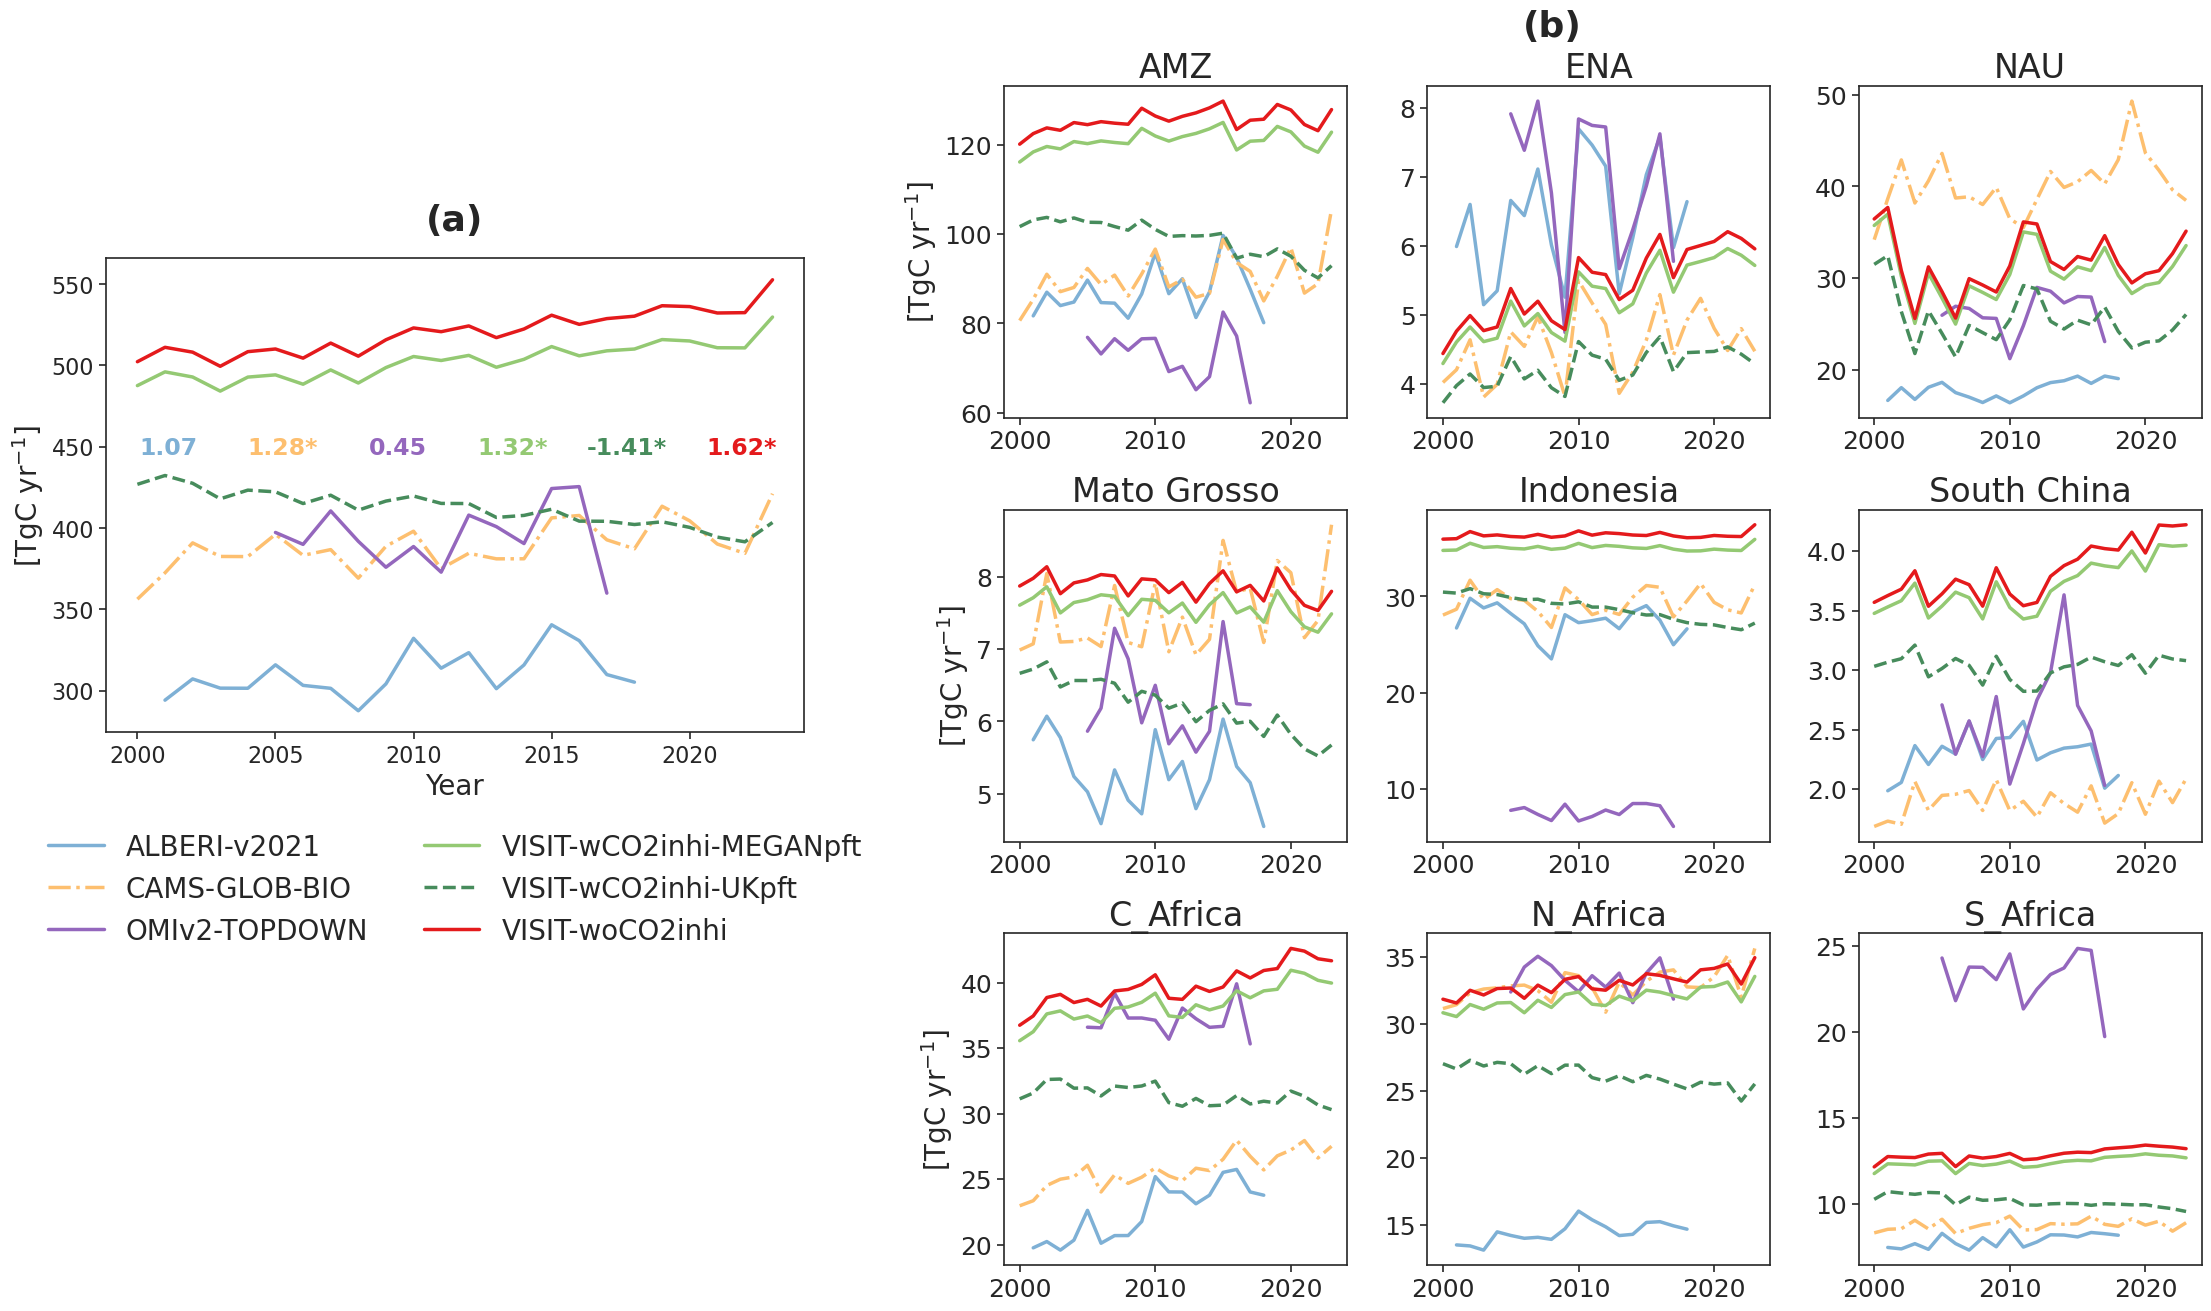

In [13]:
# plt_glob_annual_variation(emiisop_megan_compare)
# plt_reg_annual_variation(emiisop_megan_compare)

# ADDED [FigAB]: central font sizes for the combined figure (originals were ~10 pt)
FS_INDEX = 26    # panel indices (a) (b)
FS_TITLE = 22    # regional panel titles
FS_LABEL = 20    # axis labels
FS_TICK = 16     # tick labels
FS_LEGEND = 20   # legend text
FS_SLOPE = 17    # slope numbers inside panel (a)
# ADDED [FigAB-r2]: slightly larger fonts for panel (b) only (panel (a) keeps the sizes above)
FS_TITLE_B = 24  # regional panel titles
FS_LABEL_B = 20  # y-axis label (left column only)
FS_TICK_B = 18   # tick labels
FS_LEGEND_B = 18 # shared legend
SLOPE_Y = 0.6   # vertical position of the slope-number row in panel (a), axes fraction (0 bottom, 1 top)

# ADDED [FigAB]: colours / line styles fixed by model name so they match the reference figure
# (the original positional palette would give a different assignment for these six models).
# The ALBERI blue is estimated from the reference image; the others are from your original palette.
FIXED_COLORS = {
    "ALBERI-v2021": "#7EB0D5",
    "CAMS-GLOB-BIO": "#fdbf6f",
    "OMIv2-TOPDOWN": "#9467BD",
    "VISIT-wCO2inhi-MEGANpft": "#94C973",
    "VISIT-wCO2inhi-UKpft": "#478C5C",
    "VISIT-woCO2inhi": "#e41a1c",
}
FIXED_LS = {"CAMS-GLOB-BIO": "-.", "VISIT-wCO2inhi-UKpft": "--"}


# Plot Fig. 3a - Interannual variations in global isoprene emission over 2000–2023
def plt_glob_annual_variation(emiisop, ax=None):  # CHANGED [FigAB]: optional ax to draw into
    model_names = list(emiisop.multi_models.keys())
    colors = [
        "#94C973",
        "#fdbf6f",
        "#fb9a99",
        "#478C5C",
        "#9467BD",
        "#e41a1c",
    ]
    colors_dict = {
        m_name: c for m_name, c in zip(model_names, colors[: len(model_names)])
    }
    lss = ["-", "-.", "-", "--", "-", "-"]
    ls_dict = {m_name: c for m_name, c in zip(model_names, lss[: len(model_names)])}
    colors_dict.update({m: FIXED_COLORS[m] for m in model_names if m in FIXED_COLORS})  # ADDED [FigAB]
    ls_dict.update({m: FIXED_LS.get(m, "-") for m in model_names if m in FIXED_COLORS})  # ADDED [FigAB]
    if ax is None:  # ADDED [FigAB]: standalone use keeps the original figure
        fig, ax = plt.subplots(figsize=(6.5, 9.5), layout="constrained")
    # REMOVED [FigAB]: fig, ax = plt.subplots(figsize=(9.5, 6.5), layout="constrained")
    # REMOVED [FigAB]: axbox = ax.get_position()   (legend is now anchored to the axes, see below)
    slope_x = np.linspace(0.09, 0.91, len(model_names))  # ADDED [FigAB]: x positions of the slope numbers (axes fraction)
    for i, m_name in enumerate(model_names):  # CHANGED [FigAB]: enumerate, to place one slope number per model
        cmip6_obj = emiisop.multi_models[m_name]
        x, y = cmip6_obj.global_rate["year"], cmip6_obj.global_rate
        ax.plot(
            x,
            y,
            label=m_name,
            linewidth=2.5,
            color=colors_dict[m_name],
            ls=ls_dict[m_name],
        )
        res = pymk.original_test(y, alpha=0.05)
        print(m_name, res)
        # ADDED [FigAB]: Sen's slope in the colour of the line; "*" when the trend is significant (res.h is True)
        ax.text(
            slope_x[i],
            SLOPE_Y,
            f"{res.slope:.2f}" + ("*" if res.h else ""),
            transform=ax.transAxes,
            ha="center",
            va="center",
            color=colors_dict[m_name],
            fontsize=FS_SLOPE,
            fontweight="bold",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=1.5),  # ADDED [FigAB]: keeps the numbers readable where curves pass behind them
        )

    ax.set_xlabel("Year", fontsize=FS_LABEL)  # CHANGED [FigAB]: explicit font size
    ax.set_ylabel(VIZ_OPT[emiisop.var_name]["line_bar_unit"], fontsize=FS_LABEL)  # CHANGED [FigAB]: 14 -> FS_LABEL
    ax.tick_params(labelsize=FS_TICK)  # ADDED [FigAB]
    ax.legend(
        loc="upper center",  # CHANGED [FigAB]: was loc="center" in figure coordinates
        ncol=2,  # CHANGED [FigAB]: 3 -> 2 columns, the larger legend text needs the room
        bbox_to_anchor=(0.5, -0.16),  # CHANGED [FigAB]: anchored below THIS axes, so it works inside a multi-panel figure
        fontsize=FS_LEGEND,  # ADDED [FigAB]
        frameon=False,  # ADDED [FigAB]
    )


# Plot Fig. 3b- Interannual variations in regional isoprene emission over 2000-2023
def plt_reg_annual_variation(emiisop, fig=None):  # CHANGED [FigAB]: optional Figure/SubFigure to draw into
    model_names = emiisop.multi_models.keys()
    colors = [
        "#94C973",
        "#fdbf6f",
        "#fb9a99",
        "#478C5C",
        "#9467BD",
        "#e41a1c",
    ]
    colors_dict = {
        m_name: c for m_name, c in zip(model_names, colors[: len(model_names)])
    }
    lss = ["-", "-.", "-", "--", "-", "-"]
    ls_dict = {m_name: c for m_name, c in zip(model_names, lss[: len(model_names)])}
    colors_dict.update({m: FIXED_COLORS[m] for m in model_names if m in FIXED_COLORS})  # ADDED [FigAB]
    ls_dict.update({m: FIXED_LS.get(m, "-") for m in model_names if m in FIXED_COLORS})  # ADDED [FigAB]
    roi_ds = {}

    if fig is None:  # ADDED [FigAB]: standalone use keeps the original figure
        fig = plt.figure(figsize=(2 * 3, 4 * 3), layout="constrained")
    axis = fig.subplots(3, 3, gridspec_kw={"wspace": 0.05, "hspace": 0.05})  # CHANGED [FigAB]: was fig, axis = plt.subplots(3, 3, figsize=(3.5 * 3, 3.6 * 3), layout="constrained")

    for i, roi in enumerate(LIST_REGION_CO2INHI):
        ri, ci = i // 3, i % 3
        ax = axis[ri, ci]

        axbox = ax.get_position()
        roi_ds[roi] = []
        years = []
        for name in model_names:
            years.append(emiisop.multi_models[name].regional_rate[roi]["year"])
            roi_ds[roi].append(emiisop.multi_models[name].regional_rate[roi])
        for x, y, n in zip(years, roi_ds[roi], model_names):
            ax.plot(
                x,
                y,
                label=n,
                linewidth=2.5,
                color=colors_dict[n],
                ls=ls_dict[n],
            )
        ax.set_title(f"{roi}", fontsize=FS_TITLE_B)  # CHANGED [FigAB-r2]: FS_TITLE (20) -> FS_TITLE_B (24)
        # ax.set_xlabel("Year")
        if ci == 0:  # CHANGED [FigAB-r2]: y label only on the left-most column; the middle and right columns have none
            ax.set_ylabel(VIZ_OPT["emiisop"]["line_bar_unit"], fontsize=FS_LABEL_B)
        ax.tick_params(labelsize=FS_TICK_B)  # CHANGED [FigAB-r2]: FS_TICK (16) -> FS_TICK_B (18)
        # if ri == 2 and ci ==1:
        #     ax.legend(
        #         loc="center",
        #         ncol=3,
        #         bbox_to_anchor=[axbox.x0 + 0.5 * axbox.width, axbox.y0 - 0.25],
        #         fontsize=legend_sz,
        #     )

    # handles, labels = ax.get_legend_handles_labels()
    # fig.legend(
    #     handles,
    #     labels,
    #     ncol=3,
    #     loc="outside lower center",  # CHANGED [FigAB]: was loc="center", bbox_to_anchor=(0.5, -0.05); now reserved inside the layout
    #     fontsize=FS_LEGEND_B,  # CHANGED [FigAB-r2]: FS_LEGEND (16) -> FS_LEGEND_B (18)
    #     frameon=False,  # ADDED [FigAB]
    # )

def plt_fig_ab_combined(emiisop, save_path=None):
    # Temporarily raise the default font size for anything not set explicitly
    with plt.rc_context({"font.size": FS_TICK}):
        fig = plt.figure(figsize=(22, 13), layout="constrained")
        sf_a, sf_b = fig.subfigures(1, 2, width_ratios=[1, 1.5])

        # (a) global time series with slope numbers, vertically centred next to the 3x3 grid; legend below the axes
        gs_a = sf_a.add_gridspec(3, 1, height_ratios=[0.9, 2.2, 1.6])
        ax_a = sf_a.add_subplot(gs_a[1])
        plt_glob_annual_variation(emiisop, ax=ax_a)
        ax_a.set_title("(a)", fontsize=FS_INDEX, fontweight="bold", pad=20)

        # (b) 3x3 regional time series with one shared legend below
        plt_reg_annual_variation(emiisop, fig=sf_b)
        sf_b.suptitle("(b)", fontsize=FS_INDEX, fontweight="bold")

        if save_path:
            fig.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.show()

plt_fig_ab_combined(emiisop_megan_compare, save_path="./plots/Figure7.png")

Figure 8. Mean annual total column HCHO from all emissions (a) and from the BVOC contribution (b) in CHASER, compared with OMI HCHO observations (2005–2022) over nine selected regions. The BVOC contribution to HCHO simulations is estimated by subtracting simulations without BVOC emissions from those that include anthropogenic, biomass burning, and each isoprene sensitivity case.

Figure 9. Decadal HCHO trends (% per decade) of 2005–2022.

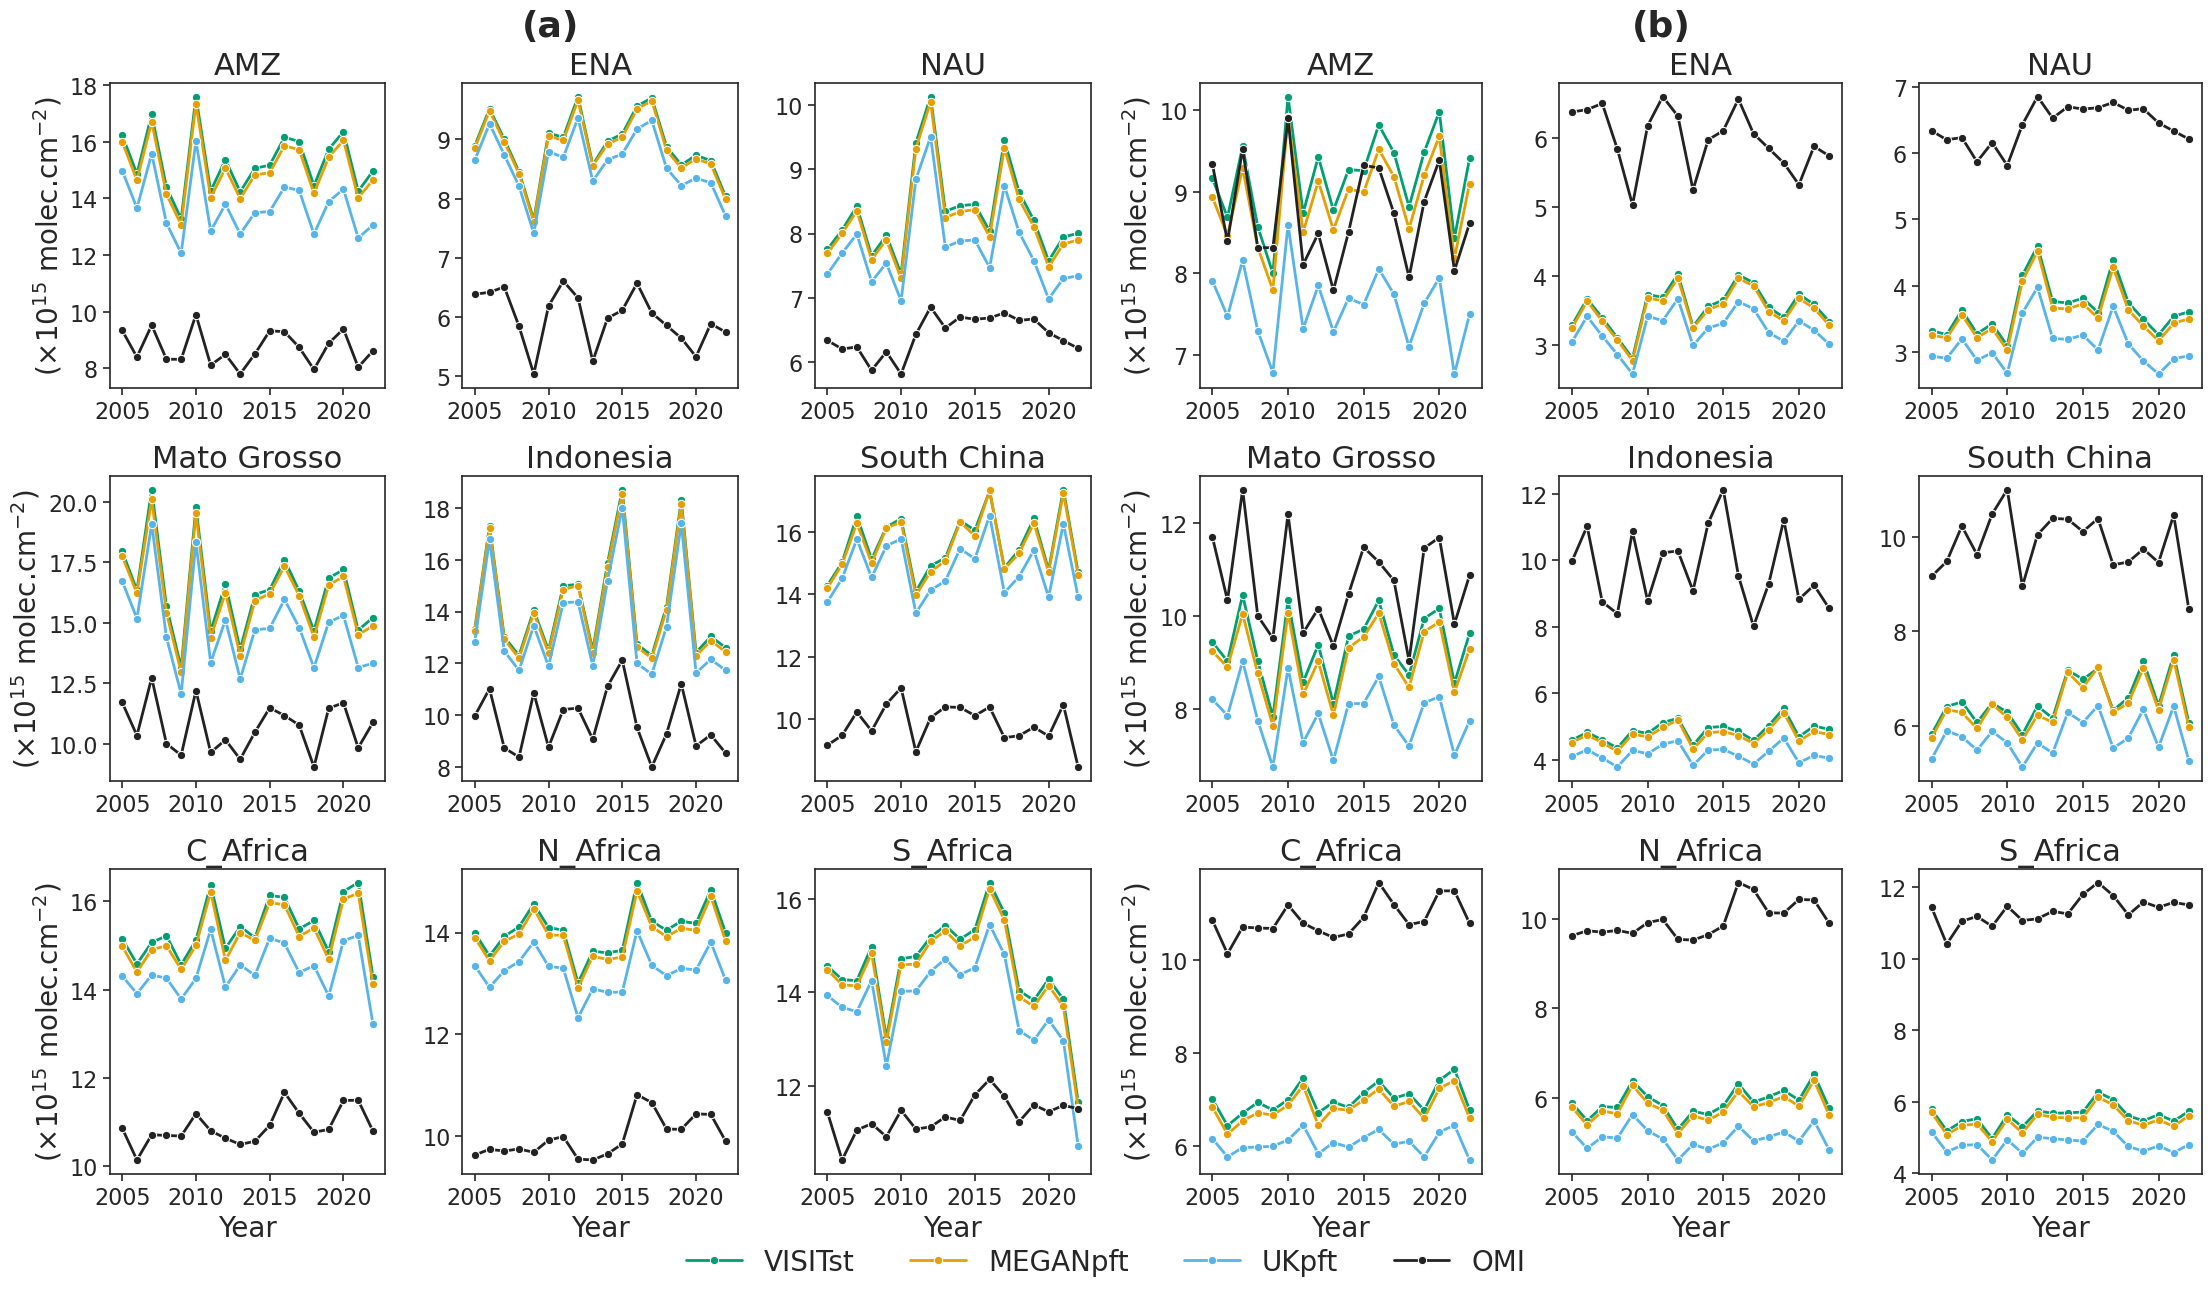

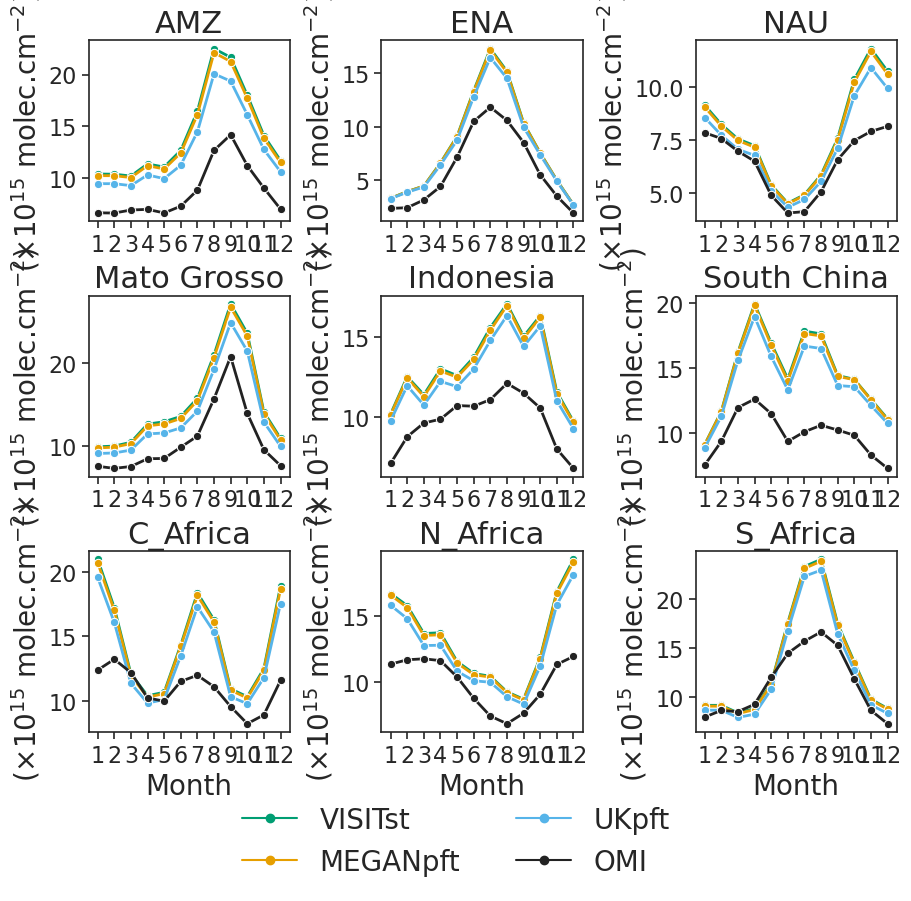

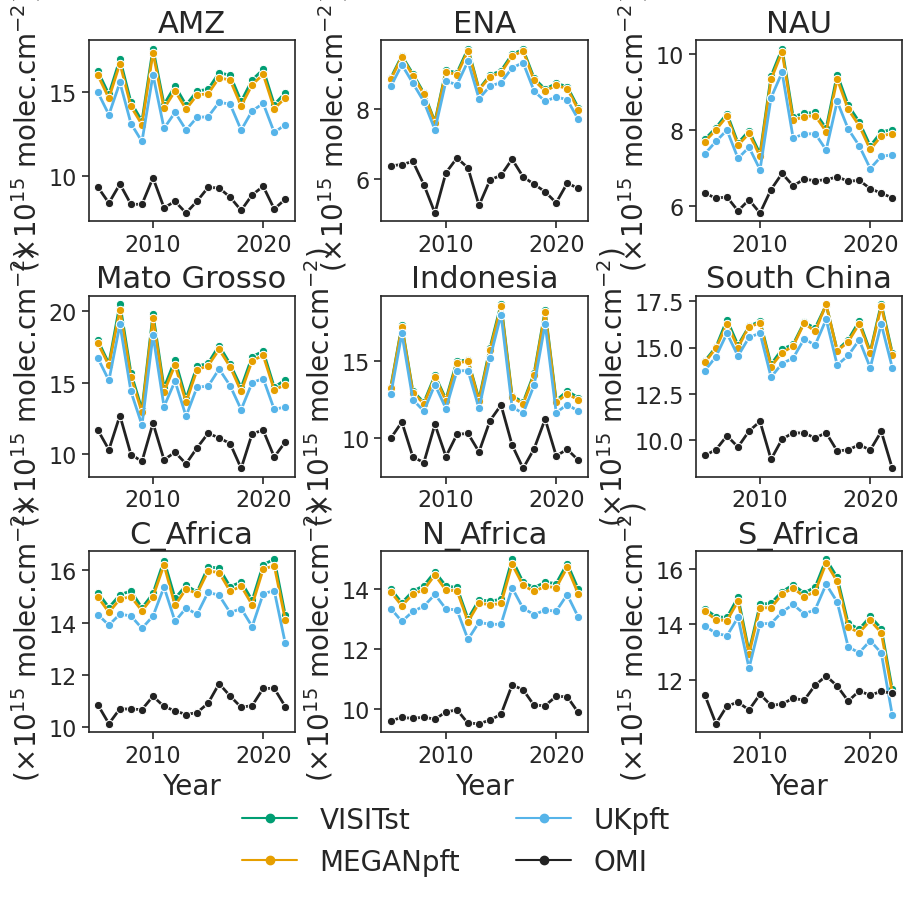

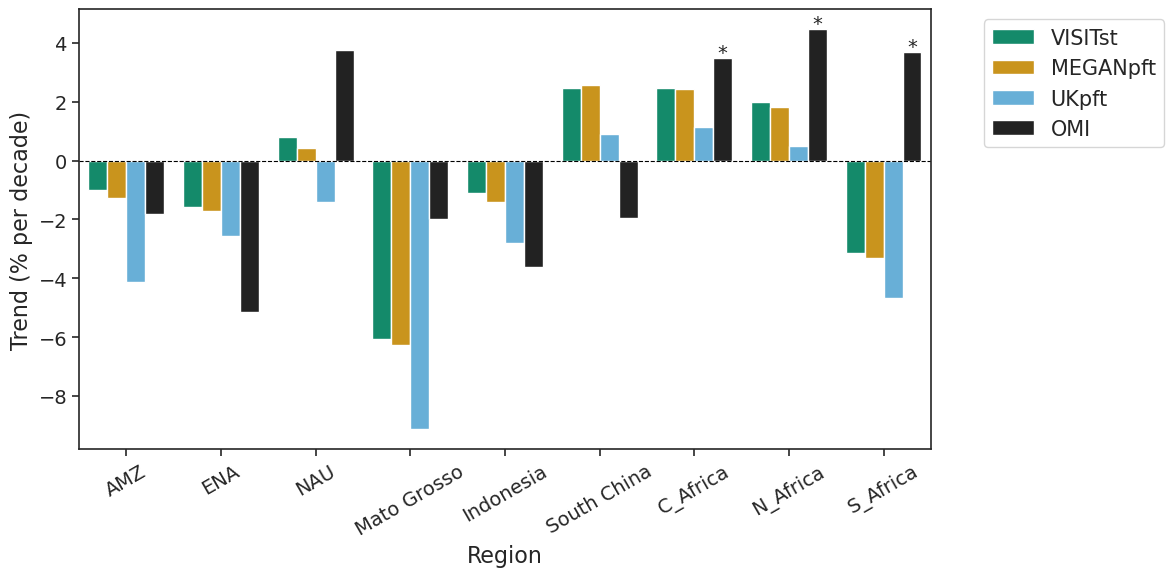

,Region,Model,Decadal trend (% per decade),Significant,Period
0,AMZ,VISITst,-0.999013,0,2005-2022
1,AMZ,MEGANpft,-1.262900,0,2005-2022
2,AMZ,UKpft,-4.129421,0,2005-2022
3,AMZ,OMI,-1.831610,0,2005-2022
4,ENA,VISITst,-1.565679,0,2005-2022
5,ENA,MEGANpft,-1.706248,0,2005-2022
6,ENA,UKpft,-2.576738,0,2005-2022
7,ENA,OMI,-5.157030,0,2005-2022
8,NAU,VISITst,0.804226,0,2005-2022
9,NAU,MEGANpft,0.443240,0,2005-2022


In [14]:
# plt_reg(interp_omi_v2, norm=False, unit=None, sslat=False)
# plt_reg_bvoc_contri(interp_omi_v2, norm=False, unit=None, sslat=False)

FS_INDEX = 26    # panel indices (a) (b)
FS_TITLE = 22    # region names above each panel
FS_LABEL = 20    # axis labels
FS_TICK = 16     # tick labels
FS_LEGEND = 20   # legend text
LEGEND_NCOL = 2  # legend columns for the standalone grids only (lower to 1 if your case names are very long)  # CHANGED [FigHCHO2]: the combined figure uses one row


def plt_reg(hcho, norm=False, unit=None, sslat=False, fig=None, save_path=None):  # CHANGED [FigHCHO]: optional Figure/SubFigure to draw into

    interested_case = list(hcho.keys())
    interested_case = [c for c in interested_case if "BVOCoff" not in c]

    ylim_dict = {
        # "SAF": (0, 15),
        # "MED": (0, 15),
        # "CEU": (0, 15),
        # "SAS": (0, 15),
        "AMZ": (0, 25),
        "ENA": (0, 20),
        "EAS": (0, 20),
        "SEA": (0, 15),
        "NAU": (0, 15),
        "Indonesia": (0, 15),
        "C_Africa": (0, 25),
        "N_Africa": (0, 25),
        "S_Africa": (0, 25),
        "REMOTE_PACIFIC": (0, 4),
    }
    trend_dict = {
        "Region": [],
        "Model": [],
        "Decadal trend (% per decade)": [],
        "Significant": [],
        "Period": [],
    }
    combined = fig is not None  # ADDED [FigHCHO]
    for mode in (["ann"] if combined else ["ss", "ann"]):  # CHANGED [FigHCHO]: combined figure uses the annual grid only
        index = "month" if mode == "ss" else "year"

        if combined:  # ADDED [FigHCHO]
            axis = fig.subplots(3, 3, gridspec_kw={"wspace": 0.05, "hspace": 0.05})  # ADDED [FigHCHO]: draw into the supplied Figure/SubFigure
        else:  # ADDED [FigHCHO]
            fig, axis = plt.subplots(3, 3, figsize=(3 * 3, 3 * 3), layout="constrained")  # CHANGED [FigHCHO]: indented, otherwise unchanged

        for i, r in enumerate(ROIS):
            ri, ci = i // 3, i % 3
            ax = axis[ri, ci]
            for j, c in enumerate(interested_case):
                df = hcho[c].reg_ss
                if mode == "ann":
                    df = hcho[c].reg_ann
                    if sslat:
                        df = hcho[c].reg_ann_sslat
                reg_df = df[[index, r]].set_index(index).rename(columns={r: c})

                periods = (
                    ["2005-2022"]
                    if len(reg_df) >= 10
                    else ["2018-2023"]
                )
                if mode == "ann":
                    for p in periods:
                        start_year, end_year = map(int, p.split("-"))
                        reg_period_df = reg_df.loc[
                            (reg_df.index >= start_year) & (reg_df.index <= end_year)
                        ]
                        # trend = pymk.original_test(reg_period_df[c], alpha=0.05)
                        trend_per_dec, sig = linear_trend_significance(reg_period_df[c])
                        trend_dict["Period"].append(p)
                        trend_dict["Region"].append(r)
                        trend_dict["Model"].append(c)
                        # trend_dict["Trend (%)"].append(
                        #     trend.slope * 100 / reg_period_df[c].mean()
                        # )
                        # trend_dict["Significant"].append(1 if trend.h else 0)
                        trend_dict["Decadal trend (% per decade)"].append(trend_per_dec)
                        trend_dict["Significant"].append(sig)
                if norm:
                    reg_df[c] = min_max_normalize(reg_df[c])
                sns.lineplot(reg_df, ax=ax, palette=[colors[j]], markers=True, lw=2)
            # Set y-axis limit
            # if r in ylim_dict:
            #     ax.set_ylim(ylim_dict[r])

            handles, labels = ax.get_legend_handles_labels()
            ax.get_legend().remove()
            ax.set_xlabel("Year", fontsize=FS_LABEL)  # CHANGED [FigHCHO]: explicit font size
            if mode == "ss":
                ax.set_xlabel("Month", fontsize=FS_LABEL)  # CHANGED [FigHCHO]: explicit font size
                ax.set_xticks(np.arange(1, 13))
            if ri < 2:
                ax.set_xlabel("")

            if unit is None:
                unit = "(\u00d710$^{15}$ molec.cm$^{-2}$)"
            if ci == 0 or not combined:  # CHANGED [FigHCHO]: in the combined figure only the left-most column has a y label
                ax.set_ylabel(unit, fontsize=FS_LABEL)  # CHANGED [FigHCHO]: explicit font size
            else:  # ADDED [FigHCHO]: seaborn sets a y label from the series name; clear it so nothing remains in columns 2 and 3
                ax.set_ylabel("")  # ADDED [FigHCHO]

            ax.set_title(f"{r}", fontsize=FS_TITLE)  # CHANGED [FigHCHO]: explicit font size
            ax.tick_params(labelsize=FS_TICK)  # ADDED [FigHCHO]

        if not combined:  # CHANGED [FigHCHO2]: in the combined figure ONE shared legend is drawn by plt_fig_hcho_combined()
            fig.legend(
                handles,
                labels,
                ncol=LEGEND_NCOL,  # CHANGED [FigHCHO]: 4 -> LEGEND_NCOL (larger legend text needs more rows)
                loc="outside lower center",  # CHANGED [FigHCHO]: was loc="center", bbox_to_anchor=(0.5, -0.06); now reserved inside the layout
                fontsize=FS_LEGEND,  # ADDED [FigHCHO]
                frameon=False,  # ADDED [FigHCHO]
            )

    # plot trend
    trend_df = pd.DataFrame.from_dict(trend_dict)
    if combined:  # ADDED [FigHCHO]: the trend bar charts are separate figures, not part of the combined figure
        return trend_df  # ADDED [FigHCHO]
    for p in trend_df["Period"].unique():
        # Create a new figure for this period
        fig, ax = plt.subplots(figsize=(12, 6))
        df_p = trend_df[trend_df["Period"] == p]

        # Create the bar plot on the new axes

        barplot = sns.barplot(
            data=df_p,
            x="Region",
            y="Decadal trend (% per decade)",
            hue="Model",
            palette=colors,
            ax=ax,
        )

        for patch in barplot.patches:
            h = patch.get_height()
            # Find the matching row where Linear trend (%) per decade equals height and Significant is True
            matching_row = df_p[
                (df_p["Decadal trend (% per decade)"] == h)
                & (df_p["Significant"] == True)
            ]

            if not matching_row.empty:
                add_h = 1.5  # height to add the star above the bar
                h = h if h > 0 else h - add_h
                ax.text(patch.get_x() + patch.get_width() / 2.0, h, "*", ha="center")

        # ax.set_title(f"HCHO decadal trend (% per decade) during({p})")
        ax.axhline(0, color="k", linestyle="--", linewidth=0.8)
        ax.set_ylabel("Trend (% per decade)")
        ax.set_xlabel("Region")
        plt.setp(ax.xaxis.get_ticklabels(), rotation=30)

        # Move legend outside plot
        ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

        # Adjust layout to prevent label cutoff
        plt.tight_layout()
        plt.show()
        if save_path:
            fig.savefig(save_path, dpi=300, bbox_inches="tight")
    return trend_df


# Plot regional contributions of BVOC emissions to HCHO
def plt_reg_bvoc_contri(hcho, norm=False, unit=None, sslat=False, fig=None):  # CHANGED [FigHCHO]: optional Figure/SubFigure to draw into
    colors2 = [
        "#009E73",  # bluish green
        "#009E73",  # bluish green
        "#E69F00",  # orange
        "#56B4E9",  # sky blue
        "#222222",
    ]
    list_regions = [
        "AMZ",
        "ENA",
        "NAU",
        "Mato Grosso",
        "Indonesia",
        "South China",
        "C_Africa",
        "N_Africa",
        "S_Africa",
    ]
    trend_dict = {
        "Region": [],
        "Model": [],
        "Decadal trend (% per decade)": [],
        "Significant": [],
        "Period": [],
    }
    interested_case = list(hcho.keys())

    combined = fig is not None  # ADDED [FigHCHO]
    for mode in (["ann"] if combined else ["ss", "ann"]):  # CHANGED [FigHCHO]: combined figure uses the annual grid only
        index = "month" if mode == "ss" else "year"
        if combined:  # ADDED [FigHCHO]
            axis = fig.subplots(3, 3, gridspec_kw={"wspace": 0.05, "hspace": 0.05})  # ADDED [FigHCHO]: draw into the supplied Figure/SubFigure
        else:  # ADDED [FigHCHO]
            fig, axis = plt.subplots(3, 3, figsize=(9, 9), layout="constrained")  # CHANGED [FigHCHO]: indented, otherwise unchanged

        for i, r in enumerate(list_regions):
            ri, ci = i // 3, i % 3
            ax = axis[ri, ci]

            for j, case in enumerate(interested_case):
                if case == OFF_CASE:
                    continue
                # Select time period
                ds = (
                    hcho[case].reg_ss
                    if mode == "ss"
                    else (hcho[case].reg_ann_sslat if sslat else hcho[case].reg_ann)
                )
                reg_df = ds[[index, r]].set_index(index).rename(columns={r: case})

                # Subtract BVOCoff (if applicable)
                ds_off = (
                    hcho[OFF_CASE].reg_ss
                    if mode == "ss"
                    else (
                        hcho[OFF_CASE].reg_ann_sslat
                        if sslat
                        else hcho[OFF_CASE].reg_ann
                    )
                )
                reg_off = ds_off[[index, r]].set_index(index).rename(columns={r: case})
                if case not in SAT_CASE:
                    reg_df[case] = reg_df[case] - reg_off[case]

                periods = (
                    ["2005-2014", "2013-2022", "2005-2022"]
                    if len(reg_df) >= 10
                    else ["2018-2023"]
                )
                if mode == "ann":
                    for p in periods:
                        start_year, end_year = map(int, p.split("-"))
                        reg_period_df = reg_df.loc[
                            (reg_df.index >= start_year) & (reg_df.index <= end_year)
                        ]
                        # trend = pymk.original_test(reg_period_df[c], alpha=0.05)
                        trend_per_dec, sig = linear_trend_significance(
                            reg_period_df[case]
                        )
                        trend_dict["Period"].append(p)
                        trend_dict["Region"].append(r)
                        trend_dict["Model"].append(case)
                        # trend_dict["Trend (%)"].append(
                        #     trend.slope * 100 / reg_period_df[c].mean()
                        # )
                        # trend_dict["Significant"].append(1 if trend.h else 0)
                        trend_dict["Decadal trend (% per decade)"].append(trend_per_dec)
                        trend_dict["Significant"].append(sig)

                if norm:
                    reg_df[case] = min_max_normalize(reg_df[case])

                sns.lineplot(
                    x=reg_df.index,
                    y=reg_df[case],
                    ax=ax,
                    label=case.replace("20012023_CEDS", ""),
                    color=colors2[j],
                    lw=2,
                    marker="o",
                )

            # Axis settings
            if unit is None:
                unit = "(\u00d710$^{15}$ molec.cm$^{-2}$)"
            if ci == 0 or not combined:  # CHANGED [FigHCHO]: in the combined figure only the left-most column has a y label
                ax.set_ylabel(unit, fontsize=FS_LABEL)  # CHANGED [FigHCHO]: explicit font size
            else:  # ADDED [FigHCHO]: seaborn sets a y label from the series name; clear it so nothing remains in columns 2 and 3
                ax.set_ylabel("")  # ADDED [FigHCHO]
            ax.set_title(f"{r}", fontsize=FS_TITLE)  # CHANGED [FigHCHO]: explicit font size
            ax.tick_params(labelsize=FS_TICK)  # ADDED [FigHCHO]
            ax.get_legend().remove()

            if mode == "ss":
                ax.set_xlabel("Month", fontsize=FS_LABEL)  # CHANGED [FigHCHO]: explicit font size
                ax.set_xticks(np.arange(1, 13))
            else:
                ax.set_xlabel("Year", fontsize=FS_LABEL)  # CHANGED [FigHCHO]: explicit font size

            if ri < 2:
                ax.set_xlabel("")

            # Optional: set y-axis limits if needed
            # if r in ylim_dict:
            #     ax.set_ylim(ylim_dict[r])

        # Global legend
        handles, labels = ax.get_legend_handles_labels()
        if not combined:  # CHANGED [FigHCHO2]: in the combined figure ONE shared legend is drawn by plt_fig_hcho_combined()
            fig.legend(
                handles,
                labels,
                ncol=LEGEND_NCOL,  # CHANGED [FigHCHO]: 4 -> LEGEND_NCOL (larger legend text needs more rows)
                loc="outside lower center",  # CHANGED [FigHCHO]: was loc="center", bbox_to_anchor=(0.5, -0.06); now reserved inside the layout
                borderaxespad=0,  # ADDED [FigHCHO]: spacing between the legend and the axes
                fontsize=FS_LEGEND,  # ADDED [FigHCHO]
                frameon=False,  # ADDED [FigHCHO]
            )
    # plot trend
    trend_df = pd.DataFrame.from_dict(trend_dict)
    if combined:  # ADDED [FigHCHO]: the trend bar charts are separate figures, not part of the combined figure
        return trend_df  # ADDED [FigHCHO]
    for p in trend_df["Period"].unique():
        # Create a new figure for this period
        fig, ax = plt.subplots(figsize=(12, 6))
        df_p = trend_df[trend_df["Period"] == p]

        # Create the bar plot on the new axes

        barplot = sns.barplot(
            data=df_p,
            x="Region",
            y="Decadal trend (% per decade)",
            hue="Model",
            palette=colors,
            ax=ax,
        )

        for patch in barplot.patches:
            h = patch.get_height()
            # Find the matching row where Linear trend (%) per decade equals height and Significant is True
            matching_row = df_p[
                (df_p["Decadal trend (% per decade)"] == h)
                & (df_p["Significant"] == True)
            ]

            if not matching_row.empty:
                add_h = 1.5  # height to add the star above the bar
                h = h if h > 0 else h - add_h
                ax.text(patch.get_x() + patch.get_width() / 2.0, h, "*", ha="center")

        ax.set_title(
            f"HCHO (BVOC contribution) decadal trend (% per decade) during({p})"
        )
        ax.axhline(0, color="k", linestyle="--", linewidth=0.8)
        ax.set_ylabel("Trend (% per decade)")
        ax.set_xlabel("Region")
        plt.setp(ax.xaxis.get_ticklabels(), rotation=30)

        # Move legend outside plot
        ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

        # Adjust layout to prevent label cutoff
        plt.tight_layout()
        plt.show()
    return trend_df


# ADDED [FigHCHO]: builds the combined figure  (a) total HCHO | (b) BVOC contribution, side by side
def plt_fig_hcho_combined(hcho, norm=False, unit=None, sslat=False, save_path=None):
    # Temporarily raise the default font size for anything not set explicitly
    with plt.rc_context({"font.size": FS_TICK}):
        fig = plt.figure(figsize=(22, 13), layout="constrained")
        sf_a, sf_b = fig.subfigures(1, 2)

        # (a) regional HCHO, annual series
        plt_reg(hcho, norm=norm, unit=unit, sslat=sslat, fig=sf_a)
        sf_a.suptitle("(a)", fontsize=FS_INDEX, fontweight="bold")

        # (b) BVOC contribution to regional HCHO, annual series
        plt_reg_bvoc_contri(hcho, norm=norm, unit=unit, sslat=sslat, fig=sf_b)
        sf_b.suptitle("(b)", fontsize=FS_INDEX, fontweight="bold")

        # ADDED [FigHCHO2]: ONE shared legend, centred below both panels, in a single row.
        # The entries are the same in (a) and (b), so they are read from the last axes of (b).
        handles, labels = sf_b.axes[-1].get_legend_handles_labels()  # ADDED [FigHCHO2]
        fig.legend(  # ADDED [FigHCHO2]
            handles,
            labels,
            loc="outside lower center",
            ncol=len(labels),  # one row, however many entries there are
            fontsize=FS_LEGEND,
            frameon=False,
        )

        if save_path:
            fig.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.show()
plt_fig_hcho_combined(interp_omi_v2, norm=False, unit=None, sslat=False, save_path="./plots/Figure8.png")
plt_reg(interp_omi_v2, norm=False, unit=None, sslat=False, save_path="./plots/Figure9.png")

Figure 10. Global distribution of decadal HCHO trends (% per decade) for 2005–2022. The top row shows observed trends (OMI) and the baseline VISITst simulation without CO2 inhibition effects. The middle row shows simulated trends using MEGANpft and UKpft CO2-inhibition functions, with colors representing deviations from the VISITst trends. The bottom row highlights regions in which MEGANpft and UKpft improve or worsen the agreement with OMI relative to VISITst.

[ 1.  2. nan]
[ 1.  2. nan]


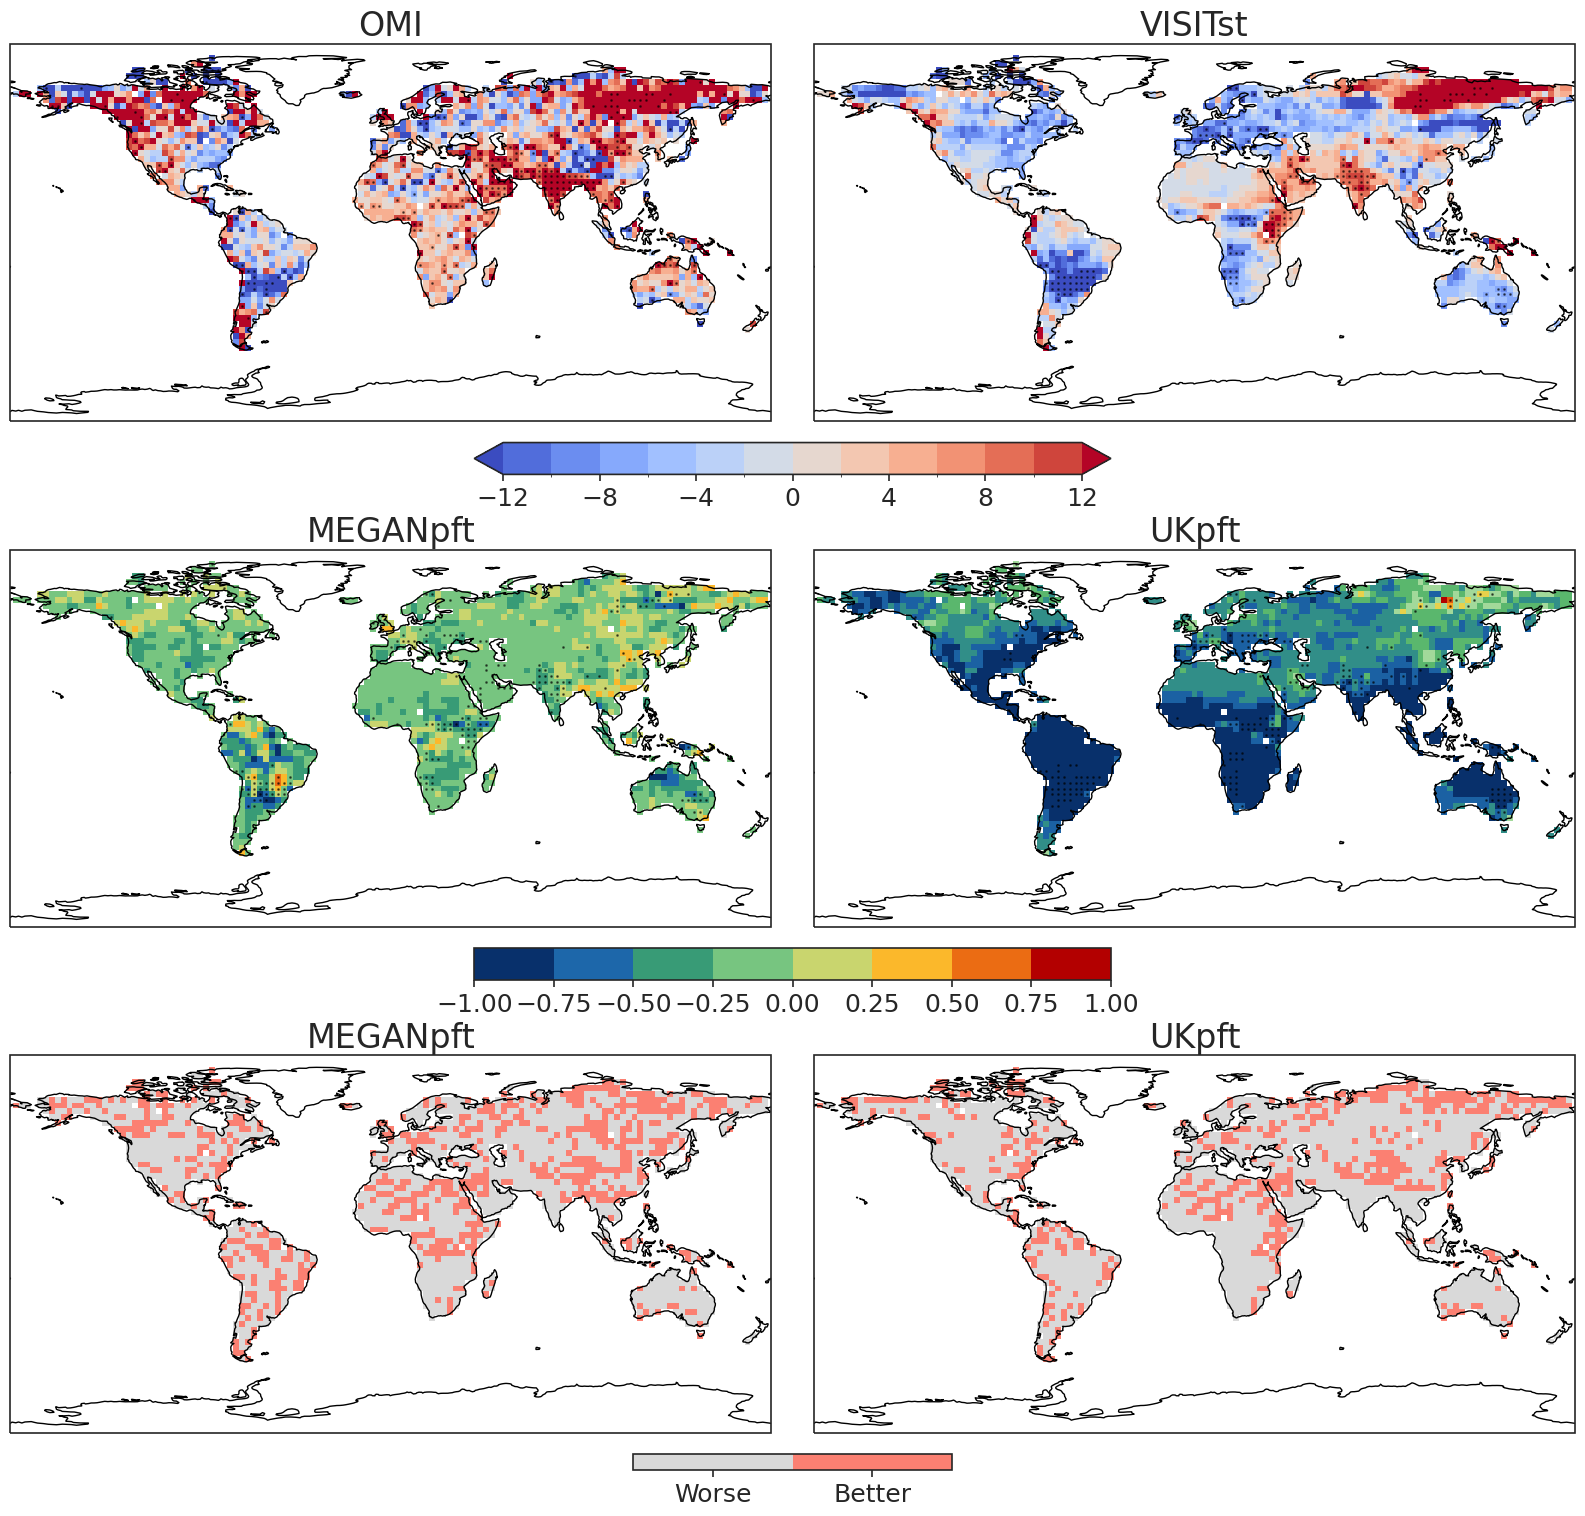

In [16]:

def plt_trend(method="linear", save_path=None):
    # years = ["2005_2014", "2005_2022", "2013_2022", "2018_2023"]
    import matplotlib.colors as mcolors
    from matplotlib.colors import ListedColormap

    colors = [
        "#08306b",  # dark blue
        "#2171b5",  # medium blue
        "#41ab5d",  # green
        "#a1d99b",  # light green/yellow
        "#fecf33",  # yellow
        "#f57f17",  # orange
        "#b30000",  # strong red
    ]

    cmap_diff = mcolors.LinearSegmentedColormap.from_list("trend_diff_modC", colors)
    years = ["2005_2022"]
    dir_name = "hcho_linear_slope"
    band = "emiisop_slope_percentage"
    if method == "mk":
        dir_name = "hcho_mk"
        band = "tcolhcho_ann_trend_percentage"
    for year in years:

        mk_files = glob.glob(f"./plt_data/{dir_name}/*{year}.nc")
        mk_files = [f for f in mk_files if "BVOCoff" not in f]

        interested_case = []
        for f in mk_files:
            if "CEDS" in f:
                interested_case.append(f.split("/")[-1].split("20052023_CEDS")[0])
            elif "BIRA" in f:
                interested_case.append("OMI")
            else:
                interested_case.append("TROPOMI")
        fig, axis = plt.subplots(
            3,
            2,
            figsize=(8 * 2, 5 * 3),
            layout="constrained",
            subplot_kw=dict(projection=ccrs.PlateCarree()),
        )
        cbs = []
        f_sat = None
        f_visit = None
        f_megan = None
        f_uk = None
        for f in mk_files:
            if "OMI" in f:
                f_sat = f
            if "VISITst" in f:
                f_visit = f
            if "MEGANpft" in f:
                f_megan = f
            if "UKpft" in f:
                f_uk = f

        ds_sat = xr.open_dataset(f_sat)
        ds_visit = xr.open_dataset(f_visit)
        ds_megan = xr.open_dataset(f_megan)
        ds_uk = xr.open_dataset(f_uk)

        trend_ds_sat = ds_sat[band] * 10  # convert to % per decade
        trend_ds_visit = ds_visit[band] * 10  # convert to % per decade
        trend_ds_megan = ds_megan[band] * 10  # convert to % per decade
        trend_ds_uk = ds_uk[band] * 10  # convert to % per decade

        visit_sat_diff = trend_ds_visit - trend_ds_sat
        megan_sat_diff = trend_ds_megan - trend_ds_sat
        uk_sat_diff = trend_ds_uk - trend_ds_sat

        megan_better = abs(megan_sat_diff) < abs(visit_sat_diff)
        uk_better = abs(uk_sat_diff) < abs(visit_sat_diff)

        megan_worse = abs(megan_sat_diff) > abs(visit_sat_diff)
        uk_worse = abs(uk_sat_diff) > abs(visit_sat_diff)

        megan_diff = megan_worse + megan_better * 2
        megan_diff = megan_diff.where(megan_diff != 0)
        uk_diff = uk_worse + uk_better * 2
        uk_diff = uk_diff.where(uk_diff != 0)

        for j, f in enumerate(mk_files):
            c = interested_case[j]
            if "BVOCoff" not in c:

                ds = xr.open_dataset(f)
                trend_ds = ds[band] * 10  # convert to % per decade
                # if "VISITst" in c:
                #     trend_ds = trend_ds - trend_ds_sat

                if "OMI" not in c and "VISITst" not in c:
                    trend_ds = trend_ds - trend_ds_visit

                sig_mask = None
                if "emiisop_pval" in ds:
                    pval = ds["emiisop_pval"]
                    sig_mask = pval < 0.05

                ri, ci = j // 2, j % 2
                ax = axis[ri, ci]

                cb = trend_ds.plot(
                    ax=ax,
                    transform=ccrs.PlateCarree(),
                    cmap="coolwarm" if ri == 0 else cmap_diff,
                    vmin=-12 if ri == 0 else -1,
                    vmax=12 if ri == 0 else 1,
                    levels=13 if ri == 0 else 9,
                    add_colorbar=False,
                )
                cbs.append(cb)

                # Add dots for significant pixels
                if sig_mask is not None:
                    lats = trend_ds["lat"].values
                    lons = trend_ds["lon"].values
                    yy, xx = np.meshgrid(lats, lons, indexing="ij")

                    ax.scatter(
                        xx[sig_mask],
                        yy[sig_mask],
                        color="k",
                        s=1,
                        transform=ccrs.PlateCarree(),
                        alpha=0.5,
                        zorder=3,
                    )
                # Colorbar
                ax.coastlines()
                ax.set_title(c, fontsize=24)
        diff_titles = ["MEGANpft", "UKpft"]
        for d, ds_diff in enumerate([megan_diff, uk_diff]):
            cmap_better = ListedColormap(["#d9d9d9", "#fb8072"])
            # cmap_better.set_bad("white")
            ax = axis[2, d]
            print(np.unique(ds_diff.values))
            cb_diff = ds_diff.plot(
                ax=ax,
                transform=ccrs.PlateCarree(),
                cmap=cmap_better,
                add_colorbar=False,
            )
            ax.set_title(diff_titles[d], fontsize=24)
            ax.coastlines()
        cbar = fig.colorbar(
            cb_diff, ax=axis[2, :], orientation="horizontal", shrink=0.2
        )

        bounds = [1, 1.5, 2]
        norm = mcolors.BoundaryNorm(bounds, cmap_better.N)
        cbar.set_ticks([1.25, 1.75])
        cbar.set_ticklabels(["Worse", "Better"])
        # cbar.set_label(
        #     "c) Regions where MEGANpft/UKpft improve over VISITst", fontsize=20
        # )
        cbar.ax.tick_params(labelsize=18)

        labels = [
            f"a) Decadal trend during {year} (% per decade)",
            f"b) Difference compared to VISITst during {year} (% per decade)",
        ]
        cbsl = [cbs[0], cbs[2]]

        for l in range(len(cbsl)):
            label = labels[l]
            cbar = fig.colorbar(
                cbsl[l],
                ax=axis[l, :],
                orientation="horizontal",
                label="",
                shrink=0.4,
            )
            # cbar.set_label(label, fontsize=20)
            cbar.ax.tick_params(labelsize=18)

        axes = axis.ravel() if hasattr(axis, "ravel") else [axis]

        for ax in axes:
            if not ax.has_data():  # Checks if anything was plotted
                ax.set_visible(False)
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
plt_trend(method="linear", save_path="./plots/Figure10.png")

Figure 11. Time series of global annual isoprene emissions (TgC yr⁻¹) during 1901–2023 simulated by VISIT under different isoprene emission schemes, including simulations with CO2 inhibition (VISIT-wCO2inhi-MEGANst, -UKst, -MIXpft, -MEGANpft, and -UKpft) and without CO2 inhibition (VISIT-woCO2inhi, solid red line).

VISIT-wCO2inhi-MEGANpft Mann_Kendall_Test(trend='increasing', h=True, p=0.0, z=12.50877481134138, Tau=0.76276156204185, s=5723.0, var_s=209250.33333333334, slope=0.6594878889070874, intercept=394.01271740599844)
VISIT-wCO2inhi-MEGANst Mann_Kendall_Test(trend='increasing', h=True, p=0.0, z=12.862920480589425, Tau=0.7843529254964681, s=5885.0, var_s=209250.33333333334, slope=0.727758496298775, intercept=397.69302729065623)
VISIT-wCO2inhi-MIXpft Mann_Kendall_Test(trend='increasing', h=True, p=0.0, z=11.717412266478469, Tau=0.7145141943222711, s=5361.0, var_s=209250.33333333334, slope=0.5466166459209352, intercept=401.57023183467584)
VISIT-wCO2inhi-UKpft Mann_Kendall_Test(trend='decreasing', h=True, p=0.0, z=-13.588700494110105, Tau=-0.8286018925763028, s=-6217.0, var_s=209250.33333333334, slope=-0.522148287739396, intercept=472.1979384050617)
VISIT-wCO2inhi-UKst Mann_Kendall_Test(trend='decreasing', h=True, p=0.0, z=-13.61056133789085, Tau=-0.8299346927895509, s=-6227.0, var_s=209250.3333

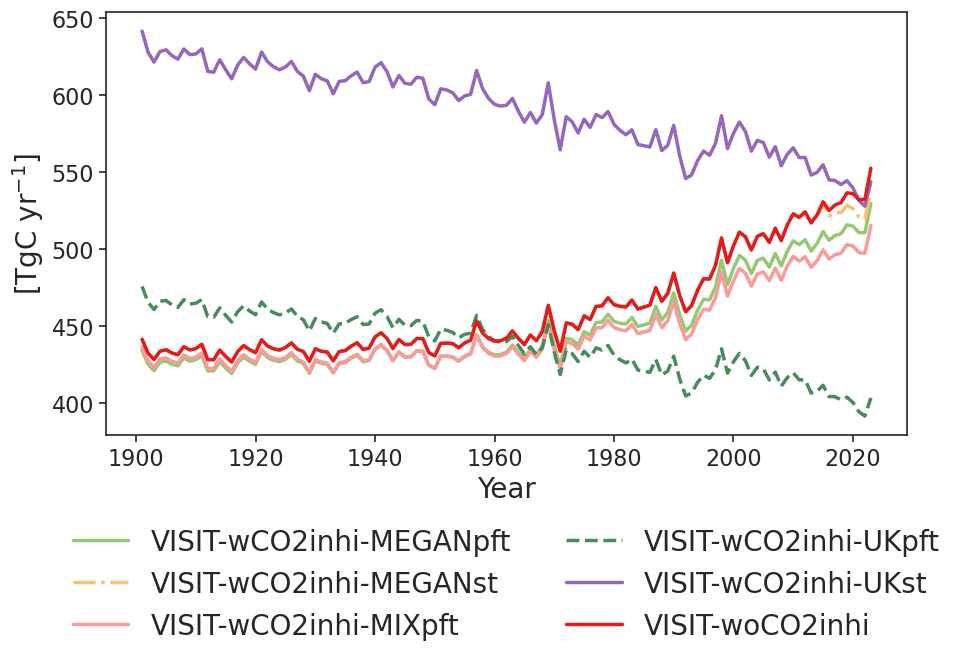

In [18]:
def plt_glob_annual_variation(emiisop, ax=None, save_path=None):  # CHANGED [Fig3]: optional ax to draw into
    model_names = list(emiisop.multi_models.keys())
    colors = [
        "#94C973",
        "#fdbf6f",
        "#fb9a99",
        "#478C5C",
        "#9467BD",
        "#e41a1c",
    ]
    colors_dict = {
        m_name: c for m_name, c in zip(model_names, colors[: len(model_names)])
    }
    lss = ["-", "-.", "-", "--", "-", "-"]
    ls_dict = {m_name: c for m_name, c in zip(model_names, lss[: len(model_names)])}
    if ax is None:  # ADDED [Fig3]: standalone use keeps the original figure
        fig, ax = plt.subplots(figsize=(9.5, 6.5), layout="constrained")
    # REMOVED [Fig3]: fig, ax = plt.subplots(figsize=(9.5, 6.5), layout="constrained")
    # REMOVED [Fig3]: axbox = ax.get_position()   (legend is now anchored to the axes, see below)
    for m_name in model_names:
        cmip6_obj = emiisop.multi_models[m_name]
        x, y = cmip6_obj.global_rate["year"], cmip6_obj.global_rate
        ax.plot(
            x,
            y,
            label=m_name,
            linewidth=2.5,
            color=colors_dict[m_name],
            ls=ls_dict[m_name],
        )
        res = pymk.original_test(y, alpha=0.05)
        print(m_name, res)
 
    ax.set_xlabel("Year", fontsize=FS_LABEL)  # CHANGED [Fig3]: explicit font size
    ax.set_ylabel(VIZ_OPT[emiisop.var_name]["line_bar_unit"], fontsize=FS_LABEL)  # CHANGED [Fig3]: 14 -> FS_LABEL
    ax.tick_params(labelsize=FS_TICK)  # ADDED [Fig3]
    ax.legend(
        loc="upper center",  # CHANGED [Fig3]: was loc="center" in figure coordinates
        ncol=2,  # CHANGED [Fig3]: 3 -> 2 columns, the larger legend text needs the room
        bbox_to_anchor=(0.5, -0.16),  # CHANGED [Fig3]: anchored below THIS axes, so it works inside a multi-panel figure
        fontsize=FS_LEGEND,  # ADDED [Fig3]
        frameon=False,  # ADDED [Fig3]
    )
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt_glob_annual_variation(emiisop_co2Inhi_1k9, save_path="./plots/Figure11.png")

Supplemental Figures

Figure S2. Global distribution of annually averaged HCHO column from OMI observations and difference from CHASER simulations for 2005–2022.

['OMI', 'VISITst', 'MEGANpft', 'UKpft']


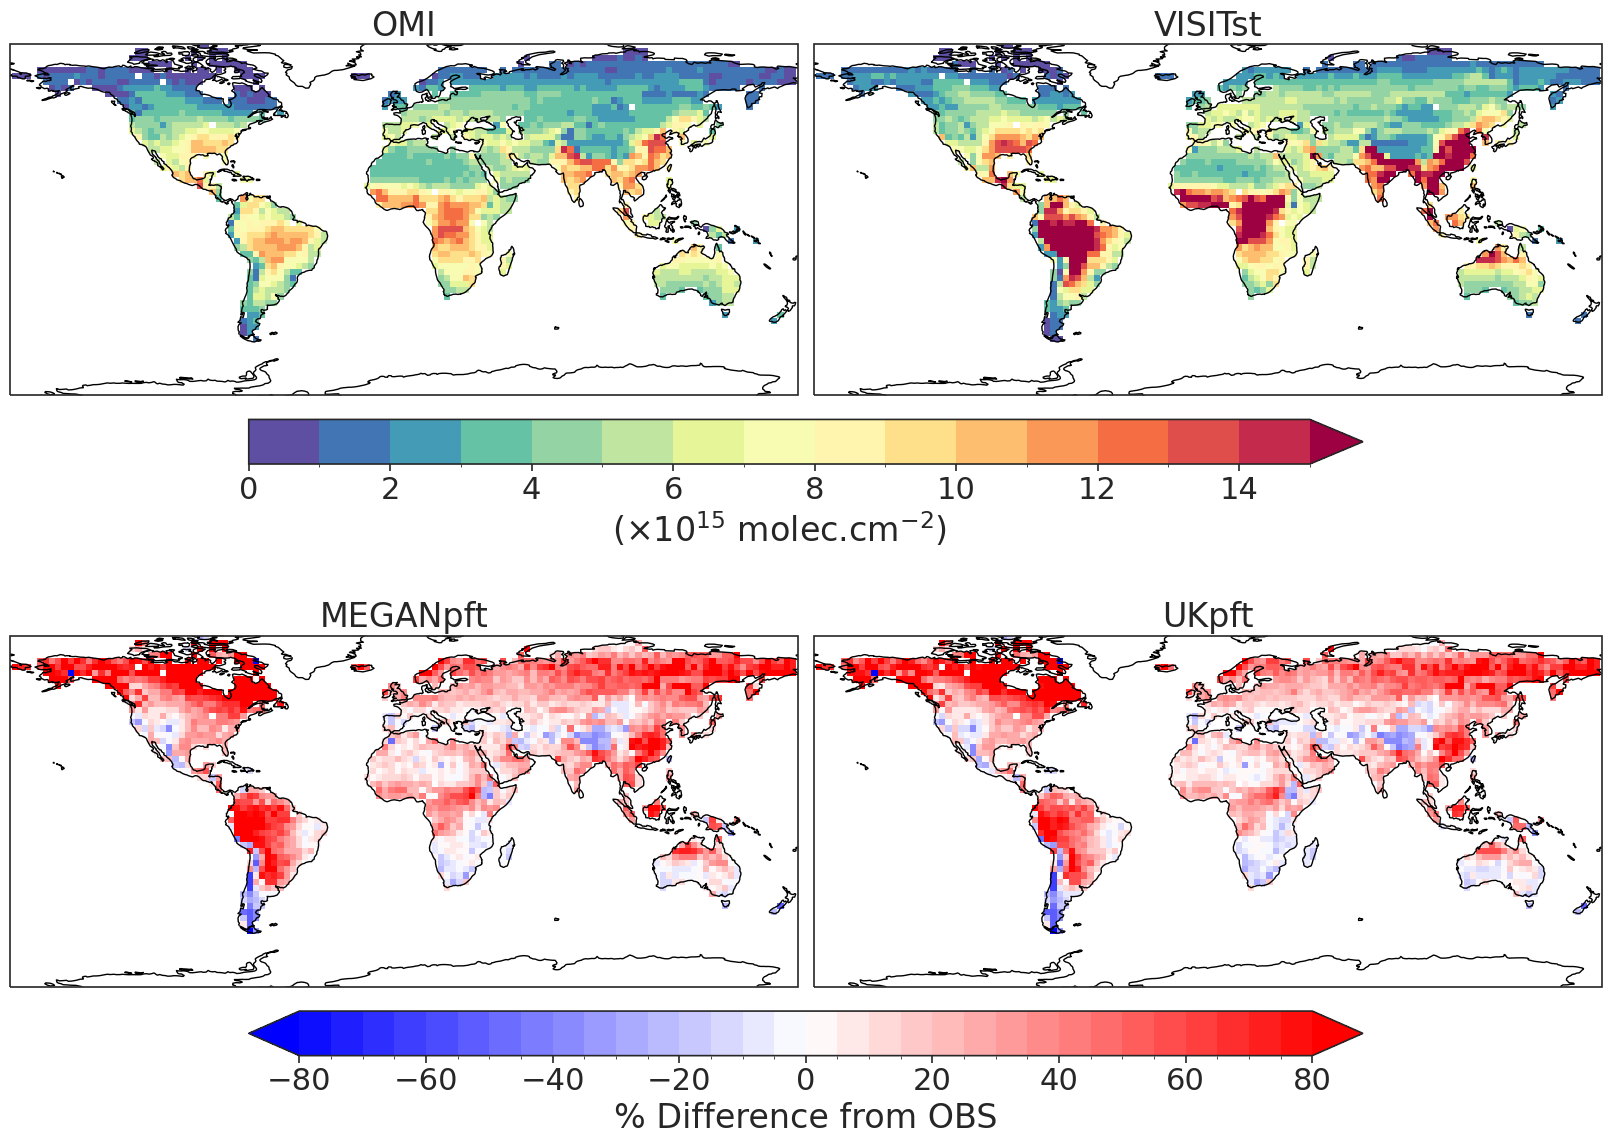

In [ ]:
FS_TITLE = 24        # panel titles
FS_CBAR_LABEL = 24   # colour-bar labels
FS_CBAR_TICK = 22    # colour-bar tick labels
CBAR_SHRINK = 0.7    # colour-bar LENGTH as a fraction of the width of the maps above it (original: 0.5 of the figure width)
CBAR_ASPECT = 25     # length / thickness of the colour bar; smaller = thicker (original thickness: 0.01 of the figure height)
FIG_H_PER_ROW = 5.8  # figure height per map row in inches (original: 5); larger fonts and bars need a little more room


def plt_mean_ann(hcho, sslat=False):

    cases = list(hcho.keys())
    obs_c = get_sat_case(cases)
    cases.insert(0, cases.pop())

    rows, cols = len(cases) // 2, 2
    
    fig = plt.figure(figsize=(8 * rows, FIG_H_PER_ROW * cols), layout="constrained")  # CHANGED [FigMean]: height 5 -> FIG_H_PER_ROW per row
    sf_top, sf_rest = fig.subfigures(2, 1, height_ratios=[1, rows - 1])
    map_kw = dict(projection=ccrs.PlateCarree())
    ax_top = sf_top.subplots(1, cols, subplot_kw=map_kw, squeeze=False)
    ax_rest = sf_rest.subplots(rows - 1, cols, subplot_kw=map_kw, squeeze=False)
    axis = np.vstack([ax_top, ax_rest])  # same axis[ri, ci] indexing as before
    unit = "(\u00d710$^{15}$ molec.cm$^{-2}$)"

    # cases.remove(obs_c)
    cases.remove(OFF_CASE)
    # cases.insert(0, obs_c)
    # cases.insert(2, "VISITst20012023_nudg")

    print(cases)

    mappable_group1 = None  # for j < 2
    mappable_group2 = None  # for j > 1

    obs_ds = hcho[obs_c].hcho.mean("time", skipna=True)
    if sslat:
        obs_ds = hcho[obs_c].hcho_sslat.mean("year", skipna=True)

    for j, c in enumerate(cases):

        ds = hcho[c].hcho.mean("time", skipna=True)
        if sslat:
            ds = hcho[c].hcho_sslat.mean("year", skipna=True)

        if j > 1:
            ds = (ds - obs_ds) * 100 / obs_ds

        ri, ci = j // cols, j % cols

        ax = axis[ri, ci]

        im = ds.plot(
            ax=ax,
            cmap="Spectral_r" if j < 2 else "bwr",
            add_colorbar=False,
            levels=16 if j < 2 else np.arange(-80, 81, 5),
            extend="max" if j < 2 else "both",
            vmin=0 if j < 2 else -80,
            vmax=15 if j < 2 else 80,
        )
        if j < 2 and mappable_group1 is None:
            mappable_group1 = im
        if j > 1 and mappable_group2 is None:
            mappable_group2 = im

        replace_str = "" if j < 2 else " (OBS subtracted)"
        tit = c.replace("20012023_nudg", replace_str)
        ax.set_title(tit, fontsize=FS_TITLE)  # CHANGED [FigMean]: 18 -> FS_TITLE
        ax.coastlines()
        ax.set_extent([-179.5, 179.5, -80, 80], crs=ccrs.PlateCarree())
        
    cbar1 = sf_top.colorbar(  # ADDED [FigMean]: colour bar under the first row, managed by the layout
        mappable_group1,
        ax=axis[0, :],
        orientation="horizontal",
        shrink=CBAR_SHRINK,  # ADDED [FigMean]: wider bar
        aspect=CBAR_ASPECT,  # ADDED [FigMean]: thicker bar
        pad=0.05,  # ADDED [FigMean]
    )
    cbar1.set_label(unit, fontsize=FS_CBAR_LABEL)  # CHANGED [FigMean]: 16 -> FS_CBAR_LABEL
    cbar1.ax.tick_params(labelsize=FS_CBAR_TICK)  # CHANGED [FigMean]: 14 -> FS_CBAR_TICK

    cbar2 = sf_rest.colorbar(  # ADDED [FigMean]: colour bar under the remaining rows (anomaly maps)
        mappable_group2,
        ax=axis[1:, :].ravel(),
        orientation="horizontal",
        shrink=CBAR_SHRINK,  # ADDED [FigMean]
        aspect=CBAR_ASPECT,  # ADDED [FigMean]
        pad=0.05,  # ADDED [FigMean]
    )
    cbar2.set_label("% Difference from OBS", fontsize=FS_CBAR_LABEL)  # CHANGED [FigMean]: 16 -> FS_CBAR_LABEL
    cbar2.ax.tick_params(labelsize=FS_CBAR_TICK)  # CHANGED [FigMean]: 14 -> FS_CBAR_TICK

plt_mean_ann(interp_omi_v2, sslat=False)

In [ ]:
Figure S3. Pearson correlation coefficients between annually averaged HCHO columns from OMI observations and CHASER simulations for 2005–2022.

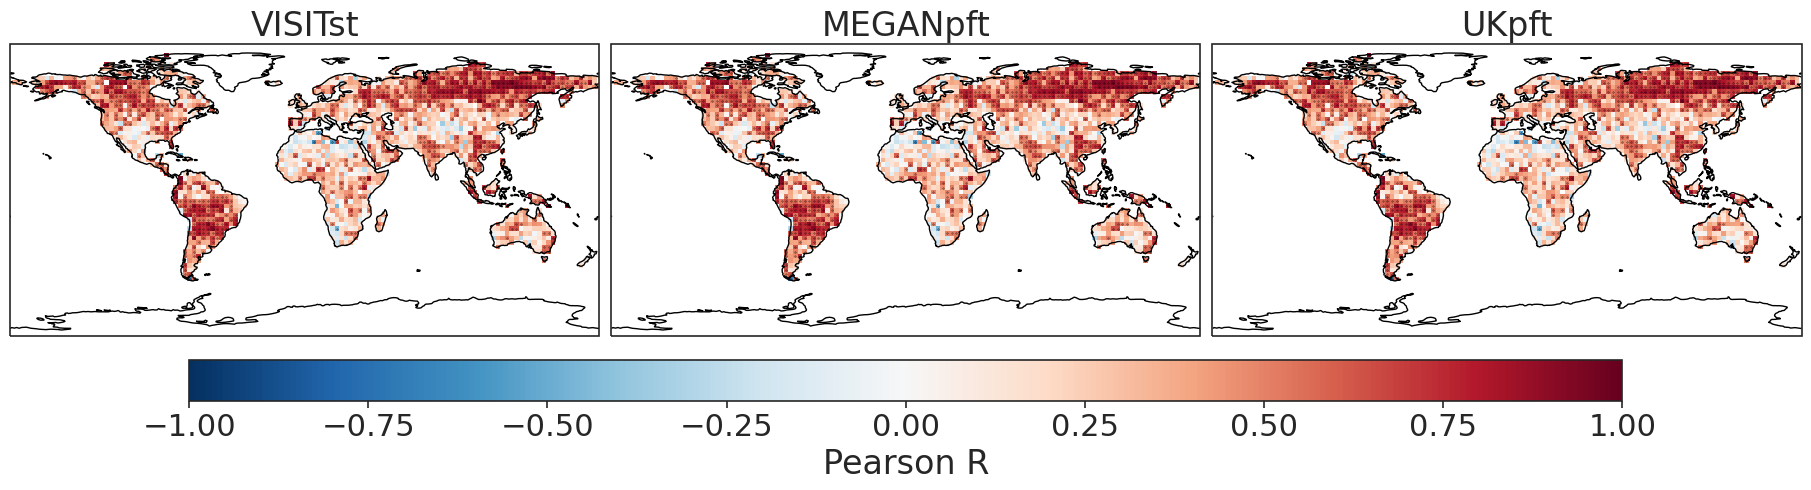

In [ ]:
FS_TITLE = 24        # panel titles
FS_CBAR_LABEL = 24   # colour-bar label
FS_CBAR_TICK = 22    # colour-bar tick labels
CBAR_SHRINK = 0.8    # colour-bar LENGTH as a fraction of the width of the three maps (original: 0.6 of the figure width)
CBAR_ASPECT = 35     # length / thickness of the colour bar; smaller = thicker (original thickness: 0.01 of the figure height)
FIG_H = 5.6          # figure height in inches (original: 4.5); larger fonts and the thicker bar need a little more room


def plt_map(hcho_dict, score="corr", sslat=False):
    fig, axis = plt.subplots(
        1,
        3,
        figsize=(6 * 3, FIG_H),  # CHANGED [FigMap]: height 4.5 * 1 -> FIG_H
        layout="constrained",
        subplot_kw=dict(projection=ccrs.PlateCarree()),
    )

    interested_case = list(hcho_dict.keys())
    obs_c = get_sat_case(interested_case)
    interested_case = [c for c in interested_case if c not in [obs_c, "BVOCoff"]]
    obs_ds = hcho_dict[obs_c].hcho
    obs_ds = obs_ds.groupby(obs_ds.time.dt.year).mean("time")

    if sslat:
        obs_ds = hcho_dict[obs_c].hcho_sslat

    for j, c in enumerate(interested_case):
        if c not in [obs_c, "BVOCoff"]:
            ri, ci = j // 2, j % 2
            # ax = axis[ri, ci]
            ax = axis[j]
            add_colorbar = False

            model_ds = hcho_dict[c].hcho
            model_ds = model_ds.groupby(model_ds.time.dt.year).mean("time")
            if sslat:
                model_ds = hcho_dict[c].hcho_sslat

            if score == "corr":
                corr, sig = map_corr_by_time(model_ds, obs_ds)

                cb = corr.plot(
                    ax=ax,
                    transform=ccrs.PlateCarree(),
                    cmap="RdBu_r",
                    vmin=-1,
                    vmax=1,
                    add_colorbar=add_colorbar,
                )

                # Stippling
                lat, lon = np.meshgrid(corr["lat"], corr["lon"], indexing="ij")
                ax.plot(
                    lon[sig.values],
                    lat[sig.values],
                    "k.",
                    markersize=0.5,
                    transform=ccrs.PlateCarree(),
                )

            elif score == "rmse":
                rmse = compute_rmse(model_ds, obs_ds)

                cb = rmse.plot(
                    ax=ax,
                    transform=ccrs.PlateCarree(),
                    cmap="rainbow",
                    vmin=0,
                    vmax=100,
                    add_colorbar=add_colorbar,
                )

            # Colorbar
            ax.coastlines()
            ax.set_title(c.replace("20012023_nudg", ""), fontsize=FS_TITLE)  # CHANGED [FigMap]: 18 -> FS_TITLE
    # Add a single shared colorbar at bottom center
    label = "Pearson R" if score == "corr" else "Normalized RMSE (%)"
    # REMOVED [FigMap]: cbar_ax = fig.add_axes([0.2, 0.03, 0.6, 0.01])  # [left, bottom, width, height]
    # REMOVED [FigMap]: cbar = fig.colorbar(cb, cax=cbar_ax, orientation="horizontal", label=label)
    # (a manually placed axes is not managed by the layout, so the larger fonts would run into the maps)
    cbar = fig.colorbar(  # ADDED [FigMap]: shared colour bar below the three maps, managed by the layout
        cb,
        ax=axis,
        orientation="horizontal",
        shrink=CBAR_SHRINK,  # ADDED [FigMap]: wider bar
        aspect=CBAR_ASPECT,  # ADDED [FigMap]: thicker bar
        pad=0.05,  # ADDED [FigMap]
        label=label,
    )
    cbar.set_label(label, fontsize=FS_CBAR_LABEL)  # CHANGED [FigMap]: 16 -> FS_CBAR_LABEL
    cbar.ax.tick_params(labelsize=FS_CBAR_TICK)  # CHANGED [FigMap]: 14 -> FS_CBAR_TICK

plt_map(interp_omi_v2, score="corr", sslat=False)

In [ ]:
Figure S4. Normalized Root Mean Square Error (Normalized RMSE in %) between annually averaged HCHO columns from OMI observations and CHASER simulations for 2005–2022.

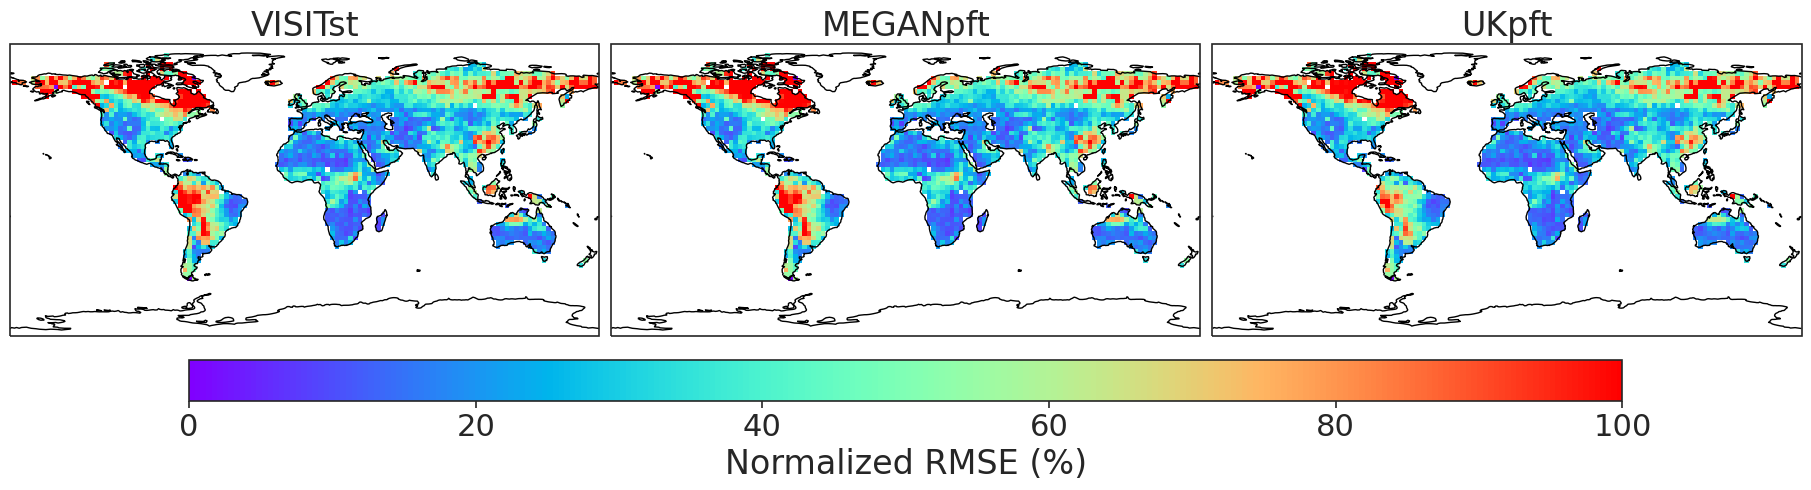

In [ ]:
plt_map(interp_omi_v2, score="rmse", sslat=False)

In [ ]:
Figure S5. Global distribution of annually averaged HCHO column from TROPOMI observations and difference from CHASER simulations for 2018–2023.

['TROPOMI', 'VISITst', 'MEGANpft', 'UKpft']


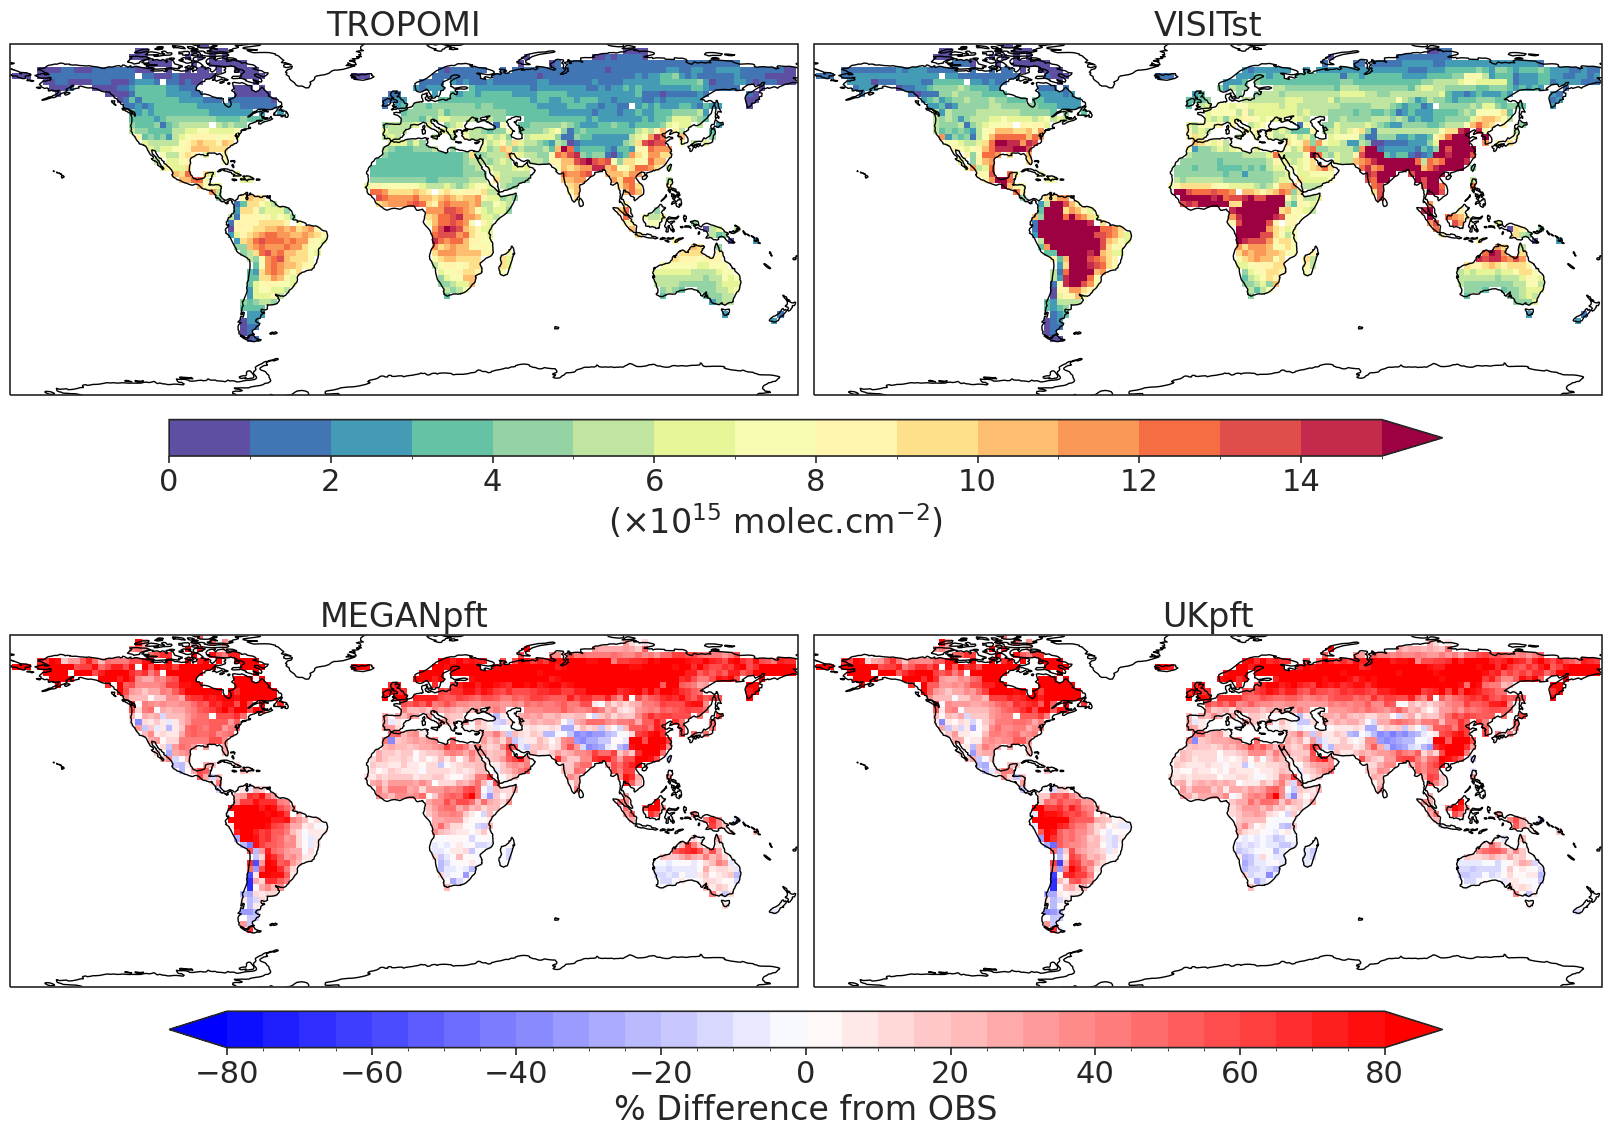

In [ ]:
plt_mean_ann(interp_tropo_v2, sslat=False)

Figure S6. Pearson correlation coefficients between annually averaged HCHO columns from TROPOMI observations and CHASER simulations for 2018–2023.

/home/ngoc/anaconda3/envs/bvoc/lib/python3.10/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/ngoc/anaconda3/envs/bvoc/lib/python3.10/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/ngoc/anaconda3/envs/bvoc/lib/python3.10/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


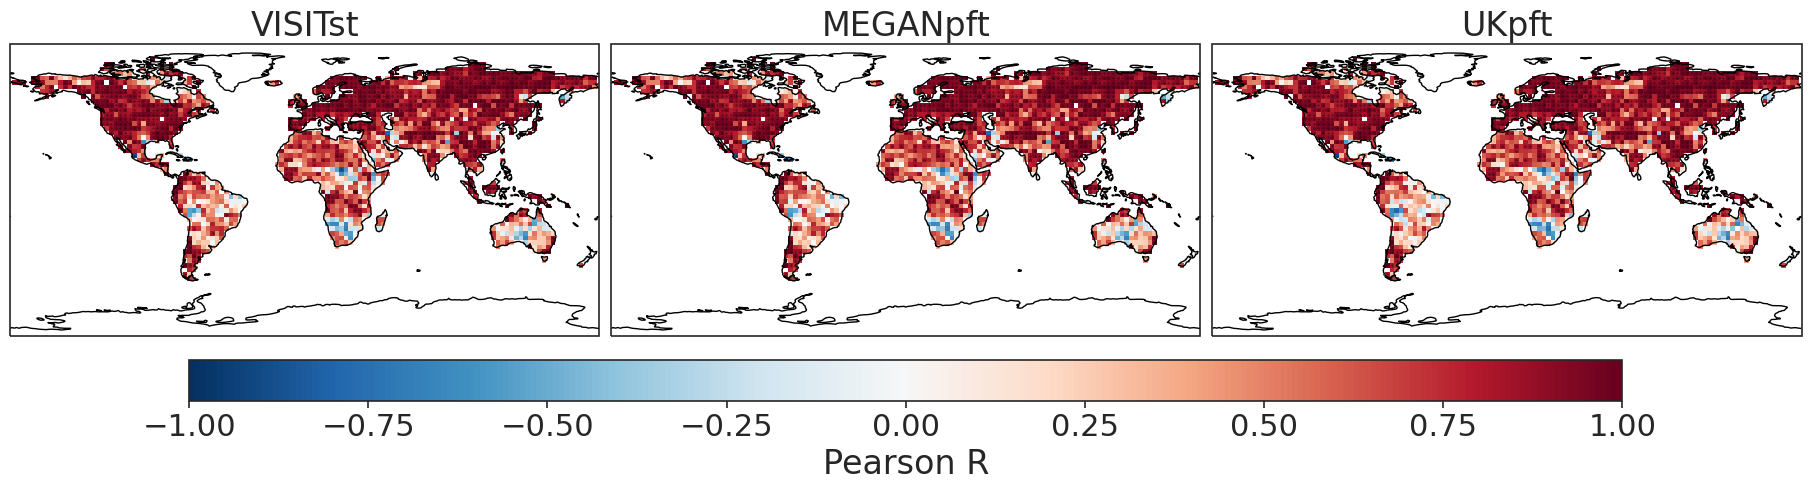

In [ ]:
plt_map(interp_tropo_v2, score="corr", sslat=False)

Figure S7. Normalized Root Mean Square Error (Normalized RMSE in %) between annually averaged HCHO columns from TROPOMI observations and CHASER simulations for 2018–2023.

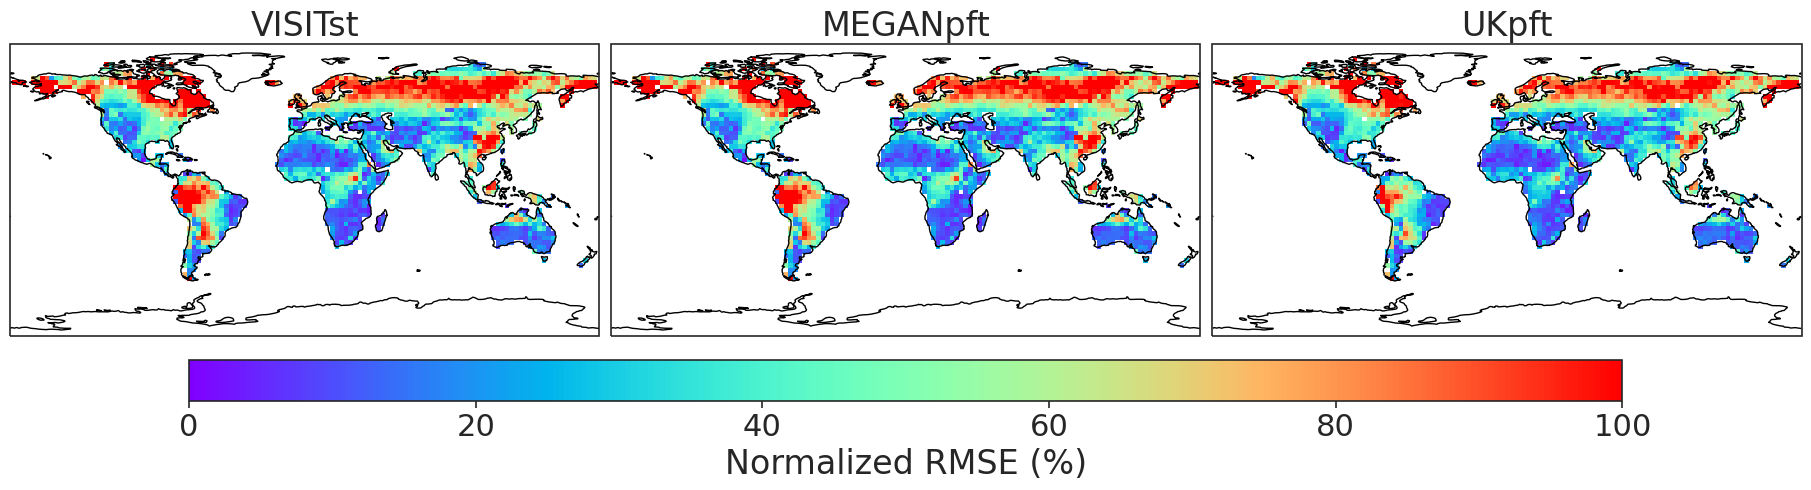

In [ ]:
plt_map(interp_tropo_v2, score="rmse", sslat=False)

Figure S8. Mean annual total column HCHO from all emissions (a) and the BVOC contribution (b) simulated by CHASER, compared with TROPOMI observations (2018–2023) over nine selected regions. The BVOC contribution is calculated as the difference between simulations with and without BVOC emissions, including anthropogenic, biomass-burning, and isoprene sensitivity cases under time-varying emissions.  

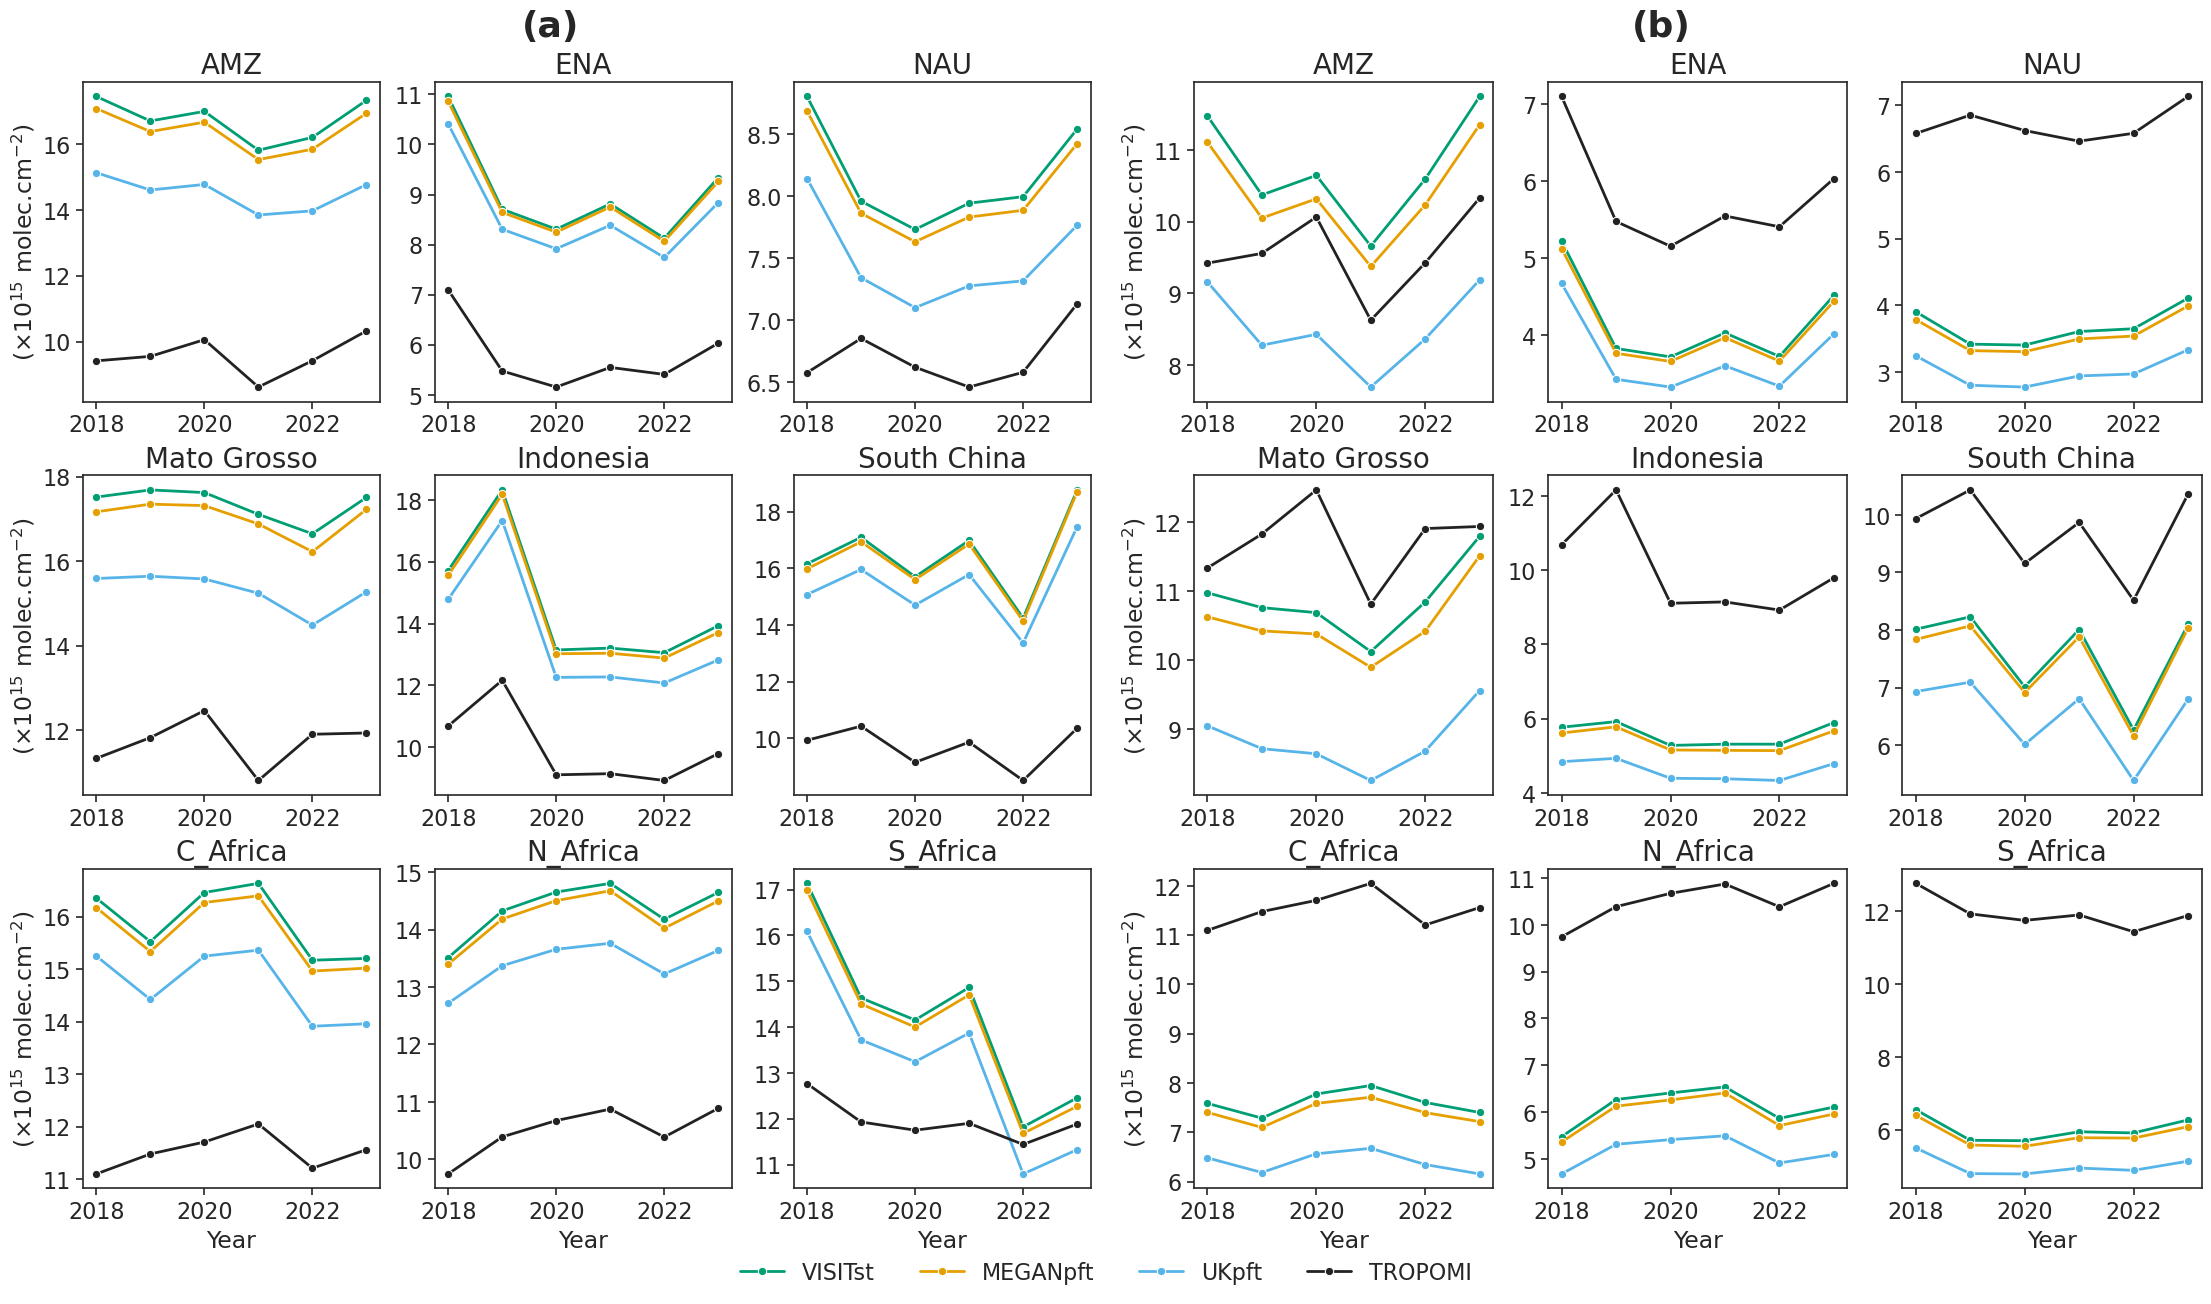

In [ ]:
plt_fig_hcho_combined(interp_tropo_v2, norm=False, unit=None, sslat=False)


Figure S10. Pearson correlations between the annual total-column HCHO from all emissions (a) and from the BVOC contribution (b) in CHASER and OMI HCHO observations (2005–2022) over nine selected regions. The BVOC contribution to HCHO simulations is estimated by subtracting simulations without BVOC emissions from those that include anthropogenic, biomass burning, and each isoprene sensitivity case under time-varying emissions.

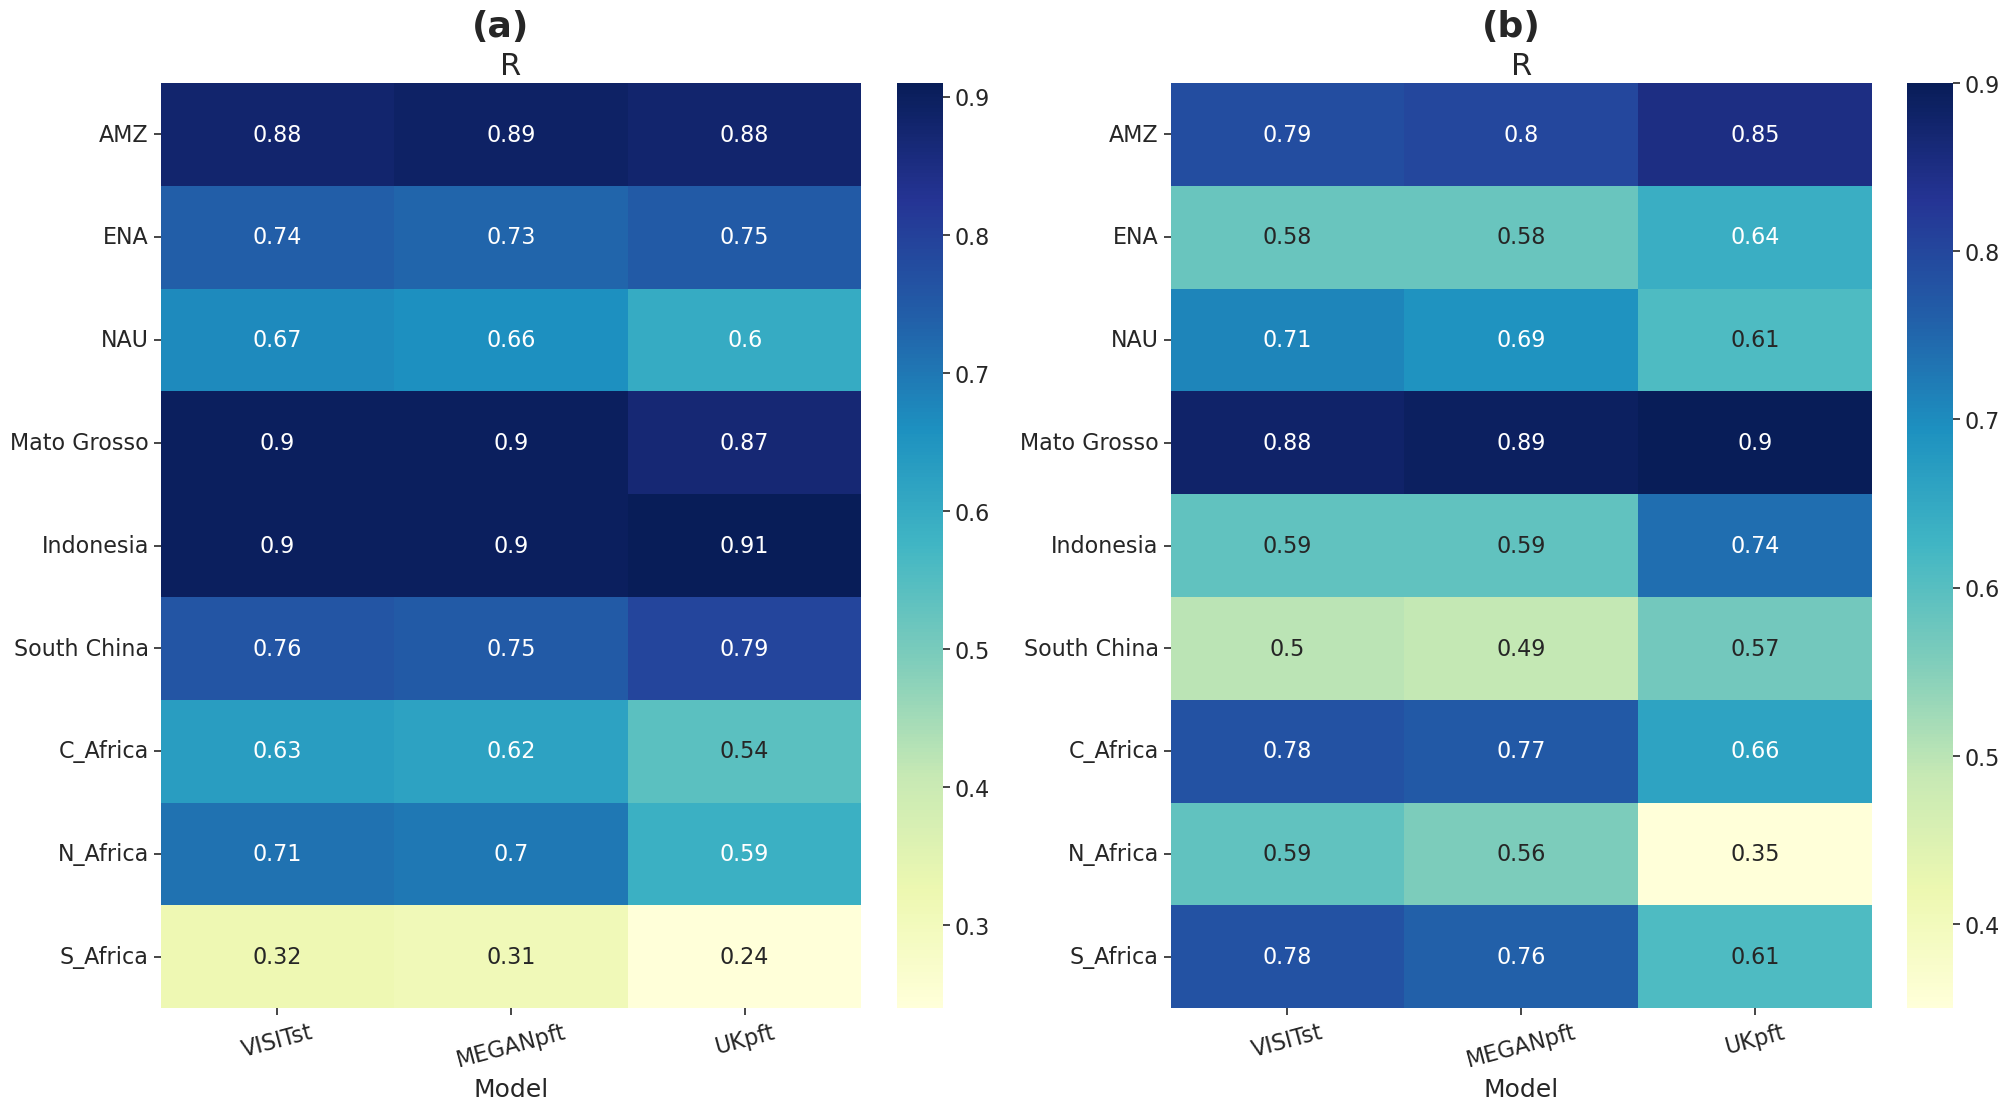

In [ ]:

FS_INDEX = 26    # panel indices (a) (b)
FS_TITLE = 22    # heatmap titles
FS_LABEL = 18    # axis labels ("Model")
FS_TICK = 16     # region / model names and colour-bar ticks
FS_ANNOT = 16    # numbers inside the cells


def _metric_heatmap(ds, title, ax=None):
    ax = sns.heatmap(ds.T, annot=True, cmap="YlGnBu", ax=ax, annot_kws={"size": FS_ANNOT})
    ax.set_title(title, fontsize=FS_TITLE)
    ax.set_xlabel(ax.get_xlabel(), fontsize=FS_LABEL)
    ax.tick_params(labelsize=FS_TICK)
    plt.setp(ax.get_xticklabels(), rotation=15)  # same 15 degrees as the original plt.xticks(rotation=15)
    plt.setp(ax.get_yticklabels(), rotation=0)  # horizontal region names; seaborn's default vertical text overlaps at this size
    ax.collections[0].colorbar.ax.tick_params(labelsize=FS_TICK)  # colour-bar tick labels
    return ax


def plt_metric_reg(hcho_dict, bvoc_contri=False, plot=True):  # CHANGED [FigHeat]: plot=False -> only compute, no figures

    list_case = list(hcho_dict.keys())
    obs_c = get_sat_case(list_case)

    list_reg = ROIS
    R = {"model": [c for c in list_case if c not in [obs_c, OFF_CASE]]}
    rmse = {"model": [c for c in list_case if c not in [obs_c, OFF_CASE]]}
    trend = {"model": [c for c in list_case if c not in [OFF_CASE]]}

    for reg in list_reg:
        R[reg] = []
        rmse[reg] = []
        for c in list_case:
            if c not in [obs_c, OFF_CASE]:
                model_reg = hcho_dict[c].reg_ann[reg]
                obs_reg = hcho_dict[obs_c].reg_ann[reg]
                if bvoc_contri:
                    model_reg = model_reg - hcho_dict[OFF_CASE].reg_ann[reg]

                R[reg].append(pearsonr(model_reg, obs_reg)[0])
                rmse[reg].append(
                    np.sqrt(mse(obs_reg, model_reg)) / obs_reg.mean() * 100
                )

        trend[reg] = []
        trend[f"{reg}_sig"] = []
        for c in list_case:
            if c != OFF_CASE:
                hcho_reg = hcho_dict[c].reg_ann[reg]
                if bvoc_contri and c != obs_c:
                    hcho_reg = hcho_reg - hcho_dict[OFF_CASE].reg_ann[reg]

                trend_dict = pymk.original_test(hcho_reg, alpha=0.05)
                trend[reg].append(trend_dict.slope)
                trend[f"{reg}_sig"].append(0 if not trend_dict.h else 1)

    rmse = pd.DataFrame.from_dict(rmse).round(2)
    R = pd.DataFrame.from_dict(R).round(2)
    trend = pd.DataFrame.from_dict(trend).round(3)

    tits = ["Normalized RMSE (%)", "R", "Trend"]
    for i, ds in enumerate([rmse, R, trend]):
        ds["model"] = ds["model"].apply(lambda x: x.replace("20012023_nudg", ""))
        ds.set_index("model", inplace=True)
        ds.index.name = "Model"
        ds = ds[[col for col in ds.columns if "sig" not in col]]

        if not plot:  # ADDED [FigHeat]: compute only (used by the combined figure)
            continue  # ADDED [FigHeat]
        fig = plt.figure(figsize=(10, 10), layout="constrained")  # CHANGED [FigHeat]: constrained layout, so the larger text fits
        # REMOVED [FigHeat]: sns.heatmap(ds.T, annot=True, cmap="YlGnBu")
        # REMOVED [FigHeat]: plt.title(tits[i], fontsize=16)
        # REMOVED [FigHeat]: plt.xticks(rotation=15)
        _metric_heatmap(ds, tits[i], ax=fig.add_subplot())  # ADDED [FigHeat]: heatmap with the larger fonts

    return rmse, R, trend

def plt_metric_reg_combined(hcho_dict, metric="R", bvoc_a=False, bvoc_b=True, save_path=None):
    which = {"rmse": 0, "R": 1, "trend": 2}[metric]
    title = ["Normalized RMSE (%)", "R", "Trend"][which]

    fig = plt.figure(figsize=(20, 11), layout="constrained")
    sf_a, sf_b = fig.subfigures(1, 2)
    for sf, flag, idx in [(sf_a, bvoc_a, "(a)"), (sf_b, bvoc_b, "(b)")]:
        ds = plt_metric_reg(hcho_dict, bvoc_contri=flag, plot=False)[which]
        ds = ds[[col for col in ds.columns if "sig" not in col]]  # drop the significance columns of "trend"
        _metric_heatmap(ds, title, ax=sf.subplots())
        sf.suptitle(idx, fontsize=FS_INDEX, fontweight="bold")

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

plt_metric_reg_combined(interp_omi_v2, metric="R")
# plt_metric_reg(interp_omi_v2, bvoc_contri=False, plot=True)

Figure S11. Average seasonal cycle of HCHO columns from CHASER simulations with all emissions, using TROPOMI AKs (a) and OMI AKs (b), compared with MAX-DOAS observations at Chiba and Tsukuba (Japan) and Phimai (Thailand). Data are averaged over 12:00–14:00 LT during 2013–2019.

Searching in /mnt/nj2/ngoc/emiisop_co2inhi_als/data/hcho_sat_ak_applied
for v2
/mnt/nj2/ngoc/emiisop_co2inhi_als/data/hcho_sat_ak_applied/BVOCoff20052023_CEDS/sat_interp/omi_ak_hcho_v2_ak_assign.nc
No. of Layers: (15,)
/mnt/nj2/ngoc/emiisop_co2inhi_als/data/hcho_sat_ak_applied/VISITst20052023_CEDS/sat_interp/omi_ak_hcho_v2_ak_assign.nc
No. of Layers: (15,)
/mnt/nj2/ngoc/emiisop_co2inhi_als/data/hcho_sat_ak_applied/MEGANpft20052023_CEDS/sat_interp/omi_ak_hcho_v2_ak_assign.nc
No. of Layers: (15,)
/mnt/nj2/ngoc/emiisop_co2inhi_als/data/hcho_sat_ak_applied/UKpft20052023_CEDS/sat_interp/omi_ak_hcho_v2_ak_assign.nc
No. of Layers: (15,)
Searching in /mnt/nj2/ngoc/emiisop_co2inhi_als/data/hcho_sat_ak_applied
for v2
/mnt/nj2/ngoc/emiisop_co2inhi_als/data/hcho_sat_ak_applied/BVOCoff20052023_CEDS/sat_interp/omi_ak_hcho_v2_ak_assign.nc
No. of Layers: (15,)
/mnt/nj2/ngoc/emiisop_co2inhi_als/data/hcho_sat_ak_applied/VISITst20052023_CEDS/sat_interp/omi_ak_hcho_v2_ak_assign.nc
No. of Layers: (15,)
/mn

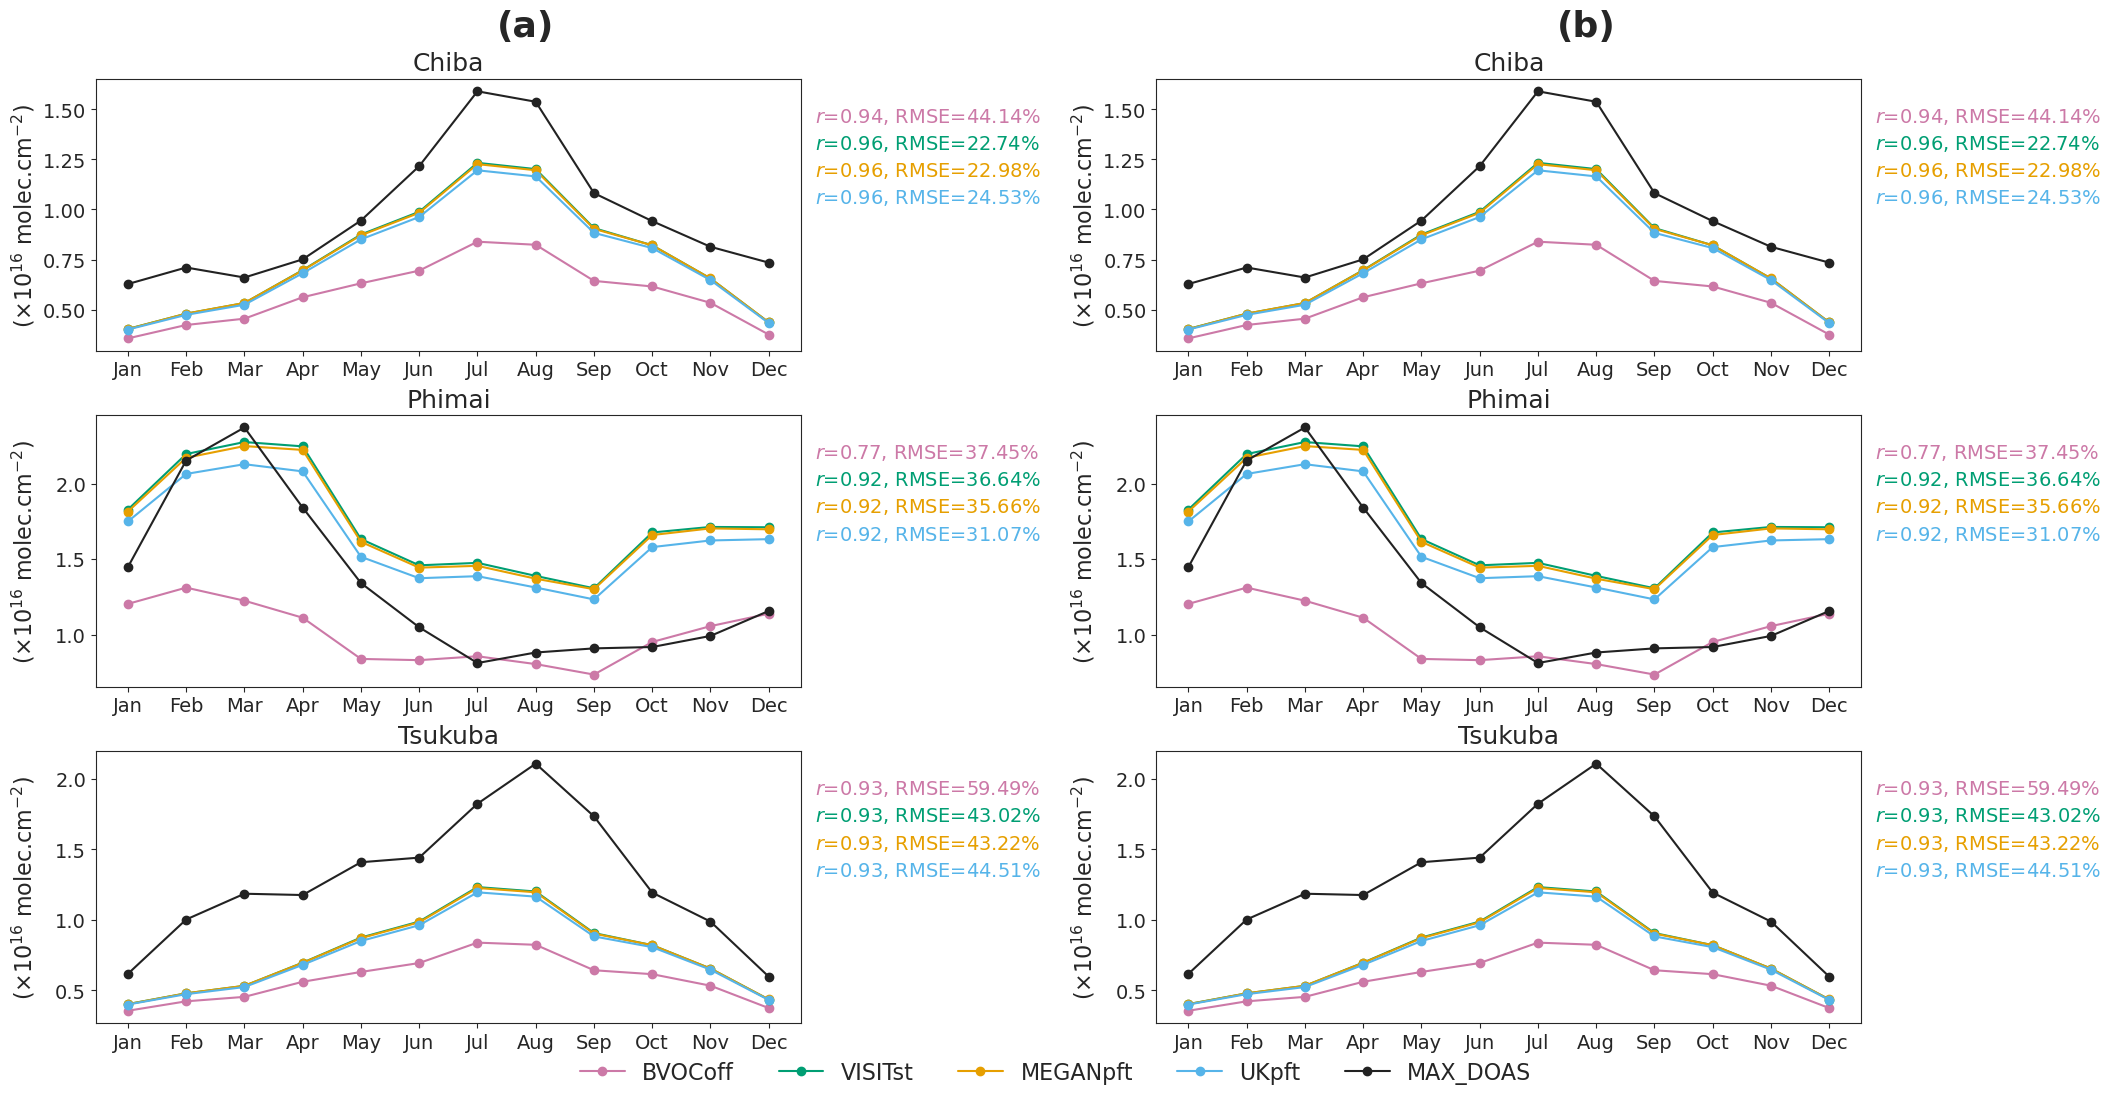

In [ ]:
FS_INDEX = 26    # panel indices (a) (b)   [FigDOAS2]
FS_TITLE = 18    # station names above each panel
FS_LABEL = 16    # y-axis label
FS_TICK = 14     # tick labels (month names, y values)
FS_ANNOT = 14    # the "r=..., RMSE=..." text to the right of each panel
FS_LEGEND = 16   # legend text
LEGEND_NCOL = 3  # legend columns when plt_maxdoas() is used on its own


def plt_maxdoas(sat_name="omi", layer_used=15, norm=False, summer_only=False, axes=None):  # CHANGED [FigDOAS2]: optional `axes` (3 axes) to draw the seasonal panels into
    colors = [
        "#CC79A7",  # reddish purple
        "#009E73",  # bluish green
        "#E69F00",  # orange
        "#56B4E9",  # sky blue
        "#222222",
    ]
    hcho = load_hcho_maxdoas(sat_name, layer_used)

    combined = axes is not None  # ADDED [FigDOAS2]
    if combined:  # ADDED [FigDOAS2]: draw into the supplied axes, no new figures and no legend here
        ax_ss = axes  # ADDED [FigDOAS2]
    else:  # ADDED [FigDOAS2]: standalone use keeps the original two figures
        f_annual, ax_annual = plt.subplots(3, 1, figsize=(10, 10), layout="constrained")  # CHANGED [FigDOAS]: figsize (6, 8) -> (10, 10)
        f_ss, ax_ss = plt.subplots(3, 1, figsize=(10, 10), layout="constrained")  # CHANGED [FigDOAS]: figsize (6, 8) -> (10, 10)
    max_doas_col = "MAX_DOAS"

    df_maxdoas = hcho[max_doas_col]
    for i, c in enumerate(hcho.keys()):
        df_case = hcho[c]

        for j, station in enumerate(MAX_DOAS_COORDS.keys()):
            df_station = df_case[station]
            df_ss = df_station.groupby(df_station.index.month).mean()
            ss_hcho = df_ss.hcho

            df_maxdoas_station = df_maxdoas[station]
            df_maxdoas_ss = df_maxdoas_station.groupby(
                df_maxdoas_station.index.month
            ).mean()
            ss_hcho_maxdoas = df_maxdoas_ss.hcho

            # df_annual = df_station.groupby(df_station.index.year).mean()
            # if summer_only:
            #     df_annual = df_station[df_station.index.month.isin([6, 7, 8])]
            #     df_annual = df_annual.groupby(df_annual.index.year).mean()

            # ann_hcho = df_annual.hcho
            if norm:
                ss_hcho = min_max_normalize(ss_hcho)
                ss_hcho_maxdoas = min_max_normalize(ss_hcho_maxdoas)
                # ann_hcho = min_max_normalize(ann_hcho)
            if c != max_doas_col:
                common = ss_hcho.dropna().index.intersection(
                    ss_hcho_maxdoas.dropna().index
                )
                if len(common) > 1:
                    R_ss, _ = pearsonr(ss_hcho.loc[common], ss_hcho_maxdoas.loc[common])
                    RMSE_raw = np.sqrt(
                        mse(ss_hcho_maxdoas.loc[common], ss_hcho.loc[common])
                    )

                    mean_ref = ss_hcho_maxdoas.loc[common].mean()
                    RMSE_pct = (RMSE_raw / mean_ref) * 100 if mean_ref != 0 else np.nan

                    ax_ss[j].annotate(
                        rf"$\it{{r}}$={R_ss:.2f}, RMSE={RMSE_pct:.2f}%",
                        xy=(1.02, 0.9 - 0.1 * i),  # stagger down per dataset
                        xycoords="axes fraction",
                        va="top",
                        ha="left",
                        fontsize=FS_ANNOT,  # CHANGED [FigDOAS]: 10 -> FS_ANNOT
                        color=colors[i],  # match line color
                    )

            # --- Plot ---
            ax_ss[j].plot(
                df_ss.index, ss_hcho * 1e-16, label=f"{c}", color=colors[i], marker="o"
            )
            ax_ss[j].set_title(f"{station}", fontsize=FS_TITLE)  # CHANGED [FigDOAS]: explicit font size
            ax_ss[j].set_xticks(df_ss.index)

            ax_ss[j].set_xticklabels([calendar.month_abbr[m] for m in df_ss.index])
            ax_ss[j].tick_params(labelsize=FS_TICK)  # ADDED [FigDOAS]: month names and y tick labels
            unit = "(\u00d710$^{16}$ molec.cm$^{-2}$)"
            ax_ss[j].set_ylabel(unit, fontsize=FS_LABEL)  # CHANGED [FigDOAS]: explicit font size

            # ax_annual[j].plot(
            #     df_annual.index, ann_hcho, label=f"{c}", color=colors[i], marker="o"
            # )
            # ax_annual[j].set_title(f"{station} - (Annual Mean)")

            # ax_annual[j].set_xlim(2012, 2020)

    # CHANGED [FigDOAS2]: handles/labels are now built once here (they were built inside the loop below)
    handles, labels = ax_ss[0].get_legend_handles_labels()
    labels = [lbl.replace("20052023_CEDS", "") for lbl in labels]
    if combined:  # ADDED [FigDOAS2]: hand the legend entries back; the combined figure draws ONE legend
        return handles, labels  # ADDED [FigDOAS2]

    for fig in [f_ss, f_annual]:

        fig.legend(
            handles,
            labels,
            loc="outside lower center",  # CHANGED [FigDOAS]: was loc="lower center", bbox_to_anchor=(0.5, -0.1); now reserved inside the layout
            ncol=LEGEND_NCOL,  # CHANGED [FigDOAS]: 6 -> LEGEND_NCOL
            fontsize=FS_LEGEND,  # ADDED [FigDOAS]
            frameon=False,
        )

def plt_maxdoas_combined(kwargs_a=None, kwargs_b=None, save_path=None):
    kwargs_a = kwargs_a or {}
    kwargs_b = kwargs_b or {}
    fig = plt.figure(figsize=(21, 11), layout="constrained")
    sf_a, sf_b = fig.subfigures(1, 2)
    axes_a = sf_a.subplots(3, 1)
    axes_b = sf_b.subplots(3, 1)

    handles, labels = plt_maxdoas(**kwargs_a, axes=axes_a)  # (a)
    plt_maxdoas(**kwargs_b, axes=axes_b)  # (b): same cases and colours, so its legend is not needed
    sf_a.align_ylabels(axes_a)  # ADDED [FigDOAS2]: y labels of the three rows line up vertically
    sf_b.align_ylabels(axes_b)  # ADDED [FigDOAS2]
    sf_a.suptitle("(a)", fontsize=FS_INDEX, fontweight="bold")
    sf_b.suptitle("(b)", fontsize=FS_INDEX, fontweight="bold")

    fig.legend(  # the single legend for the whole figure
        handles,
        labels,
        loc="outside lower center",
        ncol=len(labels),
        fontsize=FS_LEGEND,
        frameon=False,
    )
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()#
plt_maxdoas_combined()